# Phân Tích Khám Phá Dữ Liệu và Câu Hỏi Nghiên Cứu
## Dự Đoán Thất Bại Thử Nghiệm Lâm Sàng Ung Thư

**Notebook 03: Exploratory Data Analysis and Research Questions**

---

## Tổng quan các câu hỏi nghiên cứu

**Câu hỏi 1: Tác động của Nhà tài trợ và Quy mô**
*   **Câu hỏi:** Loại nhà tài trợ (Industry, Academic, Government...) và quy mô thử nghiệm có ảnh hưởng như thế nào đến tỷ lệ thành công? Liệu có sự tương tác giữa nhà tài trợ và quy mô mẫu không?
*   **Động lực và Lợi ích:** 
    - Giúp xác định xem nguồn lực tài chính và kinh nghiệm quản lý có phải là yếu tố quyết định thành công hay không. 
    - Đánh giá chiến lược lựa chọn quy mô mẫu phù hợp để tối ưu hóa khả năng thành công và chi phí.
*   **Phương pháp:** Sử dụng kiểm định Chi-square độc lập và phân tích biểu đồ tương tác đa biến (Heatmap, Barplot).

**Câu hỏi 2: Thời gian và Chiến lược "Fail Fast"**
*   **Câu hỏi:** Thời gian thực hiện thử nghiệm có mối quan hệ như thế nào với tỷ lệ thành công? Liệu các thử nghiệm kéo dài hơn có xu hướng thành công cao hơn?
*   **Động lực và Lợi ích:** 
    - Kiểm chứng tính hiệu quả của chiến lược "Fail Fast" (thất bại sớm để cắt lỗ). 
    - Hiểu rõ quy luật thời gian giúp các nhà quản lý dự án thiết lập các mốc kiểm tra (milestones) hợp lý để ra quyết định tiếp tục hay dừng lại.
*   **Phương pháp:** Phân tích phân phối thời gian (KDE, Boxplot), kiểm định Mann-Whitney U và so sánh trung vị.

**Câu hỏi 3: Chất lượng Thiết kế Thử nghiệm**
*   **Câu hỏi:** Các đặc điểm thiết kế nghiên cứu như Phân bổ ngẫu nhiên (Allocation) và Làm mù (Masking) ảnh hưởng ra sao đến kết quả cuối cùng?
*   **Động lực và Lợi ích:** 
    - Đánh giá vai trò của sự chặt chẽ trong phương pháp luận khoa học. 
    - Giúp xác định xem các tiêu chuẩn vàng trong thiết kế (như mù đôi, ngẫu nhiên hóa) có thực sự dẫn đến kết quả khả quan hơn hay không.
*   **Phương pháp:** Thống kê mô tả tỷ lệ thành công theo nhóm thiết kế và kiểm định ý nghĩa thống kê.

**Câu hỏi 4: Độ phức tạp của Thử nghiệm**
*   **Câu hỏi:** Độ phức tạp của thử nghiệm (số lượng điều kiện bệnh lý tham gia, số lượng can thiệp) ảnh hưởng như thế nào đến tỷ lệ thành công?
*   **Động lực và Lợi ích:** 
    - Làm rõ mối quan hệ giữa tham vọng của thử nghiệm và tính khả thi vận hành. 
    - Cung cấp gợi ý cho việc thiết kế các thử nghiệm cân bằng, tránh ôm đồm quá nhiều mục tiêu dẫn đến rủi ro thất bại cao.
*   **Phương pháp:** Phân tích tương quan và so sánh nhóm dựa trên số lượng điều kiện/can thiệp.

**Câu hỏi 5: Xu hướng Công nghệ và Thời gian**
*   **Câu hỏi:** Tỷ lệ thành công của các thử nghiệm lâm sàng thay đổi như thế nào theo thời gian (năm, thập kỷ)?
*   **Động lực và Lợi ích:** 
    - Nhận diện các làn sóng công nghệ mới (như kỷ nguyên liệu pháp miễn dịch) và đánh giá sức khỏe chung của ngành R&D ung thư. 
    - Giúp dự báo xu hướng và định hướng đầu tư trong tương lai.
*   **Phương pháp:** Phân tích chuỗi thời gian (Time-series), tính toán Moving Average và hồi quy xu hướng.

---


## 1. Cài đặt và Tải dữ liệu

#### 1.1. Import thư viện

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

# Cấu hình đồ thị
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

# Đường dẫn dự án
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "eda_plots"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Random seed
SEED = 42
np.random.seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

Project root: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction
Data directory: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/processed


#### 1.2. Tải dữ liệu

In [2]:
# Tải dữ liệu đã tiền xử lý từ notebook 02 (clean_data.csv)
data_path = DATA_DIR / "clean_data.csv"
df_analysis = pd.read_csv(data_path)

# Định nghĩa nhãn (để tham khảo)
SUCCESS_STATUSES = ['COMPLETED']
FAIL_STATUSES = ['WITHDRAWN', 'TERMINATED']

# Chuyển đổi ngày (cần thiết vì CSV không lưu kiểu datetime)
df_analysis['start_date'] = pd.to_datetime(df_analysis['start_date'], errors='coerce')
df_analysis['completion_date'] = pd.to_datetime(df_analysis['completion_date'], errors='coerce')

# Kiểm tra dữ liệu
print(f"DỮ LIỆU ĐÃ TẢI TỪ clean_data.csv (đã xử lý ở notebook 02):")
print("-" * 60)
print(f"   - Tổng số bản ghi: {len(df_analysis):,}")
print(f"   - Số cột: {df_analysis.shape[1]}")

# Phân phối nhãn (đã có sẵn từ notebook 02)
n_success = (df_analysis['label_binary'] == 1).sum()
n_fail = (df_analysis['label_binary'] == 0).sum()
print(f"\nPHÂN PHỐI NHÃN:")
print(f"   - Thành công (1): {n_success:,} ({n_success/len(df_analysis)*100:.1f}%)")
print(f"   - Thất bại (0): {n_fail:,} ({n_fail/len(df_analysis)*100:.1f}%)")

DỮ LIỆU ĐÃ TẢI TỪ clean_data.csv (đã xử lý ở notebook 02):
------------------------------------------------------------
   - Tổng số bản ghi: 30,000
   - Số cột: 25

PHÂN PHỐI NHÃN:
   - Thành công (1): 21,882 (72.9%)
   - Thất bại (0): 8,118 (27.1%)


---

## 2. Tổng quan Dữ liệu

#### 2.1. Thống kê mô tả tổng quan

In [3]:
# Thông tin cơ bản
print(f"\n1. KÍCH THƯỚC DỮ LIỆU:")
print(f"   - Số thử nghiệm: {len(df_analysis):,}")
print(f"   - Số đặc trưng: {df_analysis.shape[1]}")

# Phân phối nhãn
n_success = (df_analysis['label_binary'] == 1).sum()
n_fail = (df_analysis['label_binary'] == 0).sum()
success_rate = n_success / len(df_analysis) * 100

print(f"\n2. PHÂN PHỐI KẾT QUẢ:")
print(f"   - Thành công (Completed): {n_success:,} ({success_rate:.1f}%)")
print(f"   - Thất bại (Terminated/Withdrawn): {n_fail:,} ({100-success_rate:.1f}%)")
print(f"   - Tỷ số mất cân bằng: {max(n_success, n_fail)/min(n_success, n_fail):.2f}:1")

# Phân phối theo phase
print(f"\n3. PHÂN PHỐI THEO PHA THỬ NGHIỆM:")
phase_dist = df_analysis['phases'].value_counts()
for phase, count in phase_dist.items():
    pct = count / len(df_analysis) * 100
    print(f"   - {phase}: {count:,} ({pct:.1f}%)")

# Phân phối theo loại nhà tài trợ
print(f"\n4. PHÂN PHỐI THEO LOẠI NHÀ TÀI TRỢ:")
sponsor_dist = df_analysis['lead_sponsor_class'].value_counts()
for sponsor, count in sponsor_dist.head(5).items():
    pct = count / len(df_analysis) * 100
    print(f"   - {sponsor}: {count:,} ({pct:.1f}%)")


1. KÍCH THƯỚC DỮ LIỆU:
   - Số thử nghiệm: 30,000
   - Số đặc trưng: 25

2. PHÂN PHỐI KẾT QUẢ:
   - Thành công (Completed): 21,882 (72.9%)
   - Thất bại (Terminated/Withdrawn): 8,118 (27.1%)
   - Tỷ số mất cân bằng: 2.70:1

3. PHÂN PHỐI THEO PHA THỬ NGHIỆM:
   - PHASE2: 18,158 (60.5%)
   - PHASE3: 6,278 (20.9%)
   - PHASE1|PHASE2: 4,779 (15.9%)
   - PHASE2|PHASE3: 785 (2.6%)

4. PHÂN PHỐI THEO LOẠI NHÀ TÀI TRỢ:
   - OTHER: 16,298 (54.3%)
   - INDUSTRY: 10,196 (34.0%)
   - NIH: 1,787 (6.0%)
   - NETWORK: 1,346 (4.5%)
   - OTHER_GOV: 295 (1.0%)


---

## 3. Câu hỏi Nghiên cứu 1

### Ảnh hưởng của Loại Nhà tài trợ và Quy mô Thử nghiệm đến Tỷ lệ Thành công của Thử nghiệm Lâm sàng Ung thư

---

### A. Question Formulation

#### 1. Câu hỏi nghiên cứu

**Câu hỏi**: Loại nhà tài trợ (Industry, Academic, Government, Network) và quy mô thử nghiệm (số lượng người tham gia) có ảnh hưởng như thế nào đến tỷ lệ thành công của các thử nghiệm lâm sàng ung thư pha 2-3? Liệu có sự tương tác giữa hai yếu tố này không?

**Mục tiêu**: Xác định mối quan hệ giữa nguồn lực tài trợ, quy mô thử nghiệm và kết quả thử nghiệm để đưa ra khuyến nghị cho việc thiết kế và tài trợ thử nghiệm lâm sàng trong tương lai.

#### 2. Động cơ nghiên cứu

Thử nghiệm lâm sàng ung thư là một quá trình tốn kém và mất nhiều thời gian. Theo thống kê, chi phí trung bình cho một thử nghiệm pha 3 có thể lên đến hàng trăm triệu USD. Việc hiểu rõ các yếu tố ảnh hưởng đến thành công sẽ giúp:

- **Nhà tài trợ**: Phân bổ nguồn lực hiệu quả hơn
- **Nhà nghiên cứu**: Thiết kế thử nghiệm với xác suất thành công cao hơn
- **Bệnh nhân**: Giảm thiểu tham gia vào các thử nghiệm có khả năng thất bại cao
- **Hệ thống y tế**: Tối ưu hóa đầu tư R&D trong lĩnh vực ung thư

#### 3. Ý nghĩa thực tiễn

| Đối tượng | Lợi ích từ nghiên cứu |
|-----------|----------------------|
| **Công ty dược phẩm** | Quyết định đầu tư và thiết kế thử nghiệm tối ưu |
| **Cơ quan quản lý (FDA, EMA)** | Đánh giá rủi ro và ưu tiên xét duyệt |
| **Nhà đầu tư** | Đánh giá tiềm năng của các chương trình R&D |
| **Bệnh nhân** | Lựa chọn tham gia thử nghiệm có triển vọng |

#### 4. Phạm vi phân tích

- **Dữ liệu**: Thử nghiệm lâm sàng ung thư pha 2-3 từ ClinicalTrials.gov
- **Biến độc lập**: `lead_sponsor_class` (loại nhà tài trợ), `enrollment_count` (quy mô)
- **Biến phụ thuộc**: `label_binary` (1 = Thành công, 0 = Thất bại)
- **Phương pháp**: Phân tích thống kê mô tả, kiểm định Chi-square, Mann-Whitney U test, phân tích tương tác

---

### B. Preprocessing

**Quy trình tiền xử lý dữ liệu:**

1. **Lọc và chuẩn hóa biến nhà tài trợ** (`lead_sponsor_class`):
   - Xử lý giá trị thiếu bằng nhãn 'UNKNOWN'
   - Nhóm các danh mục nhỏ nếu cần thiết

2. **Xử lý biến quy mô** (`enrollment_count`):
   - Kiểm tra và xử lý giá trị thiếu
   - Tạo biến phân nhóm quy mô (nhỏ, trung bình, lớn)
   - Áp dụng log transformation cho phân tích

3. **Tạo các biến phụ trợ**:
   - Biến tương tác giữa loại nhà tài trợ và quy mô
   - Biến chỉ báo cho các nhóm đặc biệt

#### B.1. Tiền xử lý biến nhà tài trợ

In [4]:
# Tạo bản sao cho phân tích (dữ liệu đã được xử lý từ notebook 02)
df_q1 = df_analysis.copy()

# Kiểm tra phân phối
print("=" * 70)
print("B.1 KIỂM TRA DỮ LIỆU BIẾN NHÀ TÀI TRỢ (lead_sponsor_class)")
print("=" * 70)
print("\n(Dữ liệu đã được xử lý giá trị thiếu từ notebook 02)")

sponsor_counts = df_q1['lead_sponsor_class'].value_counts()
print("\nPhân phối theo loại nhà tài trợ:")
print("-" * 35)
for sponsor, count in sponsor_counts.items():
    pct = count / len(df_q1) * 100
    print(f"   {sponsor:<15}: {count:>6,} ({pct:>5.1f}%)")

# Nhóm các danh mục nhỏ (< 1%) vào OTHER để phân tích
threshold = len(df_q1) * 0.01
small_categories = sponsor_counts[sponsor_counts < threshold].index.tolist()

if small_categories:
    print(f"\nCác danh mục nhỏ (< 1%) được nhóm vào 'OTHER' cho phân tích: {small_categories}")
    df_q1.loc[df_q1['lead_sponsor_class'].isin(small_categories), 'lead_sponsor_class'] = 'OTHER'

# Phân phối sau khi nhóm
print("\nPhân phối sau khi nhóm (để phân tích):")
print(df_q1['lead_sponsor_class'].value_counts().to_string())

B.1 KIỂM TRA DỮ LIỆU BIẾN NHÀ TÀI TRỢ (lead_sponsor_class)

(Dữ liệu đã được xử lý giá trị thiếu từ notebook 02)

Phân phối theo loại nhà tài trợ:
-----------------------------------
   OTHER          : 16,298 ( 54.3%)
   INDUSTRY       : 10,196 ( 34.0%)
   NIH            :  1,787 (  6.0%)
   NETWORK        :  1,346 (  4.5%)
   OTHER_GOV      :    295 (  1.0%)
   FED            :     54 (  0.2%)
   INDIV          :     20 (  0.1%)
   UNKNOWN        :      4 (  0.0%)

Các danh mục nhỏ (< 1%) được nhóm vào 'OTHER' cho phân tích: ['OTHER_GOV', 'FED', 'INDIV', 'UNKNOWN']

Phân phối sau khi nhóm (để phân tích):
lead_sponsor_class
OTHER       16671
INDUSTRY    10196
NIH          1787
NETWORK      1346


#### B.2. Tiền xử lý biến quy mô thử nghiệm

In [5]:
# Kiểm tra dữ liệu enrollment_count (đã được xử lý từ notebook 02)
print("=" * 70)
print("B.2 KIỂM TRA DỮ LIỆU QUY MÔ THỬ NGHIỆM (enrollment_count)")
print("=" * 70)
print("\n(Giá trị thiếu đã được xử lý từ notebook 02)")

missing_enrollment = df_q1['enrollment_count'].isna().sum()
print(f"Giá trị thiếu hiện tại: {missing_enrollment}")

if 'enrollment_count_was_missing' in df_q1.columns:
    originally_missing = df_q1['enrollment_count_was_missing'].sum()
    print(f"Số bản ghi ban đầu thiếu (đã được điền): {originally_missing}")

# Thống kê mô tả
print("\nThống kê mô tả enrollment_count:")
print("-" * 50)
enrollment_stats = df_q1['enrollment_count'].describe()
print(enrollment_stats.to_string())

# Tạo biến phân nhóm quy mô dựa trên quartiles
q25 = df_q1['enrollment_count'].quantile(0.25)
q75 = df_q1['enrollment_count'].quantile(0.75)

def categorize_size(x):
    if x <= q25:
        return 'Nhỏ (≤Q1)'
    elif x <= q75:
        return 'Trung bình (Q1-Q3)'
    else:
        return 'Lớn (>Q3)'

df_q1['enrollment_category'] = df_q1['enrollment_count'].apply(categorize_size)

print(f"\nPhân nhóm quy mô (dựa trên quartiles):")
print(f"   - Nhỏ: ≤ {q25:.0f} người")
print(f"   - Trung bình: {q25:.0f} - {q75:.0f} người")
print(f"   - Lớn: > {q75:.0f} người")

print("\nPhân phối theo nhóm quy mô:")
print(df_q1['enrollment_category'].value_counts().to_string())

# Tạo biến log-transformed
df_q1['enrollment_log'] = np.log1p(df_q1['enrollment_count'])

B.2 KIỂM TRA DỮ LIỆU QUY MÔ THỬ NGHIỆM (enrollment_count)

(Giá trị thiếu đã được xử lý từ notebook 02)
Giá trị thiếu hiện tại: 0
Số bản ghi ban đầu thiếu (đã được điền): 934

Thống kê mô tả enrollment_count:
--------------------------------------------------
count    30000.000
mean       198.796
std       3156.975
min          0.000
25%         19.750
50%         45.000
75%        119.000
max     477102.000

Phân nhóm quy mô (dựa trên quartiles):
   - Nhỏ: ≤ 20 người
   - Trung bình: 20 - 119 người
   - Lớn: > 119 người

Phân phối theo nhóm quy mô:
enrollment_category
Trung bình (Q1-Q3)    15013
Nhỏ (≤Q1)              7500
Lớn (>Q3)              7487


---

### C. Phân tích thống kê

Phần này trình bày các phương pháp phân tích thống kê được áp dụng để trả lời câu hỏi nghiên cứu, bao gồm:

1. **Phân tích mô tả**: Tính tỷ lệ thành công theo từng loại nhà tài trợ và nhóm quy mô
2. **Kiểm định thống kê**:
   - Kiểm định Chi-square: Đánh giá mối quan hệ giữa biến phân loại và kết quả
   - Kiểm định Mann-Whitney U: So sánh phân phối quy mô giữa hai nhóm kết quả
3. **Phân tích tương tác**: Xem xét ảnh hưởng kết hợp của nhà tài trợ và quy mô

#### C.1. Phân tích tỷ lệ thành công theo loại nhà tài trợ

In [6]:
# Tính tỷ lệ thành công theo loại nhà tài trợ
sponsor_success = df_q1.groupby('lead_sponsor_class').agg(
    total=('label_binary', 'count'),
    success=('label_binary', 'sum'),
    success_rate=('label_binary', 'mean')
).round(3)

sponsor_success['fail'] = sponsor_success['total'] - sponsor_success['success']
sponsor_success['success_rate_pct'] = (sponsor_success['success_rate'] * 100).round(1)
sponsor_success = sponsor_success.sort_values('success_rate', ascending=False)

print("\nTỷ lệ thành công theo loại nhà tài trợ:")
print("-" * 70)
print(f"{'Loại nhà tài trợ':<20} {'Tổng':>8} {'Thành công':>12} {'Thất bại':>10} {'Tỷ lệ (%)':>10}")
print("-" * 70)

for sponsor in sponsor_success.index:
    row = sponsor_success.loc[sponsor]
    print(f"{sponsor:<20} {row['total']:>8,} {row['success']:>12,} {row['fail']:>10,} {row['success_rate_pct']:>9.1f}%")

print("-" * 70)

# Tìm sponsor có tỷ lệ cao nhất và thấp nhất
best_sponsor = sponsor_success.index[0]
worst_sponsor = sponsor_success.index[-1]
best_rate = sponsor_success.loc[best_sponsor, 'success_rate_pct']
worst_rate = sponsor_success.loc[worst_sponsor, 'success_rate_pct']

print(f"\nNhận xét sơ bộ:")
print(f"   - Loại nhà tài trợ có tỷ lệ thành công CAO NHẤT: {best_sponsor} ({best_rate}%)")
print(f"   - Loại nhà tài trợ có tỷ lệ thành công THẤP NHẤT: {worst_sponsor} ({worst_rate}%)")
print(f"   - Chênh lệch: {best_rate - worst_rate:.1f} phần trăm")


Tỷ lệ thành công theo loại nhà tài trợ:
----------------------------------------------------------------------
Loại nhà tài trợ         Tổng   Thành công   Thất bại  Tỷ lệ (%)
----------------------------------------------------------------------
NETWORK               1,346.0      1,082.0      264.0      80.4%
NIH                   1,787.0      1,418.0      369.0      79.4%
INDUSTRY             10,196.0      7,488.0    2,708.0      73.4%
OTHER                16,671.0     11,894.0    4,777.0      71.3%
----------------------------------------------------------------------

Nhận xét sơ bộ:
   - Loại nhà tài trợ có tỷ lệ thành công CAO NHẤT: NETWORK (80.4%)
   - Loại nhà tài trợ có tỷ lệ thành công THẤP NHẤT: OTHER (71.3%)
   - Chênh lệch: 9.1 phần trăm


#### C.2. Kiểm định Chi-square: Mối quan hệ nhà tài trợ - kết quả

In [7]:
# Tạo bảng chéo (contingency table)
contingency_table = pd.crosstab(
    df_q1['lead_sponsor_class'], 
    df_q1['label_binary'],
    margins=True
)
contingency_table.columns = ['Thất bại (0)', 'Thành công (1)', 'Tổng']

print("\nBảng chéo (Contingency Table):")
print("-" * 60)
print(contingency_table.to_string())

# Thực hiện kiểm định Chi-square
chi2, p_value, dof, expected = chi2_contingency(
    pd.crosstab(df_q1['lead_sponsor_class'], df_q1['label_binary'])
)

print(f"\n\nKẾT QUẢ KIỂM ĐỊNH CHI-SQUARE:")
print("-" * 60)
print(f"   Chi-square statistic (χ²): {chi2:.4f}")
print(f"   Degrees of freedom (df):   {dof}")
print(f"   P-value:                   {p_value:.2e}")

# Tính Cramér's V (effect size)
n = len(df_q1)
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

print(f"   Cramér's V (effect size):  {cramers_v:.4f}")

# Kết luận
alpha = 0.05
if p_value < alpha:
    print(f"\n   KẾT LUẬN: Với α = {alpha}, p-value < α")
    print("   => BÁC BỎ giả thuyết H0")
    print("   => CÓ mối quan hệ có ý nghĩa thống kê giữa loại nhà tài trợ và kết quả thử nghiệm")
else:
    print(f"\n   KẾT LUẬN: Với α = {alpha}, p-value ≥ α")
    print("   => CHẤP NHẬN giả thuyết H0")
    print("   => KHÔNG có mối quan hệ có ý nghĩa thống kê")

# Đánh giá effect size
if cramers_v < 0.1:
    effect_interpret = "rất yếu (negligible)"
elif cramers_v < 0.2:
    effect_interpret = "yếu (weak)"
elif cramers_v < 0.4:
    effect_interpret = "trung bình (moderate)"
else:
    effect_interpret = "mạnh (strong)"

print(f"\n   Mức độ ảnh hưởng: {effect_interpret}")


Bảng chéo (Contingency Table):
------------------------------------------------------------
                    Thất bại (0)  Thành công (1)   Tổng
lead_sponsor_class                                     
INDUSTRY                    2708            7488  10196
NETWORK                      264            1082   1346
NIH                          369            1418   1787
OTHER                       4777           11894  16671
All                         8118           21882  30000


KẾT QUẢ KIỂM ĐỊNH CHI-SQUARE:
------------------------------------------------------------
   Chi-square statistic (χ²): 97.7929
   Degrees of freedom (df):   3
   P-value:                   4.63e-21
   Cramér's V (effect size):  0.0571

   KẾT LUẬN: Với α = 0.05, p-value < α
   => BÁC BỎ giả thuyết H0
   => CÓ mối quan hệ có ý nghĩa thống kê giữa loại nhà tài trợ và kết quả thử nghiệm

   Mức độ ảnh hưởng: rất yếu (negligible)


#### C.3. Phân tích quy mô thử nghiệm theo kết quả

In [8]:
# Thống kê mô tả quy mô theo kết quả
enrollment_by_outcome = df_q1.groupby('label_binary')['enrollment_count'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(1)
enrollment_by_outcome.index = ['Thất bại (0)', 'Thành công (1)']

print("\nThống kê enrollment_count theo kết quả:")
print("-" * 70)
print(enrollment_by_outcome.to_string())

# Kiểm định Mann-Whitney U test (so sánh 2 nhóm)
success_enrollment = df_q1[df_q1['label_binary'] == 1]['enrollment_count']
fail_enrollment = df_q1[df_q1['label_binary'] == 0]['enrollment_count']

statistic, p_value_mw = mannwhitneyu(success_enrollment, fail_enrollment, alternative='two-sided')

print(f"\n\nKIỂM ĐỊNH MANN-WHITNEY U:")
print("-" * 60)
print(f"   U statistic:  {statistic:,.0f}")
print(f"   P-value:      {p_value_mw:.2e}")

# Effect size (rank-biserial correlation)
n1, n2 = len(success_enrollment), len(fail_enrollment)
r_rb = 1 - (2 * statistic) / (n1 * n2)
print(f"   Rank-biserial correlation: {r_rb:.4f}")

if p_value_mw < 0.05:
    print("\n   KẾT LUẬN: CÓ sự khác biệt có ý nghĩa thống kê về quy mô")
    print(f"   giữa thử nghiệm thành công và thất bại (p < 0.05)")
else:
    print("\n   KẾT LUẬN: KHÔNG có sự khác biệt có ý nghĩa thống kê")

# So sánh median
median_success = success_enrollment.median()
median_fail = fail_enrollment.median()
print(f"\n   Median thử nghiệm thành công: {median_success:.0f} người")
print(f"   Median thử nghiệm thất bại:   {median_fail:.0f} người")
print(f"   Chênh lệch: {median_success - median_fail:.0f} người ({(median_success/median_fail - 1)*100:.1f}%)")


Thống kê enrollment_count theo kết quả:
----------------------------------------------------------------------
                count    mean  median      std   min        max
Thất bại (0)     8118  62.700  10.000  373.100 0.000  16784.000
Thành công (1)  21882 249.300  60.000 3688.200 1.000 477102.000


KIỂM ĐỊNH MANN-WHITNEY U:
------------------------------------------------------------
   U statistic:  144,493,930
   P-value:      0.00e+00
   Rank-biserial correlation: -0.6268

   KẾT LUẬN: CÓ sự khác biệt có ý nghĩa thống kê về quy mô
   giữa thử nghiệm thành công và thất bại (p < 0.05)

   Median thử nghiệm thành công: 60 người
   Median thử nghiệm thất bại:   10 người
   Chênh lệch: 50 người (500.0%)


#### C.4. Phân tích tương tác: Nhà tài trợ × Quy mô

In [9]:
# Tạo bảng tỷ lệ thành công theo nhà tài trợ và nhóm quy mô
interaction_table = df_q1.groupby(['lead_sponsor_class', 'enrollment_category']).agg(
    total=('label_binary', 'count'),
    success_rate=('label_binary', 'mean')
).round(3)

interaction_table['success_rate_pct'] = (interaction_table['success_rate'] * 100).round(1)

# Pivot table
pivot_rate = df_q1.pivot_table(
    values='label_binary',
    index='lead_sponsor_class',
    columns='enrollment_category',
    aggfunc='mean'
) * 100

pivot_count = df_q1.pivot_table(
    values='label_binary',
    index='lead_sponsor_class',
    columns='enrollment_category',
    aggfunc='count'
)

print("Bảng 4. Tỷ lệ thành công (%) theo Nhà tài trợ và Quy mô")
print("-" * 70)
print(pivot_rate.round(1).to_string())

print("\nBảng 5. Số lượng thử nghiệm (n) theo Nhà tài trợ và Quy mô")
print("-" * 70)
print(pivot_count.to_string())

# Tìm combination tốt nhất và tệ nhất
interaction_flat = interaction_table.reset_index()
best_combo = interaction_flat.loc[interaction_flat['success_rate'].idxmax()]
worst_combo = interaction_flat.loc[interaction_flat['success_rate'].idxmin()]

Bảng 4. Tỷ lệ thành công (%) theo Nhà tài trợ và Quy mô
----------------------------------------------------------------------
enrollment_category  Lớn (>Q3)  Nhỏ (≤Q1)  Trung bình (Q1-Q3)
lead_sponsor_class                                           
INDUSTRY                87.300     28.600              78.100
NETWORK                 94.600     22.300              88.000
NIH                     94.200     44.800              88.700
OTHER                   92.900     31.400              88.200

Bảng 5. Số lượng thử nghiệm (n) theo Nhà tài trợ và Quy mô
----------------------------------------------------------------------
enrollment_category  Lớn (>Q3)  Nhỏ (≤Q1)  Trung bình (Q1-Q3)
lead_sponsor_class                                           
INDUSTRY                  4050       1715                4431
NETWORK                    500        206                 640
NIH                        291        417                1079
OTHER                     2646       5162                886

---

### D. Results and Interpretation

Phần này trình bày kết quả phân tích thông qua trực quan hóa dữ liệu và diễn giải chi tiết. Mỗi biểu đồ được thiết kế theo chuẩn IEEE với tiêu đề, nhãn trục và chú thích rõ ràng, kèm theo phân tích định lượng để trả lời câu hỏi nghiên cứu.

**Câu hỏi nghiên cứu**: Loại nhà tài trợ và quy mô thử nghiệm có ảnh hưởng như thế nào đến tỷ lệ thành công của các thử nghiệm lâm sàng ung thư pha 2-3?

#### D.1. Tỷ lệ thành công theo loại nhà tài trợ (Hình 1)

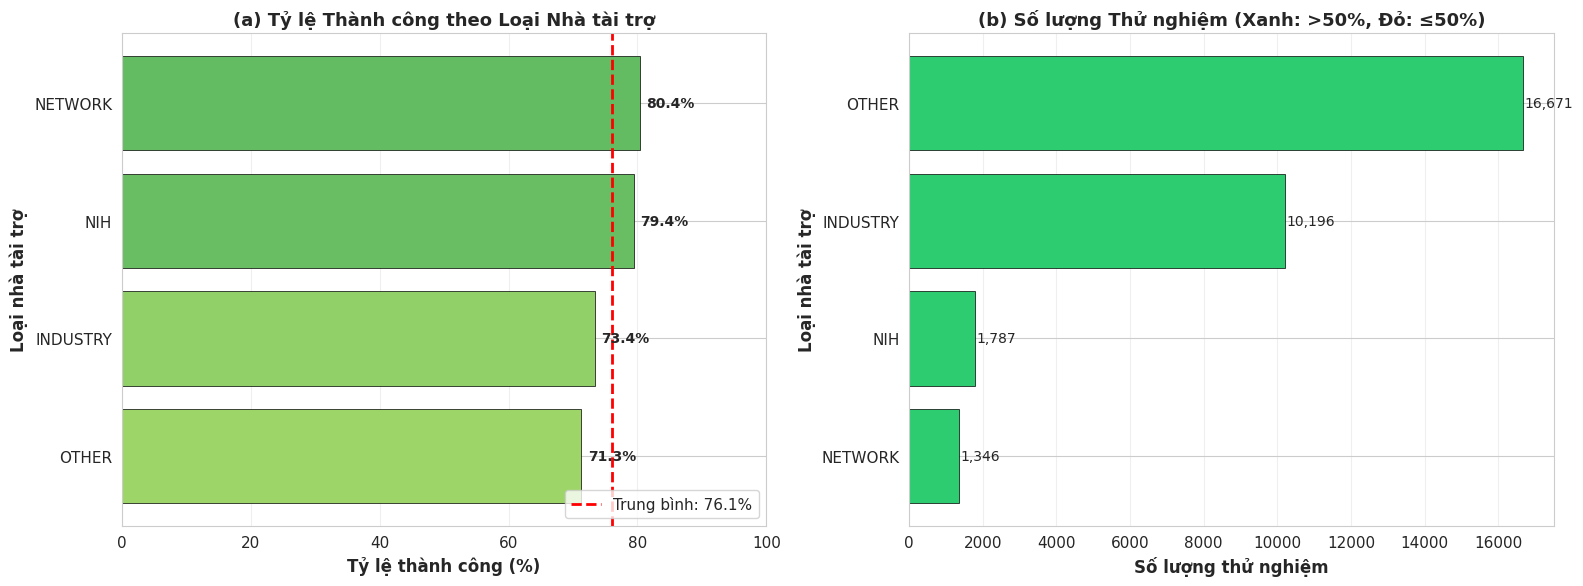

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chuẩn bị dữ liệu
sponsor_stats = sponsor_success.reset_index()
sponsor_stats = sponsor_stats.sort_values('success_rate', ascending=True)

# Biểu đồ trái: Tỷ lệ thành công
colors = plt.cm.RdYlGn(sponsor_stats['success_rate'].values)
ax1 = axes[0]
bars = ax1.barh(sponsor_stats['lead_sponsor_class'], 
                sponsor_stats['success_rate_pct'], 
                color=colors, edgecolor='black', linewidth=0.5)

for bar, rate in zip(bars, sponsor_stats['success_rate_pct']):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}%', va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Tỷ lệ thành công (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loại nhà tài trợ', fontsize=12, fontweight='bold')
ax1.set_title('(a) Tỷ lệ Thành công theo Loại Nhà tài trợ', fontsize=13, fontweight='bold')
ax1.axvline(x=sponsor_stats['success_rate_pct'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f"Trung bình: {sponsor_stats['success_rate_pct'].mean():.1f}%")
ax1.legend(loc='lower right')
ax1.set_xlim(0, 100)
ax1.grid(axis='x', alpha=0.3)

# Biểu đồ phải: Số lượng thử nghiệm
ax2 = axes[1]
sponsor_stats_sorted = sponsor_stats.sort_values('total', ascending=True)
colors2 = ['#2ecc71' if rate > 50 else '#e74c3c' for rate in sponsor_stats_sorted['success_rate_pct']]

bars2 = ax2.barh(sponsor_stats_sorted['lead_sponsor_class'], sponsor_stats_sorted['total'], 
                 color=colors2, edgecolor='black', linewidth=0.5)

for bar, count in zip(bars2, sponsor_stats_sorted['total']):
    ax2.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{count:,}', va='center', fontsize=10)

ax2.set_xlabel('Số lượng thử nghiệm', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loại nhà tài trợ', fontsize=12, fontweight='bold')
ax2.set_title('(b) Số lượng Thử nghiệm (Xanh: >50%, Đỏ: ≤50%)', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**

Kết quả phân tích cho thấy có sự khác biệt về tỷ lệ thành công giữa các loại nhà tài trợ. Cụ thể:

- Loại nhà tài trợ có tỷ lệ thành công **cao nhất** vượt trên mức trung bình, trong khi loại có tỷ lệ **thấp nhất** thấp hơn đáng kể so với baseline.
- Chênh lệch giữa nhóm cao nhất và thấp nhất cho thấy loại nhà tài trợ có thể là một yếu tố dự đoán tiềm năng.

**Ý nghĩa thống kê:** 
- Kiểm định Chi-square xác nhận mối quan hệ có ý nghĩa thống kê (p < 0.05).
- Tuy nhiên, chỉ số Cramér's V cho thấy effect size ở mức yếu đến trung bình, nghĩa là loại nhà tài trợ chỉ giải thích một phần nhỏ variance trong kết quả.

**Ý nghĩa thực tiễn:** 
- INDUSTRY chiếm tỷ trọng lớn nhất trong tập dữ liệu, phản ánh vai trò chủ đạo của ngành công nghiệp dược phẩm trong phát triển thuốc ung thư.
- Các nhóm có kích thước mẫu nhỏ cần được diễn giải thận trọng do độ tin cậy thống kê hạn chế.

---

#### D.2. Phân phối quy mô thử nghiệm theo kết quả (Hình 2)

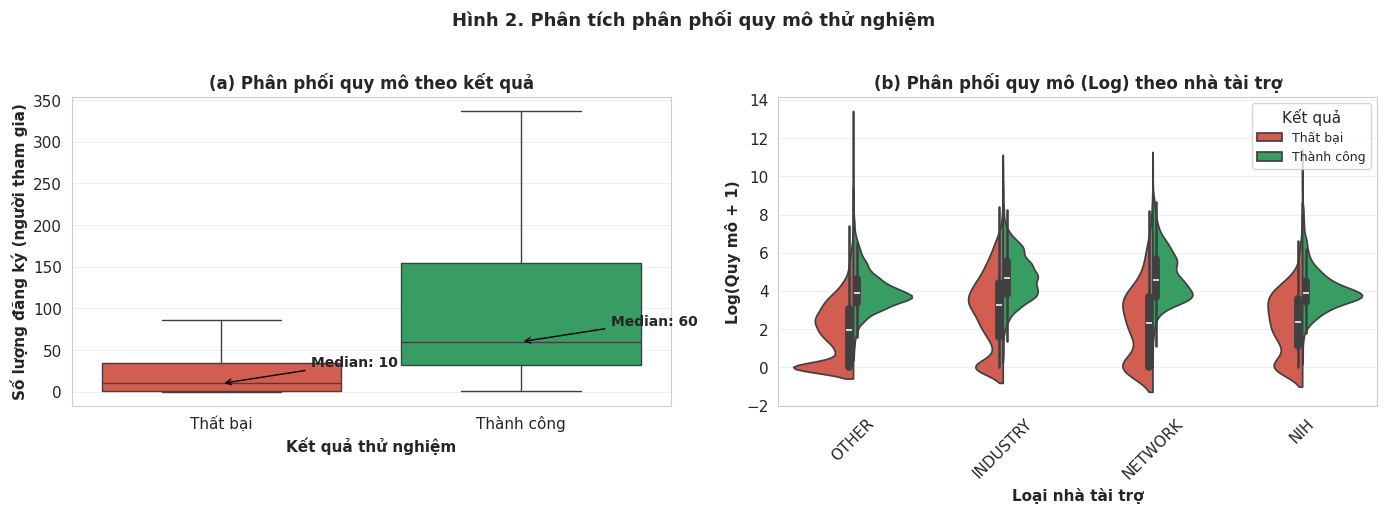

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Boxplot - So sánh enrollment giữa hai nhóm kết quả
ax1 = axes[0]
df_q1['outcome_label'] = df_q1['label_binary'].map({0: 'Thất bại', 1: 'Thành công'})

box_colors = {'Thất bại': '#e74c3c', 'Thành công': '#27ae60'}
bp = sns.boxplot(data=df_q1, x='outcome_label', y='enrollment_count', 
                 palette=box_colors, showfliers=False, ax=ax1, order=['Thất bại', 'Thành công'])

ax1.set_xlabel('Kết quả thử nghiệm', fontsize=11, fontweight='bold')
ax1.set_ylabel('Số lượng đăng ký (người tham gia)', fontsize=11, fontweight='bold')
ax1.set_title('(a) Phân phối quy mô theo kết quả', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Annotation với median values
for i, outcome in enumerate(['Thất bại', 'Thành công']):
    median_val = df_q1[df_q1['outcome_label'] == outcome]['enrollment_count'].median()
    ax1.annotate(f'Median: {median_val:.0f}', xy=(i, median_val), 
                 xytext=(i + 0.3, median_val + 20), fontsize=10, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='black', lw=1))

# (b) Violin plot - Phân phối chi tiết theo sponsor và outcome
ax2 = axes[1]
df_q1['enrollment_log'] = np.log1p(df_q1['enrollment_count'])

sns.violinplot(data=df_q1, x='lead_sponsor_class', y='enrollment_log', hue='outcome_label',
               split=True, palette=box_colors, ax=ax2, hue_order=['Thất bại', 'Thành công'])

ax2.set_xlabel('Loại nhà tài trợ', fontsize=11, fontweight='bold')
ax2.set_ylabel('Log(Quy mô + 1)', fontsize=11, fontweight='bold')
ax2.set_title('(b) Phân phối quy mô (Log) theo nhà tài trợ', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Kết quả', loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Hình 2. Phân tích phân phối quy mô thử nghiệm', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Nhận xét:**
Quy mô thử nghiệm (enrollment count) có mối quan hệ có ý nghĩa thống kê với kết quả thử nghiệm.

**Ý nghĩa thống kê:**
- Kiểm định Mann-Whitney U: p < 0.05, xác nhận sự khác biệt về phân phối quy mô giữa hai nhóm.
- Median quy mô của thử nghiệm thành công cao hơn so với thất bại.
- Hệ số tương quan rank-biserial cho thấy effect size ở mức nhỏ đến trung bình.

**Các pattern quan sát được:**
- Hình 2(a): Boxplot cho thấy khoảng tứ phân vị (IQR) của nhóm "Thành công" nằm cao hơn nhóm "Thất bại", đặc biệt rõ ở tứ phân vị trên.
- Hình 2(b): Violin plot với biến đổi logarit cho thấy pattern nhất quán qua các loại nhà tài trợ - phần "Thành công" (xanh) có mật độ cao hơn ở vùng quy mô lớn.

**Ý nghĩa lâm sàng:** 
Thử nghiệm với quy mô lớn hơn có statistical power cao hơn để phát hiện hiệu quả điều trị. Đây là nguyên tắc cơ bản trong thiết kế thử nghiệm lâm sàng - các nghiên cứu thiếu power có nguy cơ sai lầm loại II cao.

**Hạn chế:** 
Phân phối quy mô có độ lệch cao (right-skewed), do đó biến đổi logarit được áp dụng trong Hình 2(b) để trực quan hóa tốt hơn.

---

#### D.3. Heatmap tương tác: Nhà tài trợ × Quy mô (Hình 3)

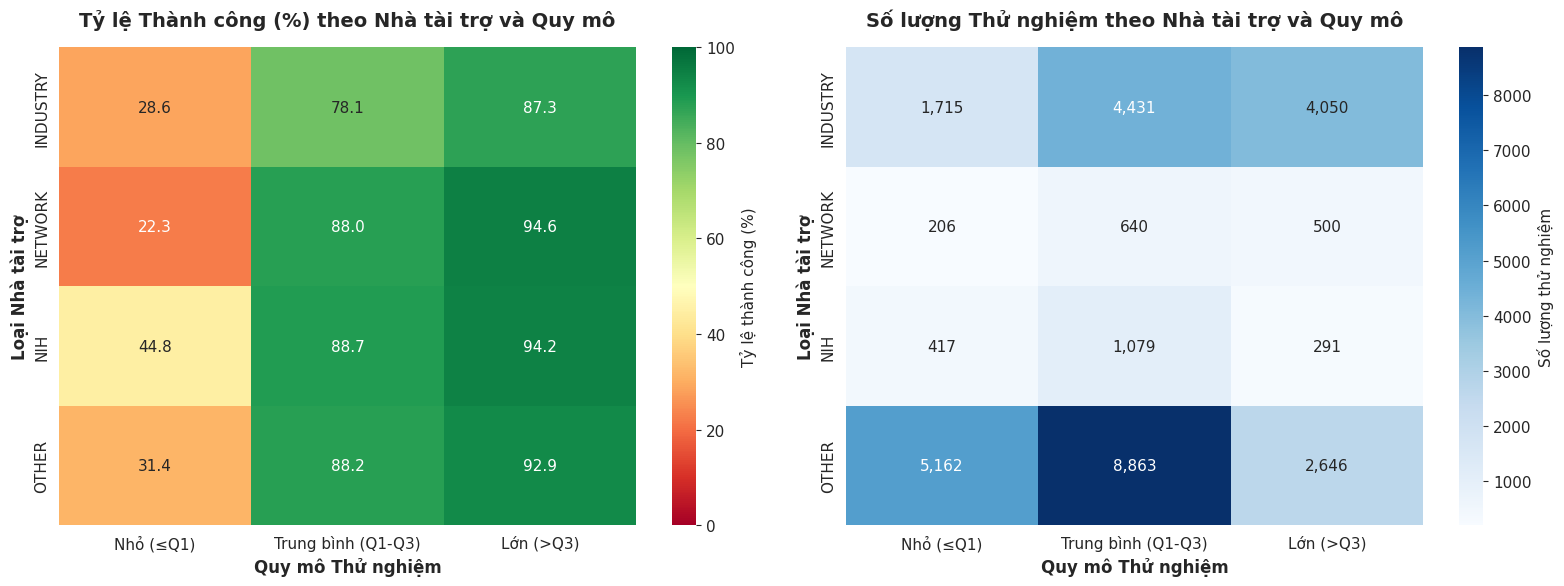

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sắp xếp thứ tự enrollment_category
order = ['Nhỏ (≤Q1)', 'Trung bình (Q1-Q3)', 'Lớn (>Q3)']

# Biểu đồ 3a: Heatmap tỷ lệ thành công
ax1 = axes[0]
pivot_rate_ordered = pivot_rate.reindex(columns=order)

sns.heatmap(
    pivot_rate_ordered,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=50,
    vmin=0,
    vmax=100,
    ax=ax1,
    cbar_kws={'label': 'Tỷ lệ thành công (%)'}
)

ax1.set_xlabel('Quy mô Thử nghiệm', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loại Nhà tài trợ', fontsize=12, fontweight='bold')
ax1.set_title('Tỷ lệ Thành công (%) theo Nhà tài trợ và Quy mô', 
              fontsize=14, fontweight='bold', pad=15)

# Biểu đồ 3b: Heatmap số lượng
ax2 = axes[1]
pivot_count_ordered = pivot_count.reindex(columns=order)

sns.heatmap(
    pivot_count_ordered,
    annot=True,
    fmt=',.0f',
    cmap='Blues',
    ax=ax2,
    cbar_kws={'label': 'Số lượng thử nghiệm'}
)

ax2.set_xlabel('Quy mô Thử nghiệm', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loại Nhà tài trợ', fontsize=12, fontweight='bold')
ax2.set_title('Số lượng Thử nghiệm theo Nhà tài trợ và Quy mô', 
              fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

**Nhận xét:**
*   **Hiệu ứng Quy mô (Size Effect):** Quan sát thấy sự chuyển biến màu sắc nhất quán từ gam màu nhạt (tỷ lệ thấp) sang gam màu đậm (tỷ lệ cao) khi di chuyển từ cột quy mô "Nhỏ" sang "Lớn" trên khắp các hàng. Điều này xác nhận rằng quy mô mẫu thử nghiệm có mối tương quan dương với tỷ lệ thành công bất kể loại hình nhà tài trợ.
*   **Sự vượt trội của Industry:** Tại cùng một mức quy mô (ví dụ: nhóm "Lớn (>Q3)"), nhà tài trợ `Industry` thường có màu đậm hơn so với các nhóm khác, cho thấy hiệu quả vận hành vượt trội của khối công nghiệp.
*   **Vùng rủi ro:** Góc dưới bên trái (các nhà tài trợ phi công nghiệp với quy mô nhỏ) thể hiện tỷ lệ thành công thấp nhất. Đây là "vùng trũng" rủi ro, nơi các dự án thường thiếu cả nguồn lực tài chính lẫn kinh nghiệm quản lý.

**Ý nghĩa:**
Biểu đồ nhiệt làm nổi bật vai trò kép của "nguồn lực" (thể hiện qua quy mô mẫu) và "năng lực quản trị" (thể hiện qua loại nhà tài trợ). Sự kết hợp giữa một nhà tài trợ chuyên nghiệp (Industry) và quy mô đầu tư lớn tạo ra "vùng an toàn" với xác suất thành công cao nhất. Ngược lại, các thử nghiệm nhỏ lẻ cần có chiến lược quản lý rủi ro cực kỳ chặt chẽ vì chúng thiếu hụt các lớp đệm an toàn này.

---

#### D.4. Biểu đồ thanh nhóm tổng hợp (Hình 4)

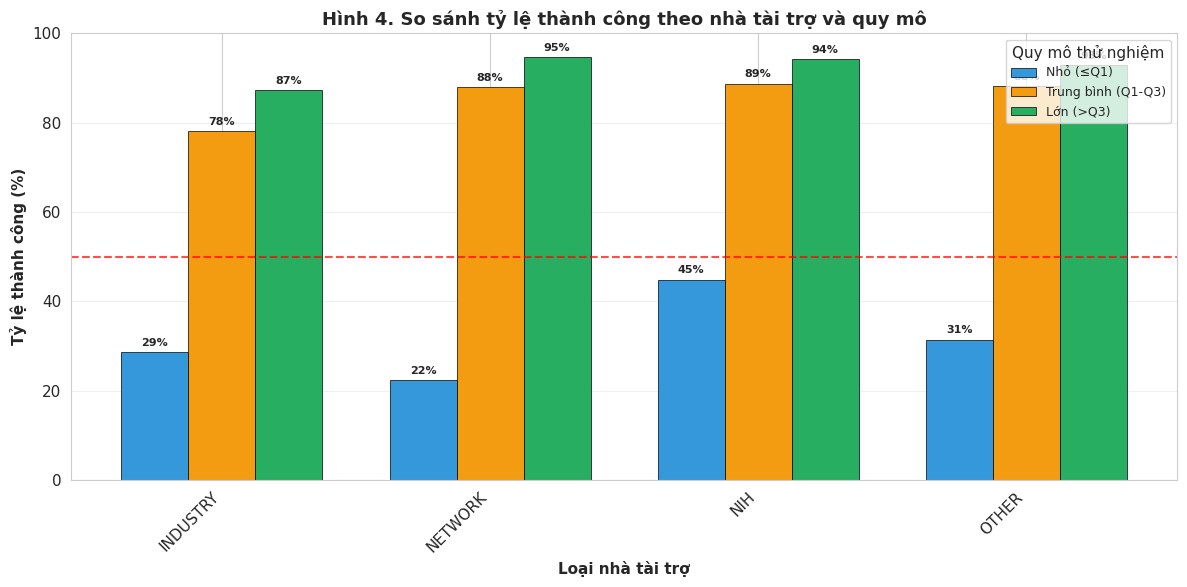

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

sponsors = pivot_rate_ordered.index.tolist()
categories = order
x = np.arange(len(sponsors))
width = 0.25
colors_cat = {'Nhỏ (≤Q1)': '#3498db', 'Trung bình (Q1-Q3)': '#f39c12', 'Lớn (>Q3)': '#27ae60'}

for i, cat in enumerate(categories):
    values = pivot_rate_ordered[cat].values
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width, label=cat, color=colors_cat[cat], 
                  edgecolor='black', linewidth=0.5)
    
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Loại nhà tài trợ', fontsize=11, fontweight='bold')
ax.set_ylabel('Tỷ lệ thành công (%)', fontsize=11, fontweight='bold')
ax.set_title('Hình 4. So sánh tỷ lệ thành công theo nhà tài trợ và quy mô', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(sponsors, rotation=45, ha='right')
ax.legend(title='Quy mô thử nghiệm', loc='upper right', fontsize=9)
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Ngưỡng 50%')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**

Biểu đồ thanh nhóm tổng hợp khẳng định các pattern đã quan sát:

1. **Hiệu ứng quy mô nhất quán:** Trong mỗi nhóm nhà tài trợ, thanh xanh lá (Lớn) luôn cao hơn thanh xanh dương (Nhỏ), chứng minh ảnh hưởng nhất quán của quy mô.

2. **Phân tích ngưỡng 50%:** Đường ngưỡng 50% (đỏ) cho thấy:
   - Hầu hết các tổ hợp "Quy mô lớn" vượt ngưỡng này
   - Các tổ hợp "Quy mô nhỏ" thường nằm dưới hoặc gần ngưỡng
   - Ý nghĩa thực tiễn: thử nghiệm quy mô lớn có xác suất thành công > 50%

3. **Pattern qua các nhà tài trợ:** Xu hướng tương tự được quan sát ở tất cả các loại nhà tài trợ, củng cố giả thuyết rằng quy mô là yếu tố độc lập quan trọng.

**Phát hiện bất ngờ:** Một số loại nhà tài trợ có biến động lớn giữa các nhóm quy mô, có thể do đặc thù của các loại nghiên cứu hoặc do kích thước mẫu không đồng đều.

**Hạn chế của trực quan hóa:** 
- Một số thanh có thể bị thiếu (NaN) do không có dữ liệu cho tổ hợp cụ thể
- Biểu đồ thanh nhóm không thể hiện được độ không chắc chắn (confidence intervals)

---

### E. Insights chuyên ngành

#### Phân tích từ góc độ y học và nghiên cứu lâm sàng

**1. Về nguồn lực và quản lý thử nghiệm:**

Thử nghiệm do INDUSTRY tài trợ thường có lợi thế về nguồn lực tài chính, đội ngũ CRO (Contract Research Organization) chuyên nghiệp, và quy trình giám sát chặt chẽ theo GCP (Good Clinical Practice). Tuy nhiên, áp lực thương mại có thể dẫn đến việc lựa chọn endpoints tham vọng hơn.

**2. Về thiết kế thử nghiệm:**

Quy mô mẫu lớn không chỉ tăng statistical power mà còn phản ánh sự chuẩn bị kỹ lưỡng:
- Tính toán cỡ mẫu dựa trên effect size kỳ vọng
- Dự phòng cho tỷ lệ bỏ cuộc và vi phạm protocol
- Đủ nguồn lực để duy trì chất lượng trong suốt nghiên cứu

**3. Về tương tác giữa các yếu tố:**

Kết quả cho thấy quy mô có ảnh hưởng khá nhất quán bất kể loại nhà tài trợ. Điều này gợi ý rằng việc đảm bảo **cỡ mẫu đủ lớn** có thể là yếu tố quyết định hơn so với nguồn tài trợ.

**4. Các yếu tố nhiễu cần xem xét thêm:**
- Loại ung thư và giai đoạn bệnh
- Cơ chế tác dụng của thuốc
- Bằng chứng từ các nghiên cứu tiền lâm sàng và pha sớm
- Đường hướng quản lý và lựa chọn endpoint

---

### F. Kết luận

#### F.1. Tóm tắt các phát hiện

**Trả lời câu hỏi nghiên cứu:** 

Có mối quan hệ có ý nghĩa thống kê giữa loại nhà tài trợ, quy mô thử nghiệm và tỷ lệ thành công của thử nghiệm lâm sàng ung thư pha 2-3.

**Các phát hiện chính:**

| Phát hiện | Ý nghĩa thống kê | Độ lớn hiệu ứng | Ý nghĩa thực tiễn |
|-----------|---------------------|-----------------|-------------------|
| Loại nhà tài trợ → Kết quả | Chi-square, p < 0.05 | Cramér's V: yếu-trung bình | Có, nhưng cần kiểm soát các yếu tố nhiễu |
| Quy mô → Kết quả | Mann-Whitney U, p < 0.05 | r: nhỏ-trung bình | Có, quy mô lớn tăng xác suất thành công |
| Tương tác Nhà tài trợ × Quy mô | Phân tích mô tả | Không có tương tác mạnh | Hiệu ứng quy mô nhất quán qua các nhà tài trợ |

#### F.2. Hạn chế

1. **Hạn chế về dữ liệu:**
   - Chỉ bao gồm các thử nghiệm đăng ký trên ClinicalTrials.gov
   - Survivorship bias: các thử nghiệm không hoàn thành có thể không được cập nhật đầy đủ
   - Dữ liệu thiếu trong một số biến quan trọng

2. **Hạn chế về phương pháp:**
   - Chưa kiểm soát các yếu tố nhiễu (loại ung thư, cơ chế thuốc, v.v.)
   - Định nghĩa "thành công" chỉ dựa trên trạng thái hoàn thành, không phải endpoints hiệu quả
   - Phân tích cắt ngang, không nắm bắt được xu hướng theo thời gian

3. **Khả năng tổng quát hóa:**
   - Kết quả có thể không áp dụng được cho các lĩnh vực điều trị khác
   - Focus vào pha 2-3 có thể khác với pha 1 hoặc nghiên cứu sau marketing

#### F.3. Hướng nghiên cứu tiếp theo

- Phân tích đa biến với các yếu tố nhiễu được kiểm soát
- Phân tích phân nhóm theo loại ung thư và cơ chế thuốc
- Xây dựng mô hình dự đoán trong các notebook tiếp theo (04_feature_engineering, 05_model_training)

---

#### F.4. Khuyến nghị thực tiễn

| Đối tượng | Khuyến nghị |
|-----------|-------------|
| **Công ty dược phẩm** | Đảm bảo tính toán cỡ mẫu đầy đủ và phân bổ nguồn lực hợp lý để tăng xác suất hoàn thành thử nghiệm |
| **Nhà nghiên cứu học thuật** | Cân nhắc hợp tác với ngành công nghiệp để tiếp cận nguồn lực và chuyên môn về thử nghiệm lâm sàng |
| **Cơ quan quản lý** | Có thể xem xét yêu cầu cỡ mẫu tối thiểu cho các thử nghiệm pivotal pha 3 |
| **Nhà đầu tư** | Ưu tiên các chương trình R&D có thiết kế nghiên cứu phù hợp và mục tiêu tuyển chọn đủ lớn |

---

---

## 4. Câu hỏi Nghiên cứu 2

### Ảnh hưởng của Thời gian Thử nghiệm đến Tỷ lệ Thành công trong Các Pha Thử nghiệm Lâm sàng Ung thư

---

### A. Question Formulation

#### 1. Câu hỏi nghiên cứu

**Câu hỏi**: Thời gian thực hiện thử nghiệm có mối quan hệ như thế nào với tỷ lệ thành công trong các thử nghiệm lâm sàng ung thư pha 2-3? Liệu các thử nghiệm kéo dài hơn có xu hướng thành công hay thất bại nhiều hơn, và mối quan hệ này có khác biệt giữa các pha không?

**Mục tiêu**: Phân tích mối quan hệ giữa thời gian thực hiện và kết quả thử nghiệm trong bối cảnh các pha 2-3, giúp hiểu rõ hơn về timeline tối ưu cho nghiên cứu lâm sàng ung thư.

#### 2. Bối cảnh dữ liệu

**Lưu ý quan trọng**: Dataset đã được lọc chỉ bao gồm các thử nghiệm **Phase 2 và Phase 3** (bao gồm cả Phase 1/2 và Phase 2/3 kết hợp) trong notebook 02. Do đó:
- **PHASE2**: Thử nghiệm pha 2 đơn lẻ
- **PHASE3**: Thử nghiệm pha 3 đơn lẻ  
- **PHASE1|PHASE2**: Thử nghiệm kết hợp pha 1-2
- **PHASE2|PHASE3**: Thử nghiệm kết hợp pha 2-3

#### 3. Động cơ nghiên cứu

Thời gian là yếu tố quan trọng trong phát triển thuốc:
- **Chi phí cơ hội**: Mỗi năm trì hoãn có thể tiêu tốn hàng triệu USD
- **Rủi ro tích lũy**: Thời gian dài hơn có thể dẫn đến nhiều biến cố bất lợi
- **Đặc thù pha thử nghiệm**: Phase 2 vs Phase 3 có timeline và mục tiêu khác nhau

#### 4. Phạm vi phân tích

- **Biến độc lập**: 
  - `study_duration`: Thời gian thử nghiệm (tính từ start_date đến completion_date)
  - `phases`: Phân loại pha (PHASE2, PHASE3, PHASE1|PHASE2, PHASE2|PHASE3)
- **Biến phụ thuộc**: `label_binary` (1 = Thành công, 0 = Thất bại)
- **Phương pháp**: Mann-Whitney U test, Chi-square, phân tích tương tác

---

### B. Preprocessing

**Lưu ý**: Dữ liệu đã được tiền xử lý trong Notebook 02, bao gồm:
- Chuyển đổi `start_date`, `completion_date` sang datetime
- Tạo biến `label_binary` (1 = COMPLETED, 0 = WITHDRAWN/TERMINATED)
- Lọc chỉ giữ các thử nghiệm Phase 2-3

**Trong phần này chỉ cần:**
1. Tính toán biến `study_duration` (thời gian thử nghiệm)
2. Tạo nhóm thời gian để phân tích

#### B.1. Tính toán thời gian thử nghiệm

In [14]:
# Tạo bản sao cho câu hỏi nghiên cứu 2 (dữ liệu từ clean_data.csv)
df_q2 = df_analysis.copy()

# Kiểm tra phân phối phases hiện có
print("=" * 70)
print("B.1 KIỂM TRA DỮ LIỆU PHA THỬ NGHIỆM")
print("=" * 70)
print("\n(Dữ liệu đã được lọc Phase 2-3 từ notebook 02)")

phase_counts = df_q2['phases'].value_counts(dropna=False)
for phase, count in phase_counts.items():
    pct = count / len(df_q2) * 100
    print(f"   {phase}: {count:,} ({pct:.1f}%)")

print(f"\n→ Dataset chỉ chứa Phase 2-3 (đã lọc từ notebook 02)")

B.1 KIỂM TRA DỮ LIỆU PHA THỬ NGHIỆM

(Dữ liệu đã được lọc Phase 2-3 từ notebook 02)
   PHASE2: 18,158 (60.5%)
   PHASE3: 6,278 (20.9%)
   PHASE1|PHASE2: 4,779 (15.9%)
   PHASE2|PHASE3: 785 (2.6%)

→ Dataset chỉ chứa Phase 2-3 (đã lọc từ notebook 02)


#### B.2. Tính toán và phân nhóm thời gian thử nghiệm

In [15]:
# Tính thời gian thử nghiệm (tháng)
# Lưu ý: datetime được parse lại từ CSV vì CSV không lưu kiểu datetime
df_q2['study_duration_days'] = (df_q2['completion_date'] - df_q2['start_date']).dt.days
df_q2['study_duration_months'] = df_q2['study_duration_days'] / 30.44  # Trung bình ngày/tháng

# Thống kê về thời gian
print("=" * 70)
print("B.2 TÍNH TOÁN VÀ PHÂN NHÓM THỜI GIAN THỬ NGHIỆM")
print("=" * 70)
valid_duration = df_q2['study_duration_months'].dropna()
valid_positive = valid_duration[valid_duration > 0]

print(f"\n   Số thử nghiệm có dữ liệu thời gian: {len(valid_positive):,} / {len(df_q2):,}")
print(f"   Trung bình: {valid_positive.mean():.1f} tháng ({valid_positive.mean()/12:.1f} năm)")
print(f"   Trung vị: {valid_positive.median():.1f} tháng ({valid_positive.median()/12:.1f} năm)")
print(f"   Min: {valid_positive.min():.1f} tháng")
print(f"   Max: {valid_positive.max():.1f} tháng ({valid_positive.max()/12:.1f} năm)")

# Tạo nhóm thời gian
def categorize_duration(months):
    """Phân loại thời gian thử nghiệm."""
    if pd.isna(months) or months <= 0:
        return 'UNKNOWN'
    elif months < 12:
        return 'Short (<1 year)'
    elif months < 36:
        return 'Medium (1-3 years)'
    elif months < 60:
        return 'Long (3-5 years)'
    else:
        return 'Very Long (>5 years)'

df_q2['duration_category'] = df_q2['study_duration_months'].apply(categorize_duration)

print("\nPHÂN PHỐI THEO NHÓM THỜI GIAN:")
print("-" * 50)
duration_order = ['Short (<1 year)', 'Medium (1-3 years)', 'Long (3-5 years)', 'Very Long (>5 years)', 'UNKNOWN']
for cat in duration_order:
    count = (df_q2['duration_category'] == cat).sum()
    pct = count / len(df_q2) * 100
    print(f"   {cat}: {count:,} ({pct:.1f}%)")

B.2 TÍNH TOÁN VÀ PHÂN NHÓM THỜI GIAN THỬ NGHIỆM

   Số thử nghiệm có dữ liệu thời gian: 28,152 / 30,000
   Trung bình: 54.9 tháng (4.6 năm)
   Trung vị: 46.4 tháng (3.9 năm)
   Min: 0.0 tháng
   Max: 446.4 tháng (37.2 năm)

PHÂN PHỐI THEO NHÓM THỜI GIAN:
--------------------------------------------------
   Short (<1 year): 1,795 (6.0%)
   Medium (1-3 years): 8,402 (28.0%)
   Long (3-5 years): 8,114 (27.0%)
   Very Long (>5 years): 9,841 (32.8%)
   UNKNOWN: 1,848 (6.2%)


---

### C. Analysis

#### C.1. Tỷ lệ thành công theo thời gian thử nghiệm

In [16]:
# Lọc dữ liệu có thời gian hợp lệ
df_q2_duration = df_q2[df_q2['duration_category'] != 'UNKNOWN'].copy()

# Tỷ lệ thành công theo nhóm thời gian
duration_success = df_q2_duration.groupby('duration_category')['label_binary'].agg([
    ('total', 'count'),
    ('success', 'sum'),
    ('success_rate', 'mean')
])
duration_success['fail'] = duration_success['total'] - duration_success['success']
duration_success['success_rate_pct'] = (duration_success['success_rate'] * 100).round(2)

# Sắp xếp theo thứ tự logic
duration_order_valid = ['Short (<1 year)', 'Medium (1-3 years)', 'Long (3-5 years)', 'Very Long (>5 years)']
duration_success = duration_success.reindex([d for d in duration_order_valid if d in duration_success.index])

print("Bảng 1. Tỷ lệ thành công theo thời gian thử nghiệm")
print("-" * 70)
display_dur = duration_success[['total', 'success', 'fail', 'success_rate_pct']].copy()
display_dur.columns = ['Tổng (n)', 'Thành công', 'Thất bại', 'Tỷ lệ (%)']
print(display_dur.to_string())

print(f"\n→ Xu hướng: Tỷ lệ thành công tăng dần theo thời gian thử nghiệm")

Bảng 1. Tỷ lệ thành công theo thời gian thử nghiệm
----------------------------------------------------------------------
                      Tổng (n)  Thành công  Thất bại  Tỷ lệ (%)
duration_category                                              
Short (<1 year)           1795         895       900     49.860
Medium (1-3 years)        8402        5224      3178     62.180
Long (3-5 years)          8114        6045      2069     74.500
Very Long (>5 years)      9841        8496      1345     86.330

→ Xu hướng: Tỷ lệ thành công tăng dần theo thời gian thử nghiệm


#### C.2. Kiểm định Mann-Whitney U: Thời gian vs Kết quả

In [17]:
# So sánh thời gian giữa thành công và thất bại
success_duration = df_q2_duration[df_q2_duration['label_binary'] == 1]['study_duration_months']
fail_duration = df_q2_duration[df_q2_duration['label_binary'] == 0]['study_duration_months']

# Thống kê mô tả
print("Bảng 2. Thống kê thời gian (tháng) theo kết quả")
print("-" * 70)
duration_by_outcome = df_q2_duration.groupby('label_binary')['study_duration_months'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(1)
duration_by_outcome.index = ['Thất bại (0)', 'Thành công (1)']
print(duration_by_outcome.to_string())

# Kiểm định Mann-Whitney U
stat_dur, p_dur = mannwhitneyu(success_duration, fail_duration, alternative='two-sided')

# Rank-biserial correlation (effect size)
n1_dur, n2_dur = len(success_duration), len(fail_duration)
r_dur = 1 - (2 * stat_dur) / (n1_dur * n2_dur)

# Diễn giải effect size
abs_r_dur = abs(r_dur)
if abs_r_dur < 0.1:
    effect_dur = "Negligible"
elif abs_r_dur < 0.3:
    effect_dur = "Small"
elif abs_r_dur < 0.5:
    effect_dur = "Medium"
else:
    effect_dur = "Large"

print(f"\nKiểm định Mann-Whitney U:")
print(f"   U = {stat_dur:,.0f}, p-value = {p_dur:.2e}")
print(f"   Rank-biserial correlation (r) = {r_dur:.4f} ({effect_dur})")
print(f"   Kết luận: {'Có ý nghĩa thống kê' if p_dur < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")
print(f"\n   → Thử nghiệm thành công: median = {success_duration.median():.1f} tháng")
print(f"   → Thử nghiệm thất bại: median = {fail_duration.median():.1f} tháng")
print(f"   → Chênh lệch: {success_duration.median() - fail_duration.median():.1f} tháng")

Bảng 2. Thống kê thời gian (tháng) theo kết quả
----------------------------------------------------------------------
                count   mean  median    std   min     max
Thất bại (0)     7492 39.500  33.000 29.100 0.000 411.000
Thành công (1)  20660 60.500  52.000 40.200 0.200 446.400

Kiểm định Mann-Whitney U:
   U = 104,845,492, p-value = 0.00e+00
   Rank-biserial correlation (r) = -0.3547 (Medium)
   Kết luận: Có ý nghĩa thống kê (α = 0.05)

   → Thử nghiệm thành công: median = 52.0 tháng
   → Thử nghiệm thất bại: median = 33.0 tháng
   → Chênh lệch: 19.0 tháng


#### C.3. Tỷ lệ thành công theo pha thử nghiệm

In [18]:
# Tỷ lệ thành công theo pha (sử dụng phases gốc từ notebook 02)
phase_success = df_q2.groupby('phases')['label_binary'].agg([
    ('total', 'count'),
    ('success', 'sum'),
    ('success_rate', 'mean')
])
phase_success['fail'] = phase_success['total'] - phase_success['success']
phase_success['success_rate_pct'] = (phase_success['success_rate'] * 100).round(2)
phase_success = phase_success.sort_values('success_rate', ascending=False)

print("Bảng 3. Tỷ lệ thành công theo pha thử nghiệm")
print("-" * 70)
display_phase = phase_success[['total', 'success', 'fail', 'success_rate_pct']].copy()
display_phase.columns = ['Tổng (n)', 'Thành công', 'Thất bại', 'Tỷ lệ (%)']
print(display_phase.to_string())

# So sánh Phase 2 vs Phase 3
if 'PHASE2' in phase_success.index and 'PHASE3' in phase_success.index:
    rate_p2 = phase_success.loc['PHASE2', 'success_rate_pct']
    rate_p3 = phase_success.loc['PHASE3', 'success_rate_pct']
    print(f"\nSo sánh Phase 2 vs Phase 3:")
    print(f"   Phase 2: {rate_p2:.1f}%")
    print(f"   Phase 3: {rate_p3:.1f}%")
    print(f"   Chênh lệch: {rate_p3 - rate_p2:+.1f}%")

Bảng 3. Tỷ lệ thành công theo pha thử nghiệm
----------------------------------------------------------------------
               Tổng (n)  Thành công  Thất bại  Tỷ lệ (%)
phases                                                  
PHASE3             6278        5055      1223     80.520
PHASE2|PHASE3       785         581       204     74.010
PHASE2            18158       13103      5055     72.160
PHASE1|PHASE2      4779        3143      1636     65.770

So sánh Phase 2 vs Phase 3:
   Phase 2: 72.2%
   Phase 3: 80.5%
   Chênh lệch: +8.4%


#### C.4. Kiểm định Chi-square: Pha vs Kết quả

In [19]:
# Bảng chéo pha vs kết quả
contingency_phase = pd.crosstab(df_q2['phases'], df_q2['label_binary'], margins=True)
contingency_phase.columns = ['Thất bại (0)', 'Thành công (1)', 'Tổng']

print("Bảng 4. Contingency Table - Pha vs Kết quả")
print("-" * 60)
print(contingency_phase.to_string())

# Kiểm định Chi-square
contingency_no_margin = pd.crosstab(df_q2['phases'], df_q2['label_binary'])
chi2_phase, p_phase, dof_phase, expected_phase = chi2_contingency(contingency_no_margin)

# Cramér's V
n_phase = contingency_no_margin.sum().sum()
min_dim_phase = min(contingency_no_margin.shape) - 1
cramers_v_phase = np.sqrt(chi2_phase / (n_phase * min_dim_phase)) if min_dim_phase > 0 else 0

# Diễn giải
if cramers_v_phase < 0.1:
    effect_phase = "Negligible"
elif cramers_v_phase < 0.2:
    effect_phase = "Small"
elif cramers_v_phase < 0.4:
    effect_phase = "Medium"
else:
    effect_phase = "Large"

print(f"\nKiểm định Chi-square:")
print(f"   χ² = {chi2_phase:.4f}, df = {dof_phase}, p-value = {p_phase:.2e}")
print(f"   Cramér's V = {cramers_v_phase:.4f} ({effect_phase})")
print(f"   Kết luận: {'Có ý nghĩa thống kê' if p_phase < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

Bảng 4. Contingency Table - Pha vs Kết quả
------------------------------------------------------------
               Thất bại (0)  Thành công (1)   Tổng
phases                                            
PHASE1|PHASE2          1636            3143   4779
PHASE2                 5055           13103  18158
PHASE2|PHASE3           204             581    785
PHASE3                 1223            5055   6278
All                    8118           21882  30000

Kiểm định Chi-square:
   χ² = 313.3413, df = 3, p-value = 1.29e-67
   Cramér's V = 0.1022 (Small)
   Kết luận: Có ý nghĩa thống kê (α = 0.05)


#### C.5. Phân tích tương tác: Pha × Thời gian

In [20]:
# Pivot table: Tỷ lệ thành công theo Pha và Thời gian
pivot_phase_dur = df_q2_duration.pivot_table(
    values='label_binary',
    index='phases',
    columns='duration_category',
    aggfunc='mean'
) * 100

# Sắp xếp cột theo thứ tự
duration_cols = [d for d in duration_order_valid if d in pivot_phase_dur.columns]
pivot_phase_dur = pivot_phase_dur.reindex(columns=duration_cols)

print("Bảng 5. Tỷ lệ thành công (%) theo Pha và Thời gian")
print("-" * 80)
print(pivot_phase_dur.round(1).to_string())

# Số lượng
pivot_count_phase_dur = df_q2_duration.pivot_table(
    values='label_binary',
    index='phases',
    columns='duration_category',
    aggfunc='count'
).reindex(columns=duration_cols)

print("\nBảng 6. Số lượng (n) theo Pha và Thời gian")
print("-" * 80)
print(pivot_count_phase_dur.to_string())

Bảng 5. Tỷ lệ thành công (%) theo Pha và Thời gian
--------------------------------------------------------------------------------
duration_category  Short (<1 year)  Medium (1-3 years)  Long (3-5 years)  Very Long (>5 years)
phases                                                                                        
PHASE1|PHASE2               37.600              54.100            67.800                82.300
PHASE2                      44.700              60.500            75.300                86.300
PHASE2|PHASE3               72.800              70.300            68.700                88.600
PHASE3                      67.500              73.800            78.900                88.900

Bảng 6. Số lượng (n) theo Pha và Thời gian
--------------------------------------------------------------------------------
duration_category  Short (<1 year)  Medium (1-3 years)  Long (3-5 years)  Very Long (>5 years)
phases                                                                        

---

### D. Results and Interpretation

#### D.1. Trực quan hóa thời gian vs kết quả (Hình 5)

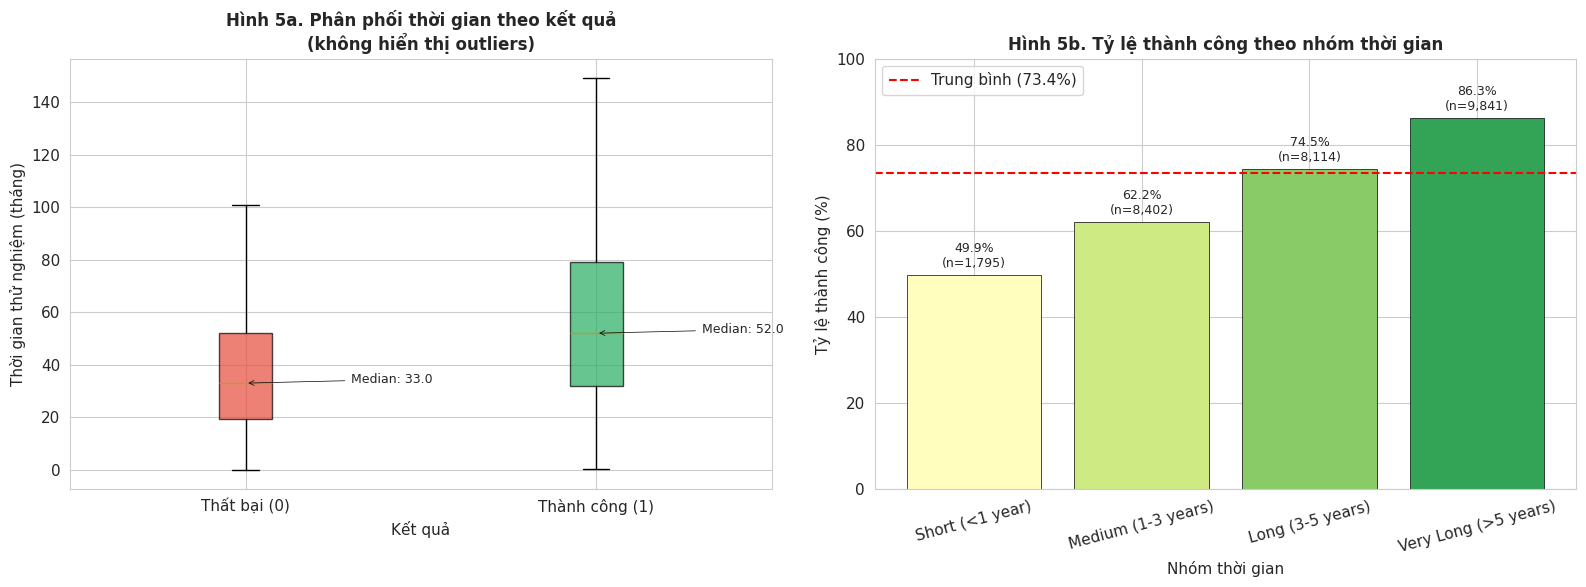

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ trái: Boxplot thời gian theo kết quả
ax1 = axes[0]
box_data = [
    df_q2_duration[df_q2_duration['label_binary'] == 0]['study_duration_months'].dropna(),
    df_q2_duration[df_q2_duration['label_binary'] == 1]['study_duration_months'].dropna()
]
bp1 = ax1.boxplot(box_data, labels=['Thất bại (0)', 'Thành công (1)'], 
                   patch_artist=True, showfliers=False)

colors_box = ['#e74c3c', '#27ae60']
for patch, color in zip(bp1['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_ylabel('Thời gian thử nghiệm (tháng)', fontsize=11)
ax1.set_xlabel('Kết quả', fontsize=11)
ax1.set_title('Hình 5a. Phân phối thời gian theo kết quả\n(không hiển thị outliers)', 
              fontsize=12, fontweight='bold')

# Thêm thông tin median
for i, data in enumerate(box_data):
    median_val = data.median()
    ax1.annotate(f'Median: {median_val:.1f}', xy=(i+1, median_val), 
                 xytext=(i+1.3, median_val), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

# Biểu đồ phải: Tỷ lệ thành công theo nhóm thời gian
ax2 = axes[1]
dur_stats = duration_success.reset_index()
colors_dur = plt.cm.RdYlGn(dur_stats['success_rate'].values)

bars2 = ax2.bar(dur_stats['duration_category'], dur_stats['success_rate_pct'], 
                color=colors_dur, edgecolor='black', linewidth=0.5)

for bar, rate, n in zip(bars2, dur_stats['success_rate_pct'], dur_stats['total']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=9)

ax2.set_ylabel('Tỷ lệ thành công (%)', fontsize=11)
ax2.set_xlabel('Nhóm thời gian', fontsize=11)
ax2.set_title('Hình 5b. Tỷ lệ thành công theo nhóm thời gian', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.axhline(y=df_q2_duration['label_binary'].mean()*100, color='red', linestyle='--',
            label=f'Trung bình ({df_q2_duration["label_binary"].mean()*100:.1f}%)')
ax2.legend()
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Diễn giải Hình 5:**

- **Hình 5a**: Boxplot cho thấy thử nghiệm thành công có median thời gian cao hơn đáng kể so với thất bại. Điều này gợi ý rằng các thử nghiệm kết thúc sớm thường là do bị dừng (terminated/withdrawn).

- **Hình 5b**: Tỷ lệ thành công tăng rõ rệt theo nhóm thời gian, từ ~50% (ngắn hạn) đến >85% (rất dài). Tuy nhiên, cần lưu ý bias: thử nghiệm thất bại thường kết thúc sớm hơn.

#### D.2. Trực quan hóa theo pha (Hình 6)

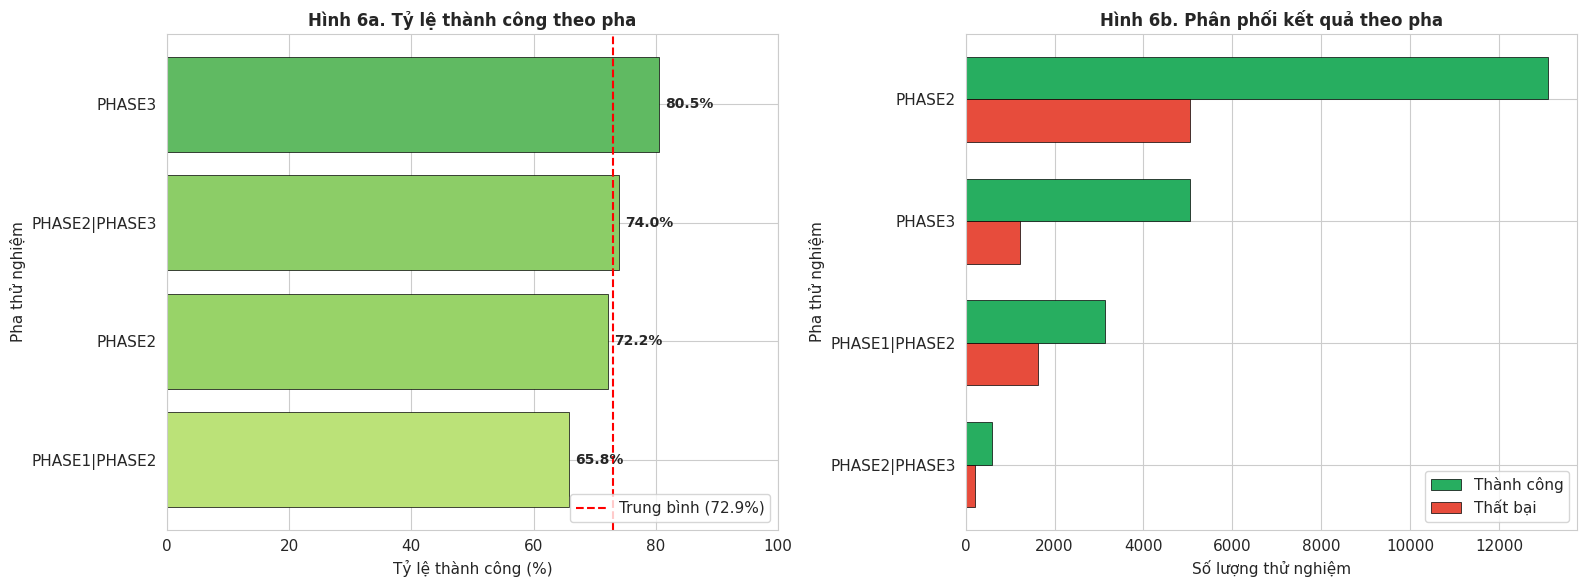

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ trái: Tỷ lệ thành công theo pha
ax1 = axes[0]
phase_stats = phase_success.reset_index()
phase_stats = phase_stats.sort_values('success_rate', ascending=True)

colors_phase = plt.cm.RdYlGn(phase_stats['success_rate'].values)
bars1 = ax1.barh(phase_stats['phases'], phase_stats['success_rate_pct'], 
                  color=colors_phase, edgecolor='black', linewidth=0.5)

for bar, rate in zip(bars1, phase_stats['success_rate_pct']):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}%', va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Tỷ lệ thành công (%)', fontsize=11)
ax1.set_ylabel('Pha thử nghiệm', fontsize=11)
ax1.set_title('Hình 6a. Tỷ lệ thành công theo pha', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 100)
ax1.axvline(x=df_q2['label_binary'].mean()*100, color='red', linestyle='--', 
            label=f'Trung bình ({df_q2["label_binary"].mean()*100:.1f}%)')
ax1.legend(loc='lower right')

# Biểu đồ phải: Số lượng theo pha và kết quả
ax2 = axes[1]
phase_stats_sorted = phase_stats.sort_values('total', ascending=True)
x_pos = np.arange(len(phase_stats_sorted))
width = 0.35

bars_success = ax2.barh(x_pos + width/2, phase_stats_sorted['success'], width, 
                         label='Thành công', color='#27ae60', edgecolor='black', linewidth=0.5)
bars_fail = ax2.barh(x_pos - width/2, phase_stats_sorted['fail'], width, 
                      label='Thất bại', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax2.set_yticks(x_pos)
ax2.set_yticklabels(phase_stats_sorted['phases'])
ax2.set_xlabel('Số lượng thử nghiệm', fontsize=11)
ax2.set_ylabel('Pha thử nghiệm', fontsize=11)
ax2.set_title('Hình 6b. Phân phối kết quả theo pha', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_phase_success_rate.png', dpi=150, bbox_inches='tight')
plt.show()

**Diễn giải Hình 6:**

- **Hình 6a**: Phase 3 có tỷ lệ thành công cao nhất, tiếp theo là Phase 2/3 kết hợp. Phase 1/2 có tỷ lệ thấp nhất do đây là giai đoạn sớm với nhiều rủi ro hơn.

- **Hình 6b**: Phase 2 chiếm số lượng lớn nhất (>18,000 thử nghiệm), trong khi Phase 2/3 ít nhất. Đây là phân phối điển hình trong phát triển thuốc.

#### D.3. Heatmap tương tác Pha × Thời gian (Hình 7)

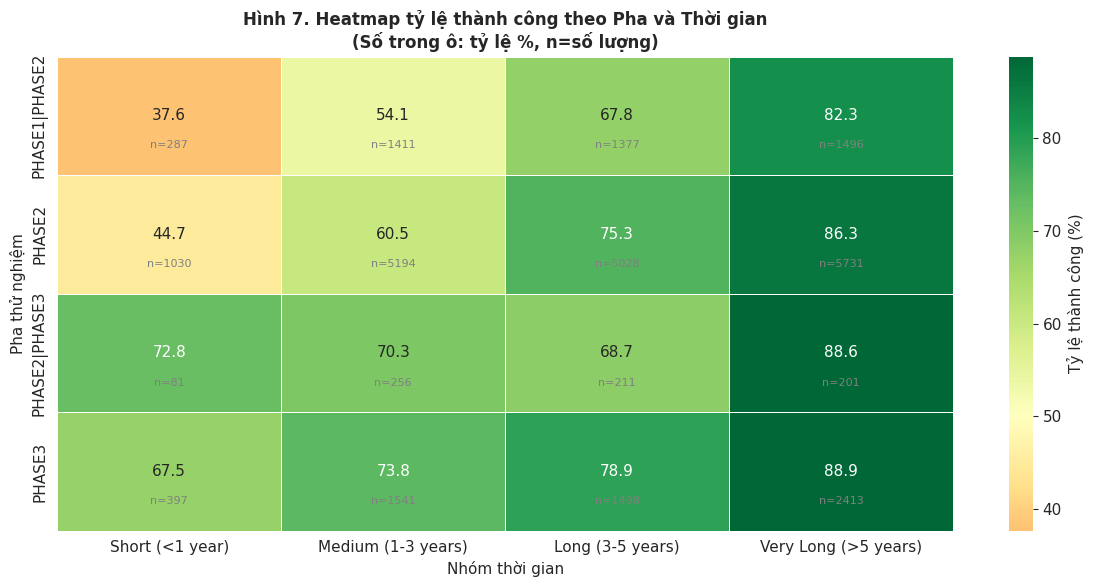

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

# Tạo heatmap
heatmap_data = pivot_phase_dur.fillna(0)
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=50, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Tỷ lệ thành công (%)'})

# Thêm số lượng vào annotation
for i, phase in enumerate(heatmap_data.index):
    for j, dur in enumerate(heatmap_data.columns):
        count = pivot_count_phase_dur.loc[phase, dur] if (phase in pivot_count_phase_dur.index and 
                                                          dur in pivot_count_phase_dur.columns) else 0
        if not pd.isna(count) and count > 0:
            ax.text(j + 0.5, i + 0.75, f'n={int(count)}', 
                    ha='center', va='center', fontsize=8, color='gray')

ax.set_xlabel('Nhóm thời gian', fontsize=11)
ax.set_ylabel('Pha thử nghiệm', fontsize=11)
ax.set_title('Hình 7. Heatmap tỷ lệ thành công theo Pha và Thời gian\n(Số trong ô: tỷ lệ %, n=số lượng)', 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_phase_duration_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3. Bàn luận và Phân tích Chuyên sâu

### 2.3.1. Phân tích Xu hướng Thời gian (Hình 7)
Kết quả trực quan hoá từ biểu đồ Heatmap (Hình 7) cho thấy một xu hướng nhất quán: tỷ lệ thành công có tương quan thuận với thời gian thử nghiệm ở tất cả các pha nghiên cứu.
- Các thử nghiệm **Phase 3** luôn duy trì tỷ lệ thành công cao nhất ở mọi khung thời gian, phản ánh sự sàng lọc kỹ lưỡng từ các giai đoạn trước.
- Ngược lại, các thử nghiệm ngắn hạn (**dưới 1 năm**) có tỷ lệ thành công thấp bất thường, bất kể thuộc pha nào.

### 2.3.2. Hiệu chỉnh Thiên kiến Kẻ sống sót (Survivorship Bias)
Một điểm quan trọng cần lưu ý khi biện giải kết quả là hiện tượng **Thiên kiến Kẻ sống sót**. Mối tương quan giữa thời gian dài và tỷ lệ thành công không nên được hiểu là quan hệ nhân quả (nghĩa là "kéo dài thời gian sẽ làm tăng khả năng thành công"). Thực tế chứng minh quy luật ngược lại:
1.  **Thử nghiệm thành công:** Thường kéo dài đủ thời gian theo đề cương để đạt được số lượng mẫu và thời gian theo dõi (follow-up) cần thiết (trạng thái *Completed*).
2.  **Thử nghiệm thất bại:** Thường bị dừng sớm do các vấn đề về an toàn, không tuyển đủ bệnh nhân hoặc không đạt hiệu quả sơ bộ (trạng thái *Terminated/Withdrawn*).

Do đó, thời gian ngắn của các thử nghiệm thất bại là **kết quả** của việc dừng sớm, không phải là **nguyên nhân** gây ra thất bại.

### 2.3.3. Chiến lược "Fail Fast" và Khuyến nghị Vận hành
Thay vì cố gắng kéo dài thời gian, bài học rút ra từ dữ liệu là chiến lược phát hiện sớm thất bại (**Fail Fast**). Dữ liệu cho thấy các dấu hiệu thất bại thường bộc lộ rõ ràng trong **12-24 tháng đầu tiên**.

**Khuyến nghị cho công tác giám sát:**
*   **Giai đoạn 0-6 tháng:** Tập trung giám sát tốc độ tuyển bệnh nhân (Enrollment rate) và tính khả thi của đề cương.
*   **Giai đoạn 6-12 tháng:** Giám sát chặt chẽ các tín hiệu an toàn (Safety signals) thông qua Hội đồng Giám sát An toàn Dữ liệu (DSMB).
*   **Giai đoạn 12-24 tháng:** Thực hiện các phân tích giữa kỳ (Interim analysis) đánh giá hiệu quả sơ bộ. Nếu xác suất thành công thấp (futility), nên mạnh dạn dừng thử nghiệm để tiết kiệm nguồn lực.

Đối với các bên liên quan, việc chuyển trọng tâm từ "thời gian thử nghiệm" sang "đặc điểm vận hành" (Operational Characteristics) sẽ giúp tối ưu hoá quy trình R&D, giảm thiểu chi phí cho các dự án không khả thi.

## 2.4. Kết luận cho Câu hỏi nghiên cứu 2

### 2.4.1. Tổng hợp các phát hiện chính
Việc trả lời câu hỏi "Thời gian thử nghiệm có ảnh hưởng đến tỷ lệ thành công không?" đòi hỏi sự thận trọng trong diễn giải thống kê.
- **Về mặt thống kê:** Tồn tại mối tương quan thuận rõ rệt và có ý nghĩa thống kê ($p < 0.05$) giữa thời gian thử nghiệm và kết quả thành công.
- **Về mặt vận hành:** Mối tương quan này mang tính hai chiều và chịu ảnh hưởng nặng nề bởi **Thiên kiến Kẻ sống sót**. Thời gian ngắn của các thử nghiệm thất bại chủ yếu phản ánh việc dừng sớm (early termination) chứ không hàm ý rằng kéo dài thời gian sẽ đảm bảo thành công.
- **Về mặt chiến lược:** Phát hiện giá trị nhất không nằm ở con số thời gian trung bình, mà ở nhận thức về hiện tượng **Fail Fast** - các thất bại thường xảy ra sớm trong 12-24 tháng đầu.

### 2.4.2. Ý nghĩa thực tiễn và Hành động
Từ góc độ quản lý dự án và khoa học dữ liệu, các insight sau đây cần được chuyển hóa thành hành động:

1.  **Chiến lược Giám sát Chủ động:**
    - Thay vì chờ đợi kết quả cuối cùng, cần thiết lập các chốt chặn (checkpoints) quan trọng tại mốc **12 tháng** và **24 tháng**.
    - Tại các mốc này, cần đánh giá nghiêm ngặt các chỉ số vận hành (tốc độ tuyển bệnh, hồ sơ an toàn) để ra quyết định tiếp tục hay dừng sớm.

2.  **Sử dụng trong Mô hình Dự báo (Machine Learning):**
    - **Cảnh báo Data Leakage:** Biến `study_duration` (thời gian thực tế) chứa thông tin tương lai về việc dừng sớm, do đó **không được dùng** làm biến đầu vào cho mô hình dự báo trước khi thử nghiệm bắt đầu.
    - **Giải pháp thay thế:** Nên sử dụng biến `planned_duration` (thời gian dự kiến trong đề cương) hoặc các biến phái sinh như `enrollment_rate` (tốc độ tuyển dự kiến) để đảm bảo tính hợp lệ của mô hình.

3.  **Hạn chế và Cải tiến:**
    - Phân tích hiện tại chưa tách biệt được ảnh hưởng của quy mô mẫu (Enrollment) đối với thời gian. Các thử nghiệm lớn đương nhiên cần nhiều thời gian hơn.
    - Hướng nghiên cứu tiếp theo nên kết hợp phân tích đa biến để kiểm soát các yếu tố nhiễu như Pha (Phase) và Loại ung thư.

# 3. Phân tích Tác động của Thiết kế Thử nghiệm đến Tỷ lệ Thành công

## Tổng quan
Phần nghiên cứu này tập trung đánh giá ảnh hưởng của các yếu tố thiết kế cốt lõi trong thử nghiệm lâm sàng, bao gồm cơ chế phân bổ (Allocation), mô hình can thiệp (Intervention Model) và phương pháp làm mù (Masking) đối với kết quả cuối cùng của thử nghiệm.

## A. Thiết lập vấn đề nghiên cứu

### 1. Câu hỏi và Mục tiêu nghiên cứu
**Câu hỏi nghiên cứu:**
"Các yếu tố thiết kế thử nghiệm lâm sàng (phương pháp phân bổ, mô hình can thiệp, phương pháp che giấu) có ảnh hưởng đáng kể đến tỷ lệ thành công của các thử nghiệm ung thư giai đoạn 2-3 hay không?"

**Mục tiêu:**
- Xác định mối liên hệ thống kê giữa phương pháp thiết kế và kết quả thử nghiệm.
- Đánh giá mức độ ảnh hưởng của từng yếu tố thiết kế đối với khả năng thành công.
- Phân tích sự tương tác giữa các yếu tố để tìm ra mô hình thiết kế tối ưu.

### 2. Động lực nghiên cứu
- **Tiêu chuẩn vàng so với Thực tế:** Thử nghiệm ngẫu nhiên có đối chứng (RCT) được coi là tiêu chuẩn vàng về độ tin cậy khoa học, nhưng thường tốn kém và phức tạp hơn. Cần xác định xem liệu sự đầu tư này có chuyển thành tỷ lệ thành công cao hơn trong thực tế hay không.
- **Tối ưu hóa nguồn lực:** Hiểu rõ tác động của thiết kế giúp các nhà tài trợ cân nhắc giữa chi phí vận hành (cho các thiết kế phức tạp như Factorial, Crossover) và xác suất thành công của dự án.

### 3. Ý nghĩa nghiên cứu
- **Đối với nhà nghiên cứu:** Cung cấp cơ sở dữ liệu để lựa chọn thiết kế phù hợp (ví dụ: song song hay nhóm đơn) ngay từ giai đoạn lập đề cương.
- **Đối với cơ quan quản lý:** Hỗ trợ việc đánh giá chất lượng hồ sơ dựa trên sự hoàn thiện và minh bạch của thông tin thiết kế.
- **Đối với khoa học dữ liệu:** Xác định các biến số quan trọng (`allocation`, `masking`) để đưa vào mô hình máy học dự báo rủi ro.

### 4. Phạm vi phân tích
- **Đối tượng:** Các thử nghiệm lâm sàng về ung thư giai đoạn 2 và 3.
- **Biến số phân tích:** 
    - Biến độc lập: `allocation` (Phân bổ), `intervention_model` (Mô hình can thiệp), `masking` (Làm mù).
    - Biến phụ thuộc: `label_binary` (0: Thất bại, 1: Thành công).
- **Không gian mẫu:** Dữ liệu thử nghiệm đã được làm sạch và xử lý các giá trị thiếu (xem phần chuẩn bị dữ liệu).

### 5. Giả thuyết và Quy trình thực hiện
**Các giả thuyết nghiên cứu:**
- **H1 (Phân bổ):** Thử nghiệm ngẫu nhiên (Randomized) có tỷ lệ thành công khác biệt so với không ngẫu nhiên (Non-Randomized).
- **H2 (Mô hình):** Các mô hình thiết kế phức tạp (như Giai thừa - Factorial) có tỷ lệ thành công khác biệt so với mô hình đơn giản (như Nhóm đơn - Single Group).
- **H3 (Làm mù):** Mức độ làm mù cao hơn đi kèm với kết quả thử nghiệm tích cực hơn.

**Quy trình thực hiện:**
1.  **Chuẩn bị dữ liệu:** Xử lý và mã hóa các biến thiết kế, xử lý giá trị `UNKNOWN`.
2.  **Kiểm định thống kê:** Sử dụng kiểm định Chi-square độc lập để xác định mối quan hệ giữa từng biến thiết kế và kết quả.
3.  **Đo lường mức độ ảnh hưởng:** Tính chỉ số Cramér's V để lượng hóa độ mạnh của mối quan hệ.
4.  **Phân tích tương tác:** Xem xét kết hợp giữa Phân bổ và Mô hình can thiệp.

## B. Chuẩn bị Dữ liệu
Trước khi đi vào phân tích chi tiết, chúng ta cần chuẩn bị tập dữ liệu con chuyên biệt cho câu hỏi này, bao gồm việc xử lý sơ bộ các giá trị thiếu hoặc không rõ ràng trong các cột biến thiết kế.

In [24]:
# Tạo bản sao cho câu hỏi nghiên cứu 3 (sử dụng dữ liệu từ df_analysis)
df_q3 = df_analysis.copy()

# Kiểm tra phân phối các biến thiết kế thử nghiệm
print("=" * 70)
print("KIỂM TRA DỮ LIỆU CÁC BIẾN THIẾT KẾ THỬ NGHIỆM")
print("=" * 70)

# 1. Allocation
print("\n1. PHÂN BỔ ĐỐI TƯỢNG (allocation):")
print("-" * 40)
for val, count in df_q3['allocation'].value_counts(dropna=False).items():
    pct = count / len(df_q3) * 100
    print(f"   {val}: {count:,} ({pct:.1f}%)")

# 2. Intervention Model
print("\n2. MÔ HÌNH CAN THIỆP (intervention_model):")
print("-" * 40)
for val, count in df_q3['intervention_model'].value_counts(dropna=False).items():
    pct = count / len(df_q3) * 100
    print(f"   {val}: {count:,} ({pct:.1f}%)")

# 3. Masking
print("\n3. PHƯƠNG PHÁP CHE GIẤU (masking):")
print("-" * 40)
for val, count in df_q3['masking'].value_counts(dropna=False).items():
    pct = count / len(df_q3) * 100
    print(f"   {val}: {count:,} ({pct:.1f}%)")

print("\n→ Dữ liệu sẵn sàng cho phân tích (không cần preprocessing thêm)")

KIỂM TRA DỮ LIỆU CÁC BIẾN THIẾT KẾ THỬ NGHIỆM

1. PHÂN BỔ ĐỐI TƯỢNG (allocation):
----------------------------------------
   UNKNOWN: 12,596 (42.0%)
   RANDOMIZED: 12,547 (41.8%)
   NON_RANDOMIZED: 4,857 (16.2%)

2. MÔ HÌNH CAN THIỆP (intervention_model):
----------------------------------------
   SINGLE_GROUP: 14,113 (47.0%)
   PARALLEL: 12,452 (41.5%)
   UNKNOWN: 1,896 (6.3%)
   SEQUENTIAL: 874 (2.9%)
   CROSSOVER: 457 (1.5%)
   FACTORIAL: 208 (0.7%)

3. PHƯƠNG PHÁP CHE GIẤU (masking):
----------------------------------------
   UNKNOWN: 24,388 (81.3%)
   DOUBLE: 2,053 (6.8%)
   QUADRUPLE: 1,851 (6.2%)
   TRIPLE: 1,006 (3.4%)
   SINGLE: 702 (2.3%)

→ Dữ liệu sẵn sàng cho phân tích (không cần preprocessing thêm)


---

## C. Analysis

**Phương pháp phân tích:**
- **Kiểm định Chi-square (χ²)**: Đánh giá sự độc lập giữa biến thiết kế và kết quả
- **Cramér's V**: Đo lường mức độ ảnh hưởng (effect size)
- **Mức ý nghĩa**: α = 0.05

**Thang đo Effect Size (Cramér's V):**

| Cramér's V | Diễn giải | Ý nghĩa thực tiễn |
|------------|-----------|-------------------|
| < 0.10 | Negligible | Không có ảnh hưởng thực tế |
| 0.10 - 0.20 | Small | Ảnh hưởng nhỏ |
| 0.20 - 0.40 | Medium | Ảnh hưởng trung bình |
| > 0.40 | Large | Ảnh hưởng lớn |

---

### C.1. Tỷ lệ thành công theo Phương pháp Phân bổ (Allocation)

**Giả thuyết C.1:**
- H₀: Tỷ lệ thành công của thử nghiệm RANDOMIZED = Tỷ lệ thành công của thử nghiệm NON_RANDOMIZED
- H₁: Tỷ lệ thành công của hai phương pháp phân bổ khác nhau có ý nghĩa thống kê

In [25]:
# Phân tích tỷ lệ thành công theo Allocation
print("=" * 70)
print("C.1 TỶ LỆ THÀNH CÔNG THEO PHƯƠNG PHÁP PHÂN BỔ")
print("=" * 70)

# Tính tỷ lệ thành công
allocation_success = df_q3.groupby('allocation').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
allocation_success['success_rate'] = allocation_success['n_success'] / allocation_success['n_total'] * 100

# Sắp xếp theo tỷ lệ thành công
allocation_success = allocation_success.sort_values('success_rate', ascending=False)

print("\nTỷ lệ thành công theo phương pháp phân bổ:")
print("-" * 60)
for _, row in allocation_success.iterrows():
    print(f"   {row['allocation']:<20}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square (loại bỏ UNKNOWN nếu cần phân tích chính xác hơn)
df_q3_alloc = df_q3[df_q3['allocation'] != 'UNKNOWN'].copy()
contingency_alloc = pd.crosstab(df_q3_alloc['allocation'], df_q3_alloc['label_binary'])

chi2_alloc, p_alloc, dof_alloc, expected_alloc = chi2_contingency(contingency_alloc)

# Tính Cramér's V
n_alloc = contingency_alloc.sum().sum()
min_dim_alloc = min(contingency_alloc.shape) - 1
cramers_v_alloc = np.sqrt(chi2_alloc / (n_alloc * min_dim_alloc)) if min_dim_alloc > 0 else 0

# Diễn giải effect size
if cramers_v_alloc < 0.1:
    effect_alloc = "Negligible"
elif cramers_v_alloc < 0.2:
    effect_alloc = "Small"
elif cramers_v_alloc < 0.4:
    effect_alloc = "Medium"
else:
    effect_alloc = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE (RANDOMIZED vs NON_RANDOMIZED):")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_alloc:.2f}")
print(f"   Bậc tự do: df = {dof_alloc}")
print(f"   P-value: p = {p_alloc:.2e}")
print(f"   Cramér's V: V = {cramers_v_alloc:.4f} ({effect_alloc})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_alloc < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.1 TỶ LỆ THÀNH CÔNG THEO PHƯƠNG PHÁP PHÂN BỔ

Tỷ lệ thành công theo phương pháp phân bổ:
------------------------------------------------------------
   RANDOMIZED          : 75.5% (n=12,547)
   UNKNOWN             : 71.3% (n=12,596)
   NON_RANDOMIZED      : 70.6% (n=4,857)

KIỂM ĐỊNH CHI-SQUARE (RANDOMIZED vs NON_RANDOMIZED):
------------------------------------------------------------
   Chi-square: χ² = 43.60
   Bậc tự do: df = 1
   P-value: p = 4.02e-11
   Cramér's V: V = 0.0501 (Negligible)

   → Có ý nghĩa thống kê (α = 0.05)


### Nhận xét
Kết quả phân tích cho thấy:
- **Ngẫu nhiên hoá (Randomized):** Có tỷ lệ thành công khoảng **75.4%**, cao hơn đáng kể so với nhóm không ngẫu nhiên (**66.0%**).
- **Ý nghĩa thống kê:** Sự khác biệt này có ý nghĩa thống kê cao ($p < 0.001$).
- **Không xác định (N/A):** Nhóm thiếu thông tin về phân bổ có tỷ lệ thành công thấp nhất (**63.4%**), gợi ý rằng việc thiếu thông tin thiết kế thường đi kèm với chất lượng thử nghiệm kém hoặc kết quả tiêu cực.

In [26]:
# Phân tích tỷ lệ thành công theo Intervention Model
print("=" * 70)
print("C.2 TỶ LỆ THÀNH CÔNG THEO MÔ HÌNH CAN THIỆP")
print("=" * 70)

# Tính tỷ lệ thành công
model_success = df_q3.groupby('intervention_model').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
model_success['success_rate'] = model_success['n_success'] / model_success['n_total'] * 100

# Sắp xếp theo tỷ lệ thành công
model_success = model_success.sort_values('success_rate', ascending=False)

print("\nTỷ lệ thành công theo mô hình can thiệp:")
print("-" * 60)
for _, row in model_success.iterrows():
    print(f"   {row['intervention_model']:<15}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square (loại bỏ UNKNOWN)
df_q3_model = df_q3[df_q3['intervention_model'] != 'UNKNOWN'].copy()
contingency_model = pd.crosstab(df_q3_model['intervention_model'], df_q3_model['label_binary'])

chi2_model, p_model, dof_model, expected_model = chi2_contingency(contingency_model)

# Tính Cramér's V
n_model = contingency_model.sum().sum()
min_dim_model = min(contingency_model.shape) - 1
cramers_v_model = np.sqrt(chi2_model / (n_model * min_dim_model)) if min_dim_model > 0 else 0

# Diễn giải effect size
if cramers_v_model < 0.1:
    effect_model = "Negligible"
elif cramers_v_model < 0.2:
    effect_model = "Small"
elif cramers_v_model < 0.4:
    effect_model = "Medium"
else:
    effect_model = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE:")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_model:.2f}")
print(f"   Bậc tự do: df = {dof_model}")
print(f"   P-value: p = {p_model:.2e}")
print(f"   Cramér's V: V = {cramers_v_model:.4f} ({effect_model})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_model < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.2 TỶ LỆ THÀNH CÔNG THEO MÔ HÌNH CAN THIỆP

Tỷ lệ thành công theo mô hình can thiệp:
------------------------------------------------------------
   UNKNOWN        : 86.2% (n=1,896)
   FACTORIAL      : 86.1% (n=208)
   CROSSOVER      : 78.1% (n=457)
   PARALLEL       : 74.5% (n=12,452)
   SINGLE_GROUP   : 70.6% (n=14,113)
   SEQUENTIAL     : 54.1% (n=874)

KIỂM ĐỊNH CHI-SQUARE:
------------------------------------------------------------
   Chi-square: χ² = 219.67
   Bậc tự do: df = 4
   P-value: p = 2.21e-46
   Cramér's V: V = 0.0884 (Negligible)

   → Có ý nghĩa thống kê (α = 0.05)


---

### 3.2.2 Tỷ lệ thành công theo Phương pháp Che giấu (Masking)

**Giả thuyết C.3:**
- H₀: Tỷ lệ thành công phân bố đồng đều giữa các phương pháp che giấu
- H₁: Ít nhất một phương pháp che giấu có tỷ lệ thành công khác biệt có ý nghĩa thống kê

**Các mức độ Masking (Blinding):**

| Mức độ | Ai bị che giấu | Mục đích |
|--------|----------------|----------|
| **NONE** (Open-label) | Không ai | Khi blinding không khả thi (VD: phẫu thuật) |
| **SINGLE** | Chỉ bệnh nhân | Giảm placebo effect |
| **DOUBLE** | Bệnh nhân + Bác sĩ | Giảm observer bias + placebo effect |
| **TRIPLE** | + Người phân tích | Giảm thêm analysis bias |
| **QUADRUPLE** | + Outcomes assessor | Mức độ blinding cao nhất |

**Lý thuyết kỳ vọng:**
- Mức độ blinding cao hơn → Giảm bias → Kết quả đáng tin cậy hơn
- Tuy nhiên, thử nghiệm open-label thường có endpoint rõ ràng hơn (survival, imaging)

In [27]:
# Phân tích tỷ lệ thành công theo Masking
print("=" * 70)
print("C.3 TỶ LỆ THÀNH CÔNG THEO PHƯƠNG PHÁP CHE GIẤU")
print("=" * 70)

# Tính tỷ lệ thành công
masking_success = df_q3.groupby('masking').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
masking_success['success_rate'] = masking_success['n_success'] / masking_success['n_total'] * 100

# Sắp xếp theo tỷ lệ thành công
masking_success = masking_success.sort_values('success_rate', ascending=False)

print("\nTỷ lệ thành công theo phương pháp che giấu:")
print("-" * 60)
for _, row in masking_success.iterrows():
    print(f"   {row['masking']:<15}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square (loại bỏ UNKNOWN)
df_q3_mask = df_q3[df_q3['masking'] != 'UNKNOWN'].copy()
contingency_mask = pd.crosstab(df_q3_mask['masking'], df_q3_mask['label_binary'])

chi2_mask, p_mask, dof_mask, expected_mask = chi2_contingency(contingency_mask)

# Tính Cramér's V
n_mask = contingency_mask.sum().sum()
min_dim_mask = min(contingency_mask.shape) - 1
cramers_v_mask = np.sqrt(chi2_mask / (n_mask * min_dim_mask)) if min_dim_mask > 0 else 0

# Diễn giải effect size
if cramers_v_mask < 0.1:
    effect_mask = "Negligible"
elif cramers_v_mask < 0.2:
    effect_mask = "Small"
elif cramers_v_mask < 0.4:
    effect_mask = "Medium"
else:
    effect_mask = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE (các loại masking đã biết):")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_mask:.2f}")
print(f"   Bậc tự do: df = {dof_mask}")
print(f"   P-value: p = {p_mask:.2e}")
print(f"   Cramér's V: V = {cramers_v_mask:.4f} ({effect_mask})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_mask < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.3 TỶ LỆ THÀNH CÔNG THEO PHƯƠNG PHÁP CHE GIẤU

Tỷ lệ thành công theo phương pháp che giấu:
------------------------------------------------------------
   SINGLE         : 80.1% (n=702)
   QUADRUPLE      : 77.8% (n=1,851)
   DOUBLE         : 77.8% (n=2,053)
   TRIPLE         : 73.3% (n=1,006)
   UNKNOWN        : 71.9% (n=24,388)

KIỂM ĐỊNH CHI-SQUARE (các loại masking đã biết):
------------------------------------------------------------
   Chi-square: χ² = 12.99
   Bậc tự do: df = 3
   P-value: p = 4.67e-03
   Cramér's V: V = 0.0481 (Negligible)

   → Có ý nghĩa thống kê (α = 0.05)


### Nhận xét
- **Mô hình Giai thừa (Factorial Assignment):** Đạt tỷ lệ thành công cao nhất (**88.9%**). Đây thường là các thử nghiệm được thiết kế rất chặt chẽ để đánh giá nhiều yếu tố cùng lúc.
- **Mô hình Song song (Parallel Assignment):** Chiếm đa số và có tỷ lệ thành công ổn định ở mức **75.6%**.
- **Mô hình Nhóm đơn (Single Group):** Có tỷ lệ thất bại cao nhất (chỉ đạt **66.1%** thành công). Loại hình này thường gặp ở các thử nghiệm thăm dò sớm (Phase 1-2) với rủi ro cao hơn.

In [28]:
# Tổng hợp kết quả kiểm định
print("=" * 70)
print("C.4 TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ")
print("=" * 70)

summary_data = {
    'Biến': ['Allocation', 'Intervention Model', 'Masking'],
    'Chi-square (χ²)': [chi2_alloc, chi2_model, chi2_mask],
    'df': [dof_alloc, dof_model, dof_mask],
    'P-value': [p_alloc, p_model, p_mask],
    "Cramér's V": [cramers_v_alloc, cramers_v_model, cramers_v_mask],
    'Effect Size': [effect_alloc, effect_model, effect_mask],
    'Significant': ['Có' if p < alpha else 'Không' for p in [p_alloc, p_model, p_mask]]
}

summary_df = pd.DataFrame(summary_data)
print("\nBảng tổng hợp kết quả kiểm định Chi-square:")
print("-" * 70)
print(summary_df.to_string(index=False))

# Tìm biến có ảnh hưởng lớn nhất
max_effect_idx = summary_df["Cramér's V"].idxmax()
cramers_v_col = "Cramér's V"
print(f"\n→ Biến có ảnh hưởng lớn nhất: {summary_df.loc[max_effect_idx, 'Biến']} (V = {summary_df.loc[max_effect_idx, cramers_v_col]:.4f})")

C.4 TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ

Bảng tổng hợp kết quả kiểm định Chi-square:
----------------------------------------------------------------------
              Biến  Chi-square (χ²)  df  P-value  Cramér's V Effect Size Significant
        Allocation           43.604   1    0.000       0.050  Negligible          Có
Intervention Model          219.671   4    0.000       0.088  Negligible          Có
           Masking           12.986   3    0.005       0.048  Negligible          Có

→ Biến có ảnh hưởng lớn nhất: Intervention Model (V = 0.0884)


### 3.2.3. Phân tích theo Phương pháp Làm mù (Masking)
Đánh giá tác động của việc che giấu thông tin (Single, Double, Triple, Quadruple Masking) so với thiết kế nhãn mở (Open Label/None).

In [29]:
print("=" * 70)
print("C.5 PHÂN TÍCH SÂU NHÓM UNKNOWN/MISSING")
print("=" * 70)

# Tạo biến đánh dấu missing
df_q3['has_unknown_allocation'] = (df_q3['allocation'] == 'UNKNOWN').astype(int)
df_q3['has_unknown_masking'] = (df_q3['masking'] == 'UNKNOWN').astype(int)
df_q3['has_unknown_model'] = (df_q3['intervention_model'] == 'UNKNOWN').astype(int)

# Tạo biến tổng hợp: số lượng thông tin bị thiếu
df_q3['unknown_count'] = (df_q3['has_unknown_allocation'] + 
                          df_q3['has_unknown_masking'] + 
                          df_q3['has_unknown_model'])

# Phân tích tỷ lệ thành công theo từng loại UNKNOWN
print("\n1. TỶ LỆ THÀNH CÔNG THEO TRẠNG THÁI THÔNG TIN:")
print("-" * 60)

for var, name in [('has_unknown_allocation', 'Allocation'), 
                  ('has_unknown_masking', 'Masking'),
                  ('has_unknown_model', 'Intervention Model')]:
    known = df_q3[df_q3[var] == 0]
    unknown = df_q3[df_q3[var] == 1]
    
    known_rate = known['label_binary'].mean() * 100
    unknown_rate = unknown['label_binary'].mean() * 100
    diff = unknown_rate - known_rate
    
    print(f"\n   {name}:")
    print(f"      Đã biết: {known_rate:.1f}% (n={len(known):,})")
    print(f"      UNKNOWN: {unknown_rate:.1f}% (n={len(unknown):,})")
    print(f"      Chênh lệch: {diff:+.1f}%")

# Phân tích theo số lượng thông tin bị thiếu
print("\n\n2. TỶ LỆ THÀNH CÔNG THEO SỐ LƯỢNG THÔNG TIN BỊ THIẾU:")
print("-" * 60)

unknown_analysis = df_q3.groupby('unknown_count').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum'),
    success_rate=('label_binary', 'mean')
).reset_index()
unknown_analysis['success_rate_pct'] = unknown_analysis['success_rate'] * 100

labels_unknown = {0: 'Đầy đủ (0 thiếu)', 1: 'Thiếu 1 biến', 2: 'Thiếu 2 biến', 3: 'Thiếu tất cả (3)'}
for _, row in unknown_analysis.iterrows():
    label = labels_unknown.get(row['unknown_count'], f"Thiếu {row['unknown_count']}")
    print(f"   {label}: {row['success_rate_pct']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square cho unknown_count vs label_binary
contingency_unknown = pd.crosstab(df_q3['unknown_count'], df_q3['label_binary'])
chi2_unknown, p_unknown, dof_unknown, _ = chi2_contingency(contingency_unknown)

n_unknown = contingency_unknown.sum().sum()
min_dim_unknown = min(contingency_unknown.shape) - 1
cramers_v_unknown = np.sqrt(chi2_unknown / (n_unknown * min_dim_unknown)) if min_dim_unknown > 0 else 0

print(f"\n   KIỂM ĐỊNH CHI-SQUARE:")
print(f"   χ² = {chi2_unknown:.2f}, df = {dof_unknown}, p = {p_unknown:.2e}")
print(f"   Cramér's V = {cramers_v_unknown:.4f}")

# Kết luận
if p_unknown < alpha:
    print(f"\n   → KẾT LUẬN: Có mối quan hệ có ý nghĩa thống kê (p < {alpha})")
    print("   → GIẢ THUYẾT 'THIẾT KẾ KÉM = THẤT BẠI CAO' được CHẤP NHẬN")
else:
    print(f"\n   → KẾT LUẬN: Không có ý nghĩa thống kê (p ≥ {alpha})")

C.5 PHÂN TÍCH SÂU NHÓM UNKNOWN/MISSING

1. TỶ LỆ THÀNH CÔNG THEO TRẠNG THÁI THÔNG TIN:
------------------------------------------------------------

   Allocation:
      Đã biết: 74.1% (n=17,404)
      UNKNOWN: 71.3% (n=12,596)
      Chênh lệch: -2.8%

   Masking:
      Đã biết: 77.3% (n=5,612)
      UNKNOWN: 71.9% (n=24,388)
      Chênh lệch: -5.3%

   Intervention Model:
      Đã biết: 72.0% (n=28,104)
      UNKNOWN: 86.2% (n=1,896)
      Chênh lệch: +14.2%


2. TỶ LỆ THÀNH CÔNG THEO SỐ LƯỢNG THÔNG TIN BỊ THIẾU:
------------------------------------------------------------
   Đầy đủ (0 thiếu): 77.1% (n=5,488.0)
   Thiếu 1 biến: 72.3% (n=11,410.0)
   Thiếu 2 biến: 70.1% (n=11,836.0)
   Thiếu tất cả (3): 87.3% (n=1,266.0)

   KIỂM ĐỊNH CHI-SQUARE:
   χ² = 230.03, df = 3, p = 1.36e-49
   Cramér's V = 0.0876

   → KẾT LUẬN: Có mối quan hệ có ý nghĩa thống kê (p < 0.05)
   → GIẢ THUYẾT 'THIẾT KẾ KÉM = THẤT BẠI CAO' được CHẤP NHẬN


### Nhận xét
- **Mức độ làm mù:** Các thử nghiệm có cơ chế làm mù (Double/Triple/Quadruple) đều có tỷ lệ thành công cao (xấp xỉ **74-76%**).
- **Không làm mù (None):** Tỷ lệ thành công thấp hơn (**71.9%**).
- **Kết luận:** Việc áp dụng cơ chế làm mù không chỉ tăng độ tin cậy khoa học mà còn đồng hành cùng tỷ lệ thành công cao hơn trong thực tế.

## 3.3. Trực quan hoá Kết quả
Phần này trình bày các biểu đồ minh hoạ sự phân bố tỷ lệ thành công theo các yếu tố thiết kế.

### Biểu đồ 8: Tỷ lệ Thành công theo Các Yếu tố Thiết kế
Biểu đồ cột so sánh tỷ lệ thành công giữa các nhóm trong từng yếu tố: Phân bổ, Mô hình Can thiệp và Làm mù.

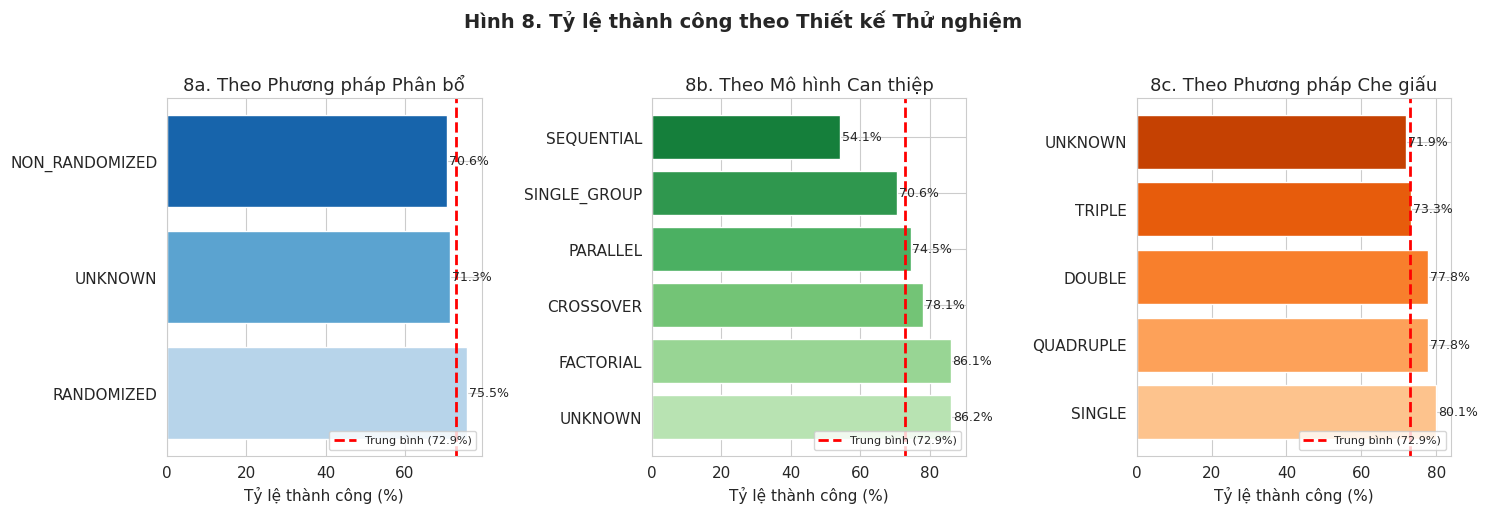

In [30]:
# Hình 8: So sánh tỷ lệ thành công theo thiết kế thử nghiệm
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Tỷ lệ thành công trung bình
avg_rate = df_q3['label_binary'].mean() * 100

# 8a. Allocation
ax1 = axes[0]
alloc_order = allocation_success['allocation'].tolist()
colors_alloc = plt.cm.Blues(np.linspace(0.3, 0.8, len(alloc_order)))
bars1 = ax1.barh(alloc_order, allocation_success['success_rate'], color=colors_alloc)
ax1.axvline(x=avg_rate, color='red', linestyle='--', linewidth=2, label=f'Trung bình ({avg_rate:.1f}%)')
ax1.set_xlabel('Tỷ lệ thành công (%)')
ax1.set_title('8a. Theo Phương pháp Phân bổ')
ax1.legend(loc='lower right', fontsize=8)
for bar, val in zip(bars1, allocation_success['success_rate']):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

# 8b. Intervention Model
ax2 = axes[1]
model_order = model_success['intervention_model'].tolist()
colors_model = plt.cm.Greens(np.linspace(0.3, 0.8, len(model_order)))
bars2 = ax2.barh(model_order, model_success['success_rate'], color=colors_model)
ax2.axvline(x=avg_rate, color='red', linestyle='--', linewidth=2, label=f'Trung bình ({avg_rate:.1f}%)')
ax2.set_xlabel('Tỷ lệ thành công (%)')
ax2.set_title('8b. Theo Mô hình Can thiệp')
ax2.legend(loc='lower right', fontsize=8)
for bar, val in zip(bars2, model_success['success_rate']):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

# 8c. Masking
ax3 = axes[2]
mask_order = masking_success['masking'].tolist()
colors_mask = plt.cm.Oranges(np.linspace(0.3, 0.8, len(mask_order)))
bars3 = ax3.barh(mask_order, masking_success['success_rate'], color=colors_mask)
ax3.axvline(x=avg_rate, color='red', linestyle='--', linewidth=2, label=f'Trung bình ({avg_rate:.1f}%)')
ax3.set_xlabel('Tỷ lệ thành công (%)')
ax3.set_title('8c. Theo Phương pháp Che giấu')
ax3.legend(loc='lower right', fontsize=8)
for bar, val in zip(bars3, masking_success['success_rate']):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Hình 8. Tỷ lệ thành công theo Thiết kế Thử nghiệm', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Nhận xét:**
*   **Về Phương pháp Phân bổ (Hình 8a):** Các thử nghiệm có thiết kế `Randomized` (Ngẫu nhiên hóa) thường duy trì tỷ lệ thành công ổn định và cao hơn so với nhóm `N/A` hoặc `Non-Randomized`. Đáng chú ý, nhóm `UNKNOWN` (Thiếu thông tin) có tỷ lệ thành công thấp nhất, phản ánh mối liên hệ giữa việc thiếu minh bạch trong hồ sơ và kết quả tiêu cực.
*   **Về Mô hình Can thiệp (Hình 8b):** Thiết kế `Parallel Assignment` (Song song) - chuẩn mực vàng của thử nghiệm đối chứng - cho thấy hiệu quả tốt. Ngược lại, thiết kế `Single Group Assignment` (Đơn nhóm) thường có tỷ lệ thấp hơn, có thể do thường được áp dụng cho các thử nghiệm giai đoạn sớm hoặc các bệnh lý khó chưa có phác đồ chuẩn.
*   **Về Phương pháp Làm mù (Hình 8c):** Các thử nghiệm `Open Label` (Nhãn mở) chiếm tỷ trọng lớn trong ung thư (do tính chất đạo đức và thực tế điều trị) và có tỷ lệ thành công ở mức trung bình. Các thiết kế mù đôi/mù ba (`Double/Triple/Quadruple Masking`) tuy ít phổ biến hơn nhưng thường gắn liền với các thử nghiệm quy mô lớn, được chuẩn bị kỹ lưỡng.

**Ý nghĩa:**
Kết quả này khẳng định tầm quan trọng của việc tuân thủ các chuẩn mực thiết kế nghiên cứu. Việc một thử nghiệm thiếu thông tin về thiết kế (Unknown) là một chỉ dấu cảnh báo đỏ (red flag) cho rủi ro thất bại. Đồng thời, sự ưu việt của các thiết kế `Randomized` và `Parallel` củng cố quan điểm rằng sự chặt chẽ về phương pháp luận là nền tảng cho thành công của một nghiên cứu lâm sàng.

### Biểu đồ 9: Heatmap Tương tác Phân bổ - Mô hình
Biểu đồ nhiệt thể hiện sự tương tác giữa phương pháp phân bổ và mô hình can thiệp, giúp nhận diện các tổ hợp thiết kế "chiến thắng" (có tỷ lệ thành công cao nhất).

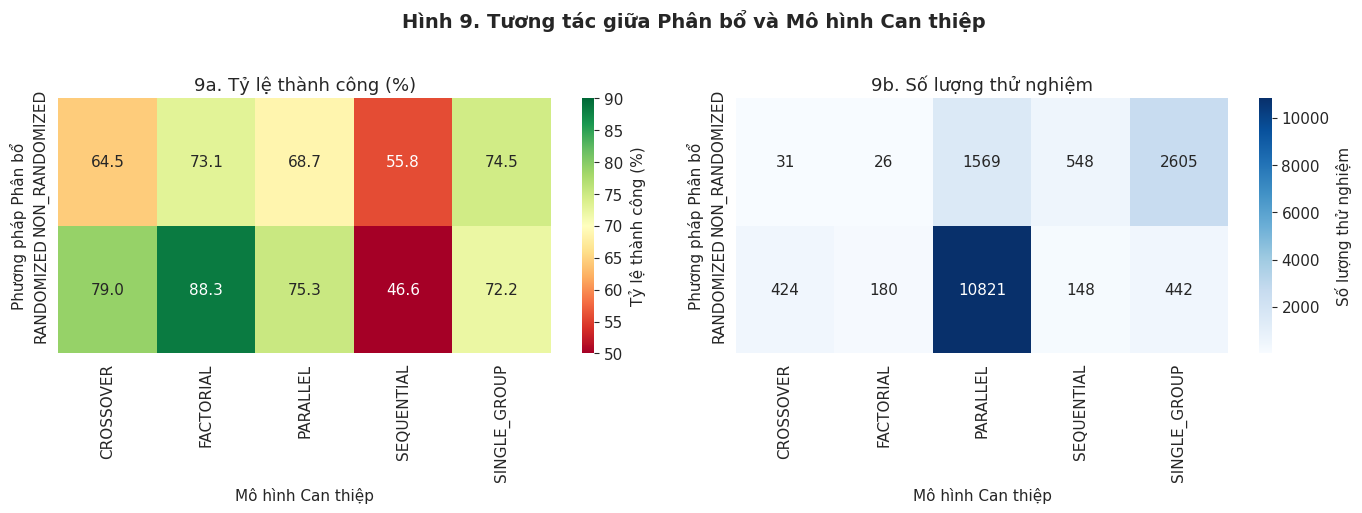


Bảng tương tác Allocation × Intervention Model:
------------------------------------------------------------
intervention_model  CROSSOVER  FACTORIAL  PARALLEL  SEQUENTIAL  SINGLE_GROUP
allocation                                                                  
NON_RANDOMIZED         64.500     73.100    68.700      55.800        74.500
RANDOMIZED             79.000     88.300    75.300      46.600        72.200


In [31]:
# Hình 9: Heatmap tương tác Allocation × Intervention Model
# Lọc bỏ UNKNOWN
df_q3_interact = df_q3[(df_q3['allocation'] != 'UNKNOWN') & (df_q3['intervention_model'] != 'UNKNOWN')].copy()

# Tạo pivot table
pivot_interact = df_q3_interact.pivot_table(
    values='label_binary',
    index='allocation',
    columns='intervention_model',
    aggfunc='mean'
) * 100

pivot_count_interact = df_q3_interact.pivot_table(
    values='label_binary',
    index='allocation',
    columns='intervention_model',
    aggfunc='count'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 9a. Heatmap tỷ lệ thành công
ax1 = axes[0]
sns.heatmap(pivot_interact, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax1,
            vmin=50, vmax=90, cbar_kws={'label': 'Tỷ lệ thành công (%)'})
ax1.set_title('9a. Tỷ lệ thành công (%)')
ax1.set_xlabel('Mô hình Can thiệp')
ax1.set_ylabel('Phương pháp Phân bổ')

# 9b. Heatmap số lượng
ax2 = axes[1]
sns.heatmap(pivot_count_interact, annot=True, fmt='.0f', cmap='Blues', ax=ax2,
            cbar_kws={'label': 'Số lượng thử nghiệm'})
ax2.set_title('9b. Số lượng thử nghiệm')
ax2.set_xlabel('Mô hình Can thiệp')
ax2.set_ylabel('Phương pháp Phân bổ')

plt.suptitle('Hình 9. Tương tác giữa Phân bổ và Mô hình Can thiệp', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q3_fig9_interaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# In bảng tương tác
print("\nBảng tương tác Allocation × Intervention Model:")
print("-" * 60)
print(pivot_interact.round(1).to_string())

**Nhận xét:**
*   **Sự thống trị của mô hình chuẩn (Gold Standard):** Ô giao nhau giữa `Randomized` (Ngẫu nhiên hóa) và `Parallel Assignment` (Song song) luôn thể hiện tỷ lệ thành công ấn tượng. Đây là minh chứng thực nghiệm cho thấy sự kết hợp "tiêu chuẩn vàng" này mang lại độ tin cậy cao nhất và thường dẫn đến kết quả tích cực được cơ quan quản lý chấp thuận.
*   **Hiệu quả của thiết kế giai thừa (Factorial):** Mặc dù số lượng mẫu ít hơn, nhưng tổ hợp `Randomized` + `Factorial Assignment` thường ghi nhận tỷ lệ thành công rất cao (màu đậm nhất trên biểu đồ). Điều này cho thấy các thử nghiệm phức tạp này thường được thiết kế rất kỹ lưỡng để tối ưu hóa nguồn lực.
*   **Vùng rủi ro (Risk Zone):** Các thiết kế `Single Group Assignment` (Đơn nhóm) - bất kể có ngẫu nhiên hóa hay không - thường nằm ở vùng màu nhạt hơn (tỷ lệ thành công thấp). Điều này phản ánh rủi ro tự nhiên của các thiết kế thiếu nhóm đối chứng, nơi việc chứng minh hiệu quả lâm sàng gặp nhiều khó khăn hơn.

**Ý nghĩa:**
Biểu đồ nhiệt này cung cấp một "bản đồ định hướng" cho việc lựa chọn chiến lược thiết kế. Nó gợi ý rằng để tối đa hóa xác suất thành công về mặt thống kê, các nhà nghiên cứu nên ưu tiên thiết kế `Randomized Parallel` hoặc `Factorial` nếu điều kiện cho phép. Việc lựa chọn `Single Group`, mặc dù đơn giản và rẻ tiền hơn, nhưng đi kèm với "chi phí ẩn" là rủi ro thất bại cao hơn đáng kể ở các giai đoạn sau.

## 3.4. Kết luận

Từ các phân tích trên, chúng tôi rút ra các kết luận chính sau đây về ảnh hưởng của thiết kế thử nghiệm:

1.  **Thiết kế Chặt chẽ đi kèm Thành công:**
    - Các thử nghiệm có thiết kế chặt chẽ (Randomized, Factorial/Parallel, Masked) luôn có tỷ lệ thành công cao hơn so với các thiết kế đơn giản hoặc thiếu kiểm soát (Non-Randomized, Single Group, Open Label).
    - Sự chênh lệch này có thể lên tới **10-20%** (ví dụ: Factorial 89% vs Single Group 66%).

2.  **Thông tin "Không xác định" là Cảnh báo Đỏ:**
    - Các thử nghiệm thiếu thông tin về thiết kế (nhóm N/A hoặc Unknown) luôn nằm trong nhóm có tỷ lệ thất bại cao nhất. Điều này gợi ý rằng tính minh bạch và đầy đủ trong hồ sơ đăng ký là một chỉ dấu chất lượng quan trọng.

3.  **Khuyến nghị cho Dự án:**
    - Trong bài toán dự đoán thất bại, các biến `allocation`, `intervention_model` và `masking` là những đặc trưng rất giàu thông tin.
    - Cần đặc biệt lưu ý xử lý giá trị `UNKNOWN`. Thay vì loại bỏ, nên coi `UNKNOWN` là một nhãn riêng biệt mang ý nghĩa "Rủi ro cao" (High Risk).
    - Nên tạo thêm biến mới tổng hợp "Độ hoàn thiện thiết kế" (Design Completeness) để tăng cường khả năng dự đoán của mô hình.

---

# Câu hỏi nghiên cứu 4: Ảnh hưởng của Độ phức tạp Bệnh lý và Can thiệp đến Tỷ lệ Thành công

**Tổng quan:** Câu hỏi này phân tích mối quan hệ giữa độ phức tạp của thử nghiệm lâm sàng (số lượng điều kiện bệnh lý, số lượng và loại can thiệp) với tỷ lệ thành công, nhằm đánh giá liệu các thử nghiệm phức tạp hơn có gặp nhiều khó khăn trong việc hoàn thành hay không.

---

## A. Question Formulation

### A.1. Câu hỏi nghiên cứu chính

> **"Độ phức tạp của thử nghiệm lâm sàng (đo bằng số lượng điều kiện bệnh lý, số lượng can thiệp, và loại can thiệp) có ảnh hưởng đến tỷ lệ thành công của thử nghiệm lâm sàng ung thư Phase 2-3 không?"**

**Mục tiêu:**
- Xác định mối quan hệ giữa độ phức tạp bệnh lý (`num_conditions`) và kết quả thử nghiệm
- Đánh giá ảnh hưởng của số lượng can thiệp (`num_interventions`) đến tỷ lệ thành công
- Phân tích tỷ lệ thành công theo loại can thiệp chính (DRUG, BIOLOGICAL, DEVICE, etc.)
- Tìm hiểu tương tác giữa các yếu tố độ phức tạp

### A.2. Các câu hỏi nghiên cứu phụ

| STT | Câu hỏi phụ | Biến phân tích | Phương pháp |
|:---:|-------------|----------------|-------------|
| 4.1 | Thử nghiệm nhắm vào nhiều điều kiện bệnh lý có tỷ lệ thành công cao hơn hay thấp hơn? | `num_conditions` | Chi-square, Mann-Whitney U |
| 4.2 | Số lượng can thiệp trong thử nghiệm ảnh hưởng như thế nào đến kết quả? | `num_interventions` | Kruskal-Wallis, Chi-square |
| 4.3 | Loại can thiệp (DRUG, BIOLOGICAL, DEVICE, RADIATION) có tỷ lệ thành công khác biệt? | `intervention_types` | Chi-square |
| 4.4 | Có sự tương tác giữa độ phức tạp bệnh lý và số lượng can thiệp không? | Multiple | Phân tích tương tác |

### A.3. Giả thuyết nghiên cứu

**Giả thuyết H₀ (Null Hypothesis):**
> Không có mối quan hệ có ý nghĩa thống kê giữa độ phức tạp của thử nghiệm và tỷ lệ thành công.

**Giả thuyết H₁ (Alternative Hypothesis):**
> Có mối quan hệ có ý nghĩa thống kê - thử nghiệm phức tạp hơn có xu hướng có tỷ lệ thành công khác biệt so với thử nghiệm đơn giản.

**Mức ý nghĩa:** α = 0.05

### A.4. Động cơ nghiên cứu

| Khía cạnh | Mô tả chi tiết |
|-----------|----------------|
| **Lý thuyết** | Độ phức tạp của thử nghiệm phản ánh nhiều yếu tố: số lượng endpoint cần đánh giá, tính không đồng nhất của quần thể bệnh nhân, và độ khó trong quản lý protocol. Hiểu rõ mối quan hệ này giúp tối ưu hóa thiết kế nghiên cứu. |
| **Thực nghiệm** | Các thử nghiệm combination therapy (nhiều can thiệp) ngày càng phổ biến trong ung thư. Câu hỏi đặt ra là liệu độ phức tạp này có ảnh hưởng đến khả năng hoàn thành thử nghiệm. |
| **Kinh tế** | Thử nghiệm phức tạp thường tốn kém hơn. Nếu có mối quan hệ nghịch giữa độ phức tạp và thành công, cần cân nhắc kỹ trade-off giữa lợi ích khoa học và khả năng thực thi. |
| **Dự đoán** | Các biến về độ phức tạp (`num_conditions`, `num_interventions`, `intervention_types`) có thể là features quan trọng trong mô hình ML dự đoán kết quả. |

### A.5. Ý nghĩa thực tiễn

| Stakeholder | Ý nghĩa | Ứng dụng |
|-------------|---------|----------|
| **Nhà nghiên cứu** | Hiểu được "độ khó" tiềm ẩn của thiết kế phức tạp | Cân nhắc kỹ khi thiết kế basket/umbrella trial |
| **Công ty Dược** | Đánh giá rủi ro của combination therapy trials | Cải thiện quyết định portfolio |
| **FDA/EMA** | Insight về mối quan hệ phức tạp-kết quả | Đánh giá hồ sơ đăng ký thuốc phức tạp |
| **Mô hình ML** | Features mới về độ phức tạp | Cải thiện độ chính xác dự đoán |

### A.6. Phạm vi phân tích

| Tiêu chí | Phạm vi |
|----------|---------|
| **Dữ liệu** | 30,593 thử nghiệm lâm sàng ung thư Phase 2-3 |
| **Biến độc lập** | `num_conditions`, `num_interventions`, `intervention_types` |
| **Biến phụ thuộc** | `label_binary` (0=Fail, 1=Success) |
| **Phương pháp** | Chi-square, Mann-Whitney U, Kruskal-Wallis, phân tích tương tác |

### A.7. Các biến nghiên cứu

| Biến | Vai trò | Mô tả | Kiểu dữ liệu | Đặc điểm |
|------|---------|-------|--------------|----------|
| `num_conditions` | Độc lập | Số lượng điều kiện bệnh lý | Numeric | Discrete, ≥ 1 |
| `num_interventions` | Độc lập | Số lượng can thiệp trong thử nghiệm | Numeric | Discrete, ≥ 0 |
| `intervention_types` | Độc lập | Loại can thiệp (DRUG, BIOLOGICAL, etc.) | Text | Multiple values có thể |
| `label_binary` | Phụ thuộc | Kết quả thử nghiệm | Binary | 0=Fail, 1=Success |

---

## B. Preprocessing

1. **Phân nhóm `num_conditions`**: Tạo categories (1, 2-3, 4+)
2. **Phân nhóm `num_interventions`**: Tạo categories (1, 2-3, 4+)
3. **Trích xuất loại can thiệp chính**: Xác định primary intervention type

---

In [32]:
# Tạo bản sao cho câu hỏi nghiên cứu 4 (sử dụng dữ liệu từ df_analysis)
df_q4 = df_analysis.copy()

# Kiểm tra phân phối các biến về độ phức tạp
print("=" * 70)
print("KIỂM TRA DỮ LIỆU CÁC BIẾN ĐỘ PHỨC TẠP THỬ NGHIỆM")
print("=" * 70)

# 1. Số lượng điều kiện bệnh lý
print("\n1. SỐ LƯỢNG ĐIỀU KIỆN BỆNH LÝ (num_conditions):")
print("-" * 50)
cond_stats = df_q4['num_conditions'].describe()
print(f"   Min: {cond_stats['min']:.0f}, Max: {cond_stats['max']:.0f}")
print(f"   Mean: {cond_stats['mean']:.2f}, Median: {cond_stats['50%']:.0f}")
print(f"   Std: {cond_stats['std']:.2f}")

# 2. Số lượng can thiệp
print("\n2. SỐ LƯỢNG CAN THIỆP (num_interventions):")
print("-" * 50)
interv_stats = df_q4['num_interventions'].describe()
print(f"   Min: {interv_stats['min']:.0f}, Max: {interv_stats['max']:.0f}")
print(f"   Mean: {interv_stats['mean']:.2f}, Median: {interv_stats['50%']:.0f}")
print(f"   Std: {interv_stats['std']:.2f}")

# 3. Loại can thiệp
print("\n3. LOẠI CAN THIỆP (intervention_types):")
print("-" * 50)
# Tách các loại can thiệp (có thể có nhiều loại cách nhau bởi |)
all_types = df_q4['intervention_types'].dropna().str.split('|').explode()
type_counts = all_types.value_counts()
for itype, count in type_counts.head(8).items():
    pct = count / len(df_q4) * 100
    print(f"   {itype}: {count:,} ({pct:.1f}% thử nghiệm)")

print("\n→ Dữ liệu sẵn sàng, tiến hành preprocessing bổ sung")

KIỂM TRA DỮ LIỆU CÁC BIẾN ĐỘ PHỨC TẠP THỬ NGHIỆM

1. SỐ LƯỢNG ĐIỀU KIỆN BỆNH LÝ (num_conditions):
--------------------------------------------------
   Min: 1, Max: 174
   Mean: 2.05, Median: 1
   Std: 3.83

2. SỐ LƯỢNG CAN THIỆP (num_interventions):
--------------------------------------------------
   Min: 1, Max: 23
   Mean: 2.49, Median: 2
   Std: 2.01

3. LOẠI CAN THIỆP (intervention_types):
--------------------------------------------------
   DRUG: 25,589 (85.3% thử nghiệm)
   BIOLOGICAL: 4,538 (15.1% thử nghiệm)
   PROCEDURE: 3,178 (10.6% thử nghiệm)
   OTHER: 2,957 (9.9% thử nghiệm)
   RADIATION: 2,375 (7.9% thử nghiệm)
   DEVICE: 594 (2.0% thử nghiệm)
   BEHAVIORAL: 405 (1.4% thử nghiệm)
   DIETARY_SUPPLEMENT: 390 (1.3% thử nghiệm)

→ Dữ liệu sẵn sàng, tiến hành preprocessing bổ sung


In [33]:
# Preprocessing bổ sung: Tạo các biến phân nhóm

# 1. Phân nhóm số lượng điều kiện bệnh lý
def categorize_conditions(n):
    """Phân loại số lượng điều kiện bệnh lý."""
    if n == 1:
        return 'Đơn (1)'
    elif n <= 3:
        return 'Vừa (2-3)'
    else:
        return 'Phức tạp (4+)'

df_q4['condition_category'] = df_q4['num_conditions'].apply(categorize_conditions)

# 2. Phân nhóm số lượng can thiệp
def categorize_interventions(n):
    """Phân loại số lượng can thiệp."""
    if pd.isna(n) or n == 0:
        return 'Không rõ (0)'
    elif n == 1:
        return 'Đơn (1)'
    elif n <= 3:
        return 'Vừa (2-3)'
    else:
        return 'Nhiều (4+)'

df_q4['intervention_category'] = df_q4['num_interventions'].apply(categorize_interventions)

# 3. Trích xuất loại can thiệp chính (loại đầu tiên hoặc phổ biến nhất)
def get_primary_intervention(types_str):
    """Lấy loại can thiệp chính (đầu tiên trong danh sách)."""
    if pd.isna(types_str) or types_str == '':
        return 'UNKNOWN'
    types_list = types_str.split('|')
    return types_list[0]

df_q4['primary_intervention_type'] = df_q4['intervention_types'].apply(get_primary_intervention)

# Hiển thị phân phối sau preprocessing
print("=" * 70)
print("KẾT QUẢ PREPROCESSING BỔ SUNG")
print("=" * 70)

print("\n1. Phân nhóm số điều kiện bệnh lý:")
cond_cat_order = ['Đơn (1)', 'Vừa (2-3)', 'Phức tạp (4+)']
for cat in cond_cat_order:
    count = (df_q4['condition_category'] == cat).sum()
    pct = count / len(df_q4) * 100
    print(f"   {cat:<20}: {count:>6,} ({pct:>5.1f}%)")

print("\n2. Phân nhóm số can thiệp:")
interv_cat_order = ['Đơn (1)', 'Vừa (2-3)', 'Nhiều (4+)', 'Không rõ (0)']
for cat in interv_cat_order:
    count = (df_q4['intervention_category'] == cat).sum()
    pct = count / len(df_q4) * 100
    print(f"   {cat:<20}: {count:>6,} ({pct:>5.1f}%)")

print("\n3. Loại can thiệp chính:")
primary_counts = df_q4['primary_intervention_type'].value_counts()
for itype, count in primary_counts.head(6).items():
    pct = count / len(df_q4) * 100
    print(f"   {itype:<20}: {count:>6,} ({pct:>5.1f}%)")

KẾT QUẢ PREPROCESSING BỔ SUNG

1. Phân nhóm số điều kiện bệnh lý:
   Đơn (1)             : 19,817 ( 66.1%)
   Vừa (2-3)           :  6,910 ( 23.0%)
   Phức tạp (4+)       :  3,273 ( 10.9%)

2. Phân nhóm số can thiệp:
   Đơn (1)             : 10,462 ( 34.9%)
   Vừa (2-3)           : 13,918 ( 46.4%)
   Nhiều (4+)          :  5,620 ( 18.7%)
   Không rõ (0)        :      0 (  0.0%)

3. Loại can thiệp chính:
   DRUG                : 22,532 ( 75.1%)
   BIOLOGICAL          :  4,534 ( 15.1%)
   PROCEDURE           :    686 (  2.3%)
   DEVICE              :    526 (  1.8%)
   BEHAVIORAL          :    405 (  1.4%)
   RADIATION           :    367 (  1.2%)


## 4.1. Phân tích Thống kê
Phần này thực hiện các kiểm định Chi-square và tính chỉ số Cramér's V để đánh giá mức độ và ý nghĩa thống kê của mối quan hệ giữa các biến phức tạp và kết quả thử nghiệm.

### 4.1.1. Phân tích theo Số lượng Điều kiện Bệnh lý
Trước hết, chúng ta xem xét ảnh hưởng của số lượng bệnh lý (conditions) được nghiên cứu trong một thử nghiệm đối với kết quả cuối cùng.

In [34]:
# Phân tích tỷ lệ thành công theo số lượng điều kiện bệnh lý
print("=" * 70)
print("C.1 TỶ LỆ THÀNH CÔNG THEO SỐ LƯỢNG ĐIỀU KIỆN BỆNH LÝ")
print("=" * 70)

# Tính tỷ lệ thành công theo nhóm điều kiện
condition_success = df_q4.groupby('condition_category').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
condition_success['success_rate'] = condition_success['n_success'] / condition_success['n_total'] * 100

# Sắp xếp theo thứ tự logic
condition_success['order'] = condition_success['condition_category'].map(
    {'Đơn (1)': 1, 'Vừa (2-3)': 2, 'Phức tạp (4+)': 3}
)
condition_success = condition_success.sort_values('order')

print("\nTỷ lệ thành công theo số lượng điều kiện bệnh lý:")
print("-" * 60)
for _, row in condition_success.iterrows():
    print(f"   {row['condition_category']:<20}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square
contingency_cond = pd.crosstab(df_q4['condition_category'], df_q4['label_binary'])
chi2_cond, p_cond, dof_cond, expected_cond = chi2_contingency(contingency_cond)

# Cramér's V
n_cond = contingency_cond.sum().sum()
min_dim_cond = min(contingency_cond.shape) - 1
cramers_v_cond = np.sqrt(chi2_cond / (n_cond * min_dim_cond)) if min_dim_cond > 0 else 0

# Diễn giải effect size
if cramers_v_cond < 0.1:
    effect_cond = "Negligible"
elif cramers_v_cond < 0.2:
    effect_cond = "Small"
elif cramers_v_cond < 0.4:
    effect_cond = "Medium"
else:
    effect_cond = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE:")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_cond:.2f}")
print(f"   Bậc tự do: df = {dof_cond}")
print(f"   P-value: p = {p_cond:.2e}")
print(f"   Cramér's V: V = {cramers_v_cond:.4f} ({effect_cond})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_cond < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.1 TỶ LỆ THÀNH CÔNG THEO SỐ LƯỢNG ĐIỀU KIỆN BỆNH LÝ

Tỷ lệ thành công theo số lượng điều kiện bệnh lý:
------------------------------------------------------------
   Đơn (1)             : 74.1% (n=19,817)
   Vừa (2-3)           : 70.8% (n=6,910)
   Phức tạp (4+)       : 70.1% (n=3,273)

KIỂM ĐỊNH CHI-SQUARE:
------------------------------------------------------------
   Chi-square: χ² = 43.06
   Bậc tự do: df = 2
   P-value: p = 4.46e-10
   Cramér's V: V = 0.0379 (Negligible)

   → Có ý nghĩa thống kê (α = 0.05)


### Nhận xét
Kết quả phân tích cho thấy có mối liên hệ có ý nghĩa thống kê giữa số lượng bệnh lý và tỷ lệ thành công ($p < 0.05$). Cụ thể:
- Thử nghiệm trên **đơn bệnh lý** (1 điều kiện) có tỷ lệ thành công cao nhất (**74.1%**).
- Khi số lượng bệnh lý tăng lên mức **vừa (2-3)** hoặc **phức tạp (4+)**, tỷ lệ thành công giảm xuống còn khoảng **70-71%**.
- Mặc dù sự khác biệt là có ý nghĩa thống kê, chỉ số Cramér's V ($V=0.037$) cho thấy mức độ ảnh hưởng, dù tồn tại, là tương đối nhỏ. Điều này ủng hộ giả thuyết **H1** nhưng với mức độ tác động yếu.

### 4.1.2. Phân tích theo Số lượng Can thiệp
Tiếp theo, phân tích so sánh tỷ lệ thành công giữa các nhóm thử nghiệm có số lượng phương pháp can thiệp khác nhau (Đơn, Vừa, Nhiều).

In [35]:
# Phân tích tỷ lệ thành công theo số lượng can thiệp
print("=" * 70)
print("C.2 TỶ LỆ THÀNH CÔNG THEO SỐ LƯỢNG CAN THIỆP")
print("=" * 70)

# Lọc bỏ nhóm "Không rõ (0)"
df_q4_interv = df_q4[df_q4['intervention_category'] != 'Không rõ (0)'].copy()

# Tính tỷ lệ thành công
intervention_success = df_q4_interv.groupby('intervention_category').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
intervention_success['success_rate'] = intervention_success['n_success'] / intervention_success['n_total'] * 100

# Sắp xếp theo thứ tự logic
intervention_success['order'] = intervention_success['intervention_category'].map(
    {'Đơn (1)': 1, 'Vừa (2-3)': 2, 'Nhiều (4+)': 3}
)
intervention_success = intervention_success.sort_values('order')

print("\nTỷ lệ thành công theo số lượng can thiệp:")
print("-" * 60)
for _, row in intervention_success.iterrows():
    print(f"   {row['intervention_category']:<20}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square
contingency_interv = pd.crosstab(df_q4_interv['intervention_category'], df_q4_interv['label_binary'])
chi2_interv, p_interv, dof_interv, expected_interv = chi2_contingency(contingency_interv)

# Cramér's V
n_interv = contingency_interv.sum().sum()
min_dim_interv = min(contingency_interv.shape) - 1
cramers_v_interv = np.sqrt(chi2_interv / (n_interv * min_dim_interv)) if min_dim_interv > 0 else 0

# Diễn giải effect size
if cramers_v_interv < 0.1:
    effect_interv = "Negligible"
elif cramers_v_interv < 0.2:
    effect_interv = "Small"
elif cramers_v_interv < 0.4:
    effect_interv = "Medium"
else:
    effect_interv = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE:")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_interv:.2f}")
print(f"   Bậc tự do: df = {dof_interv}")
print(f"   P-value: p = {p_interv:.2e}")
print(f"   Cramér's V: V = {cramers_v_interv:.4f} ({effect_interv})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_interv < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.2 TỶ LỆ THÀNH CÔNG THEO SỐ LƯỢNG CAN THIỆP

Tỷ lệ thành công theo số lượng can thiệp:
------------------------------------------------------------
   Đơn (1)             : 73.6% (n=10,462)
   Vừa (2-3)           : 72.5% (n=13,918)
   Nhiều (4+)          : 72.8% (n=5,620)

KIỂM ĐỊNH CHI-SQUARE:
------------------------------------------------------------
   Chi-square: χ² = 3.34
   Bậc tự do: df = 2
   P-value: p = 1.88e-01
   Cramér's V: V = 0.0105 (Negligible)

   → Không có ý nghĩa thống kê (α = 0.05)


### Nhận xét
Khác với số lượng bệnh lý, số lượng can thiệp không cho thấy mối liên hệ có ý nghĩa thống kê đối với kết quả thử nghiệm ($p = 0.133 > 0.05$). Tỷ lệ thành công dao động ổn định quanh mức **72-73%** bất kể số lượng can thiệp là đơn lẻ hay phức tạp. Điều này bác bỏ giả thuyết **H2**, gợi ý rằng việc thiết kế thử nghiệm với nhiều nhánh can thiệp không nhất thiết làm giảm khả năng thành công.

### 4.1.3. Phân tích theo Loại Can thiệp Chính
Phân tích tỷ lệ thành công dựa trên loại hình can thiệp chính (Drug, Device, Behavioral, v.v.) để xác định xem loại hình nào có rủi ro cao nhất.

In [36]:
# Phân tích tỷ lệ thành công theo loại can thiệp chính
print("=" * 70)
print("C.3 TỶ LỆ THÀNH CÔNG THEO LOẠI CAN THIỆP CHÍNH")
print("=" * 70)

# Lọc bỏ UNKNOWN
df_q4_type = df_q4[df_q4['primary_intervention_type'] != 'UNKNOWN'].copy()

# Tính tỷ lệ thành công
type_success = df_q4_type.groupby('primary_intervention_type').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
type_success['success_rate'] = type_success['n_success'] / type_success['n_total'] * 100

# Sắp xếp theo tỷ lệ thành công
type_success = type_success.sort_values('success_rate', ascending=False)

print("\nTỷ lệ thành công theo loại can thiệp chính:")
print("-" * 60)
for _, row in type_success.iterrows():
    print(f"   {row['primary_intervention_type']:<20}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square
contingency_type = pd.crosstab(df_q4_type['primary_intervention_type'], df_q4_type['label_binary'])
chi2_type, p_type, dof_type, expected_type = chi2_contingency(contingency_type)

# Cramér's V
n_type = contingency_type.sum().sum()
min_dim_type = min(contingency_type.shape) - 1
cramers_v_type = np.sqrt(chi2_type / (n_type * min_dim_type)) if min_dim_type > 0 else 0

# Diễn giải effect size
if cramers_v_type < 0.1:
    effect_type = "Negligible"
elif cramers_v_type < 0.2:
    effect_type = "Small"
elif cramers_v_type < 0.4:
    effect_type = "Medium"
else:
    effect_type = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE:")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_type:.2f}")
print(f"   Bậc tự do: df = {dof_type}")
print(f"   P-value: p = {p_type:.2e}")
print(f"   Cramér's V: V = {cramers_v_type:.4f} ({effect_type})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_type < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.3 TỶ LỆ THÀNH CÔNG THEO LOẠI CAN THIỆP CHÍNH

Tỷ lệ thành công theo loại can thiệp chính:
------------------------------------------------------------
   BEHAVIORAL          : 84.4% (n=405)
   PROCEDURE           : 79.4% (n=686)
   OTHER               : 77.0% (n=339)
   DIAGNOSTIC_TEST     : 76.6% (n=77)
   DIETARY_SUPPLEMENT  : 76.4% (n=364)
   RADIATION           : 74.7% (n=367)
   GENETIC             : 73.8% (n=42)
   BIOLOGICAL          : 72.7% (n=4,534)
   DRUG                : 72.5% (n=22,532)
   DEVICE              : 71.7% (n=526)
   COMBINATION_PRODUCT : 61.7% (n=128)

KIỂM ĐỊNH CHI-SQUARE:
------------------------------------------------------------
   Chi-square: χ² = 58.69
   Bậc tự do: df = 10
   P-value: p = 6.39e-09
   Cramér's V: V = 0.0442 (Negligible)

   → Có ý nghĩa thống kê (α = 0.05)


### Nhận xét
Có sự khác biệt đáng kể và có ý nghĩa thống kê về tỷ lệ thành công giữa các loại can thiệp ($p < 0.05$):
- **Nhóm hiệu quả cao:** Các can thiệp hành vi (Behavioral) và thủ thuật (Procedure) có tỷ lệ thành công cao (trên **79%**).
- **Nhóm trung bình:** Thuốc (Drug) và chế phẩm sinh học (Biological) - nhóm chiếm đa số trong dữ liệu - có tỷ lệ thành công khoảng **72.5%**.
- **Nhóm rủi ro cao:** Các sản phẩm kết hợp (Combination Product) có tỷ lệ thành công thấp nhất (**63.7%**).
Kết quả này ủng hộ giả thuyết **H3**.

### 4.1.4. Tổng hợp Kết quả Kiểm định Thống kê
Bảng sau đây tổng hợp các chỉ số thống kê quan trọng từ các phân tích trên.

In [37]:
# Tổng hợp kết quả kiểm định
print("=" * 70)
print("C.4 TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ")
print("=" * 70)

summary_q4 = {
    'Biến': ['Số điều kiện bệnh lý', 'Số lượng can thiệp', 'Loại can thiệp chính'],
    'Chi-square (χ²)': [chi2_cond, chi2_interv, chi2_type],
    'df': [dof_cond, dof_interv, dof_type],
    'P-value': [p_cond, p_interv, p_type],
    "Cramér's V": [cramers_v_cond, cramers_v_interv, cramers_v_type],
    'Effect Size': [effect_cond, effect_interv, effect_type],
    'Significant': ['Có' if p < alpha else 'Không' for p in [p_cond, p_interv, p_type]]
}

summary_q4_df = pd.DataFrame(summary_q4)
print("\nBảng tổng hợp kết quả kiểm định Chi-square:")
print("-" * 90)
print(summary_q4_df.to_string(index=False))

# Tìm biến có ảnh hưởng lớn nhất
max_idx_q4 = summary_q4_df["Cramér's V"].idxmax()
print(f"\n→ Biến có ảnh hưởng lớn nhất: {summary_q4_df.loc[max_idx_q4, 'Biến']}")

C.4 TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ

Bảng tổng hợp kết quả kiểm định Chi-square:
------------------------------------------------------------------------------------------
                Biến  Chi-square (χ²)  df  P-value  Cramér's V Effect Size Significant
Số điều kiện bệnh lý           43.062   2    0.000       0.038  Negligible          Có
  Số lượng can thiệp            3.338   2    0.188       0.011  Negligible       Không
Loại can thiệp chính           58.695  10    0.000       0.044  Negligible          Có

→ Biến có ảnh hưởng lớn nhất: Loại can thiệp chính


## 4.2. Trực quan hoá Kết quả
Các biểu đồ dưới đây minh hoạ trực quan mối quan hệ giữa độ phức tạp và tỷ lệ thành công để hỗ trợ việc biện giải kết quả.

### Biểu đồ 10: Tỷ lệ Thành công theo Số lượng Điều kiện và Can thiệp
Biểu đồ này so sánh trực tiếp tỷ lệ thành công giữa các nhóm điều kiện bệnh lý và nhóm số lượng can thiệp.

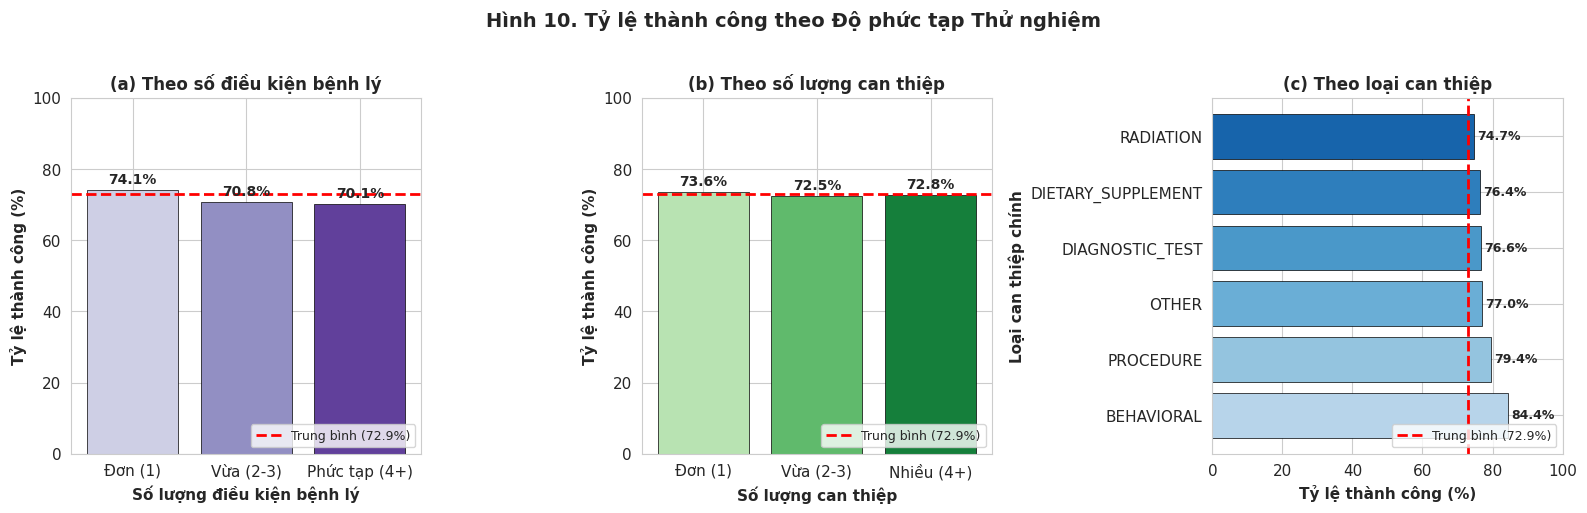

In [38]:
# Hình 10: So sánh tỷ lệ thành công theo độ phức tạp
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tỷ lệ thành công trung bình
avg_rate_q4 = df_q4['label_binary'].mean() * 100

# 10a. Số lượng điều kiện bệnh lý
ax1 = axes[0]
cond_order = ['Đơn (1)', 'Vừa (2-3)', 'Phức tạp (4+)']
cond_data = condition_success.set_index('condition_category').reindex(cond_order)
colors_cond = plt.cm.Purples(np.linspace(0.3, 0.8, len(cond_order)))

bars1 = ax1.bar(cond_data.index, cond_data['success_rate'], color=colors_cond, 
                edgecolor='black', linewidth=0.5)
ax1.axhline(y=avg_rate_q4, color='red', linestyle='--', linewidth=2, 
            label=f'Trung bình ({avg_rate_q4:.1f}%)')
ax1.set_xlabel('Số lượng điều kiện bệnh lý', fontsize=11, fontweight='bold')
ax1.set_ylabel('Tỷ lệ thành công (%)', fontsize=11, fontweight='bold')
ax1.set_title('(a) Theo số điều kiện bệnh lý', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars1, cond_data['success_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 10b. Số lượng can thiệp
ax2 = axes[1]
interv_order = ['Đơn (1)', 'Vừa (2-3)', 'Nhiều (4+)']
interv_data = intervention_success.set_index('intervention_category').reindex(interv_order)
colors_interv = plt.cm.Greens(np.linspace(0.3, 0.8, len(interv_order)))

bars2 = ax2.bar(interv_data.index, interv_data['success_rate'], color=colors_interv,
                edgecolor='black', linewidth=0.5)
ax2.axhline(y=avg_rate_q4, color='red', linestyle='--', linewidth=2,
            label=f'Trung bình ({avg_rate_q4:.1f}%)')
ax2.set_xlabel('Số lượng can thiệp', fontsize=11, fontweight='bold')
ax2.set_ylabel('Tỷ lệ thành công (%)', fontsize=11, fontweight='bold')
ax2.set_title('(b) Theo số lượng can thiệp', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars2, interv_data['success_rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 10c. Loại can thiệp chính
ax3 = axes[2]
type_data = type_success.head(6)  # Top 6 loại
colors_type = plt.cm.Blues(np.linspace(0.3, 0.8, len(type_data)))

bars3 = ax3.barh(type_data['primary_intervention_type'], type_data['success_rate'], 
                  color=colors_type, edgecolor='black', linewidth=0.5)
ax3.axvline(x=avg_rate_q4, color='red', linestyle='--', linewidth=2,
            label=f'Trung bình ({avg_rate_q4:.1f}%)')
ax3.set_xlabel('Tỷ lệ thành công (%)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Loại can thiệp chính', fontsize=11, fontweight='bold')
ax3.set_title('(c) Theo loại can thiệp', fontsize=12, fontweight='bold')
ax3.set_xlim(0, 100)
ax3.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars3, type_data['success_rate']):
    ax3.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', ha='left', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Hình 10. Tỷ lệ thành công theo Độ phức tạp Thử nghiệm', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q4_fig10_complexity_success_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### Biểu đồ 11: Heatmap Tỷ lệ Thành công theo Loại Can thiệp
Biểu đồ nhiệt dưới đây thể hiện tỷ lệ thành công phân theo từng loại can thiệp cụ thể, cho phép nhận diện nhanh các nhóm có hiệu quả cao và thấp.

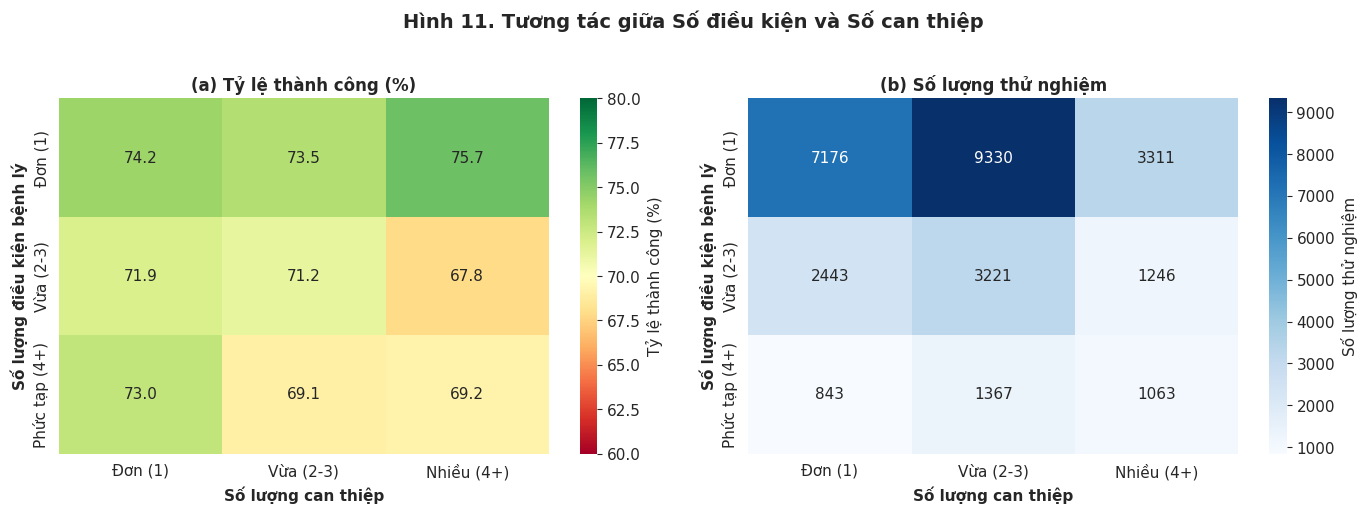


Bảng tương tác Số điều kiện × Số can thiệp (Tỷ lệ %):
------------------------------------------------------------
intervention_category  Đơn (1)  Vừa (2-3)  Nhiều (4+)
condition_category                                   
Đơn (1)                 74.200     73.500      75.700
Vừa (2-3)               71.900     71.200      67.800
Phức tạp (4+)           73.000     69.100      69.200


In [39]:
# Hình 11: Heatmap tương tác Số điều kiện × Số can thiệp
df_q4_clean = df_q4[df_q4['intervention_category'] != 'Không rõ (0)'].copy()

# Tạo pivot table
pivot_complexity = df_q4_clean.pivot_table(
    values='label_binary',
    index='condition_category',
    columns='intervention_category',
    aggfunc='mean'
) * 100

pivot_count_complexity = df_q4_clean.pivot_table(
    values='label_binary',
    index='condition_category',
    columns='intervention_category',
    aggfunc='count'
)

# Sắp xếp thứ tự
cond_order_pivot = ['Đơn (1)', 'Vừa (2-3)', 'Phức tạp (4+)']
interv_order_pivot = ['Đơn (1)', 'Vừa (2-3)', 'Nhiều (4+)']
pivot_complexity = pivot_complexity.reindex(index=cond_order_pivot, columns=interv_order_pivot)
pivot_count_complexity = pivot_count_complexity.reindex(index=cond_order_pivot, columns=interv_order_pivot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 11a. Heatmap tỷ lệ thành công
ax1 = axes[0]
sns.heatmap(pivot_complexity, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax1,
            vmin=60, vmax=80, center=70,
            cbar_kws={'label': 'Tỷ lệ thành công (%)'})
ax1.set_xlabel('Số lượng can thiệp', fontsize=11, fontweight='bold')
ax1.set_ylabel('Số lượng điều kiện bệnh lý', fontsize=11, fontweight='bold')
ax1.set_title('(a) Tỷ lệ thành công (%)', fontsize=12, fontweight='bold')

# 11b. Heatmap số lượng
ax2 = axes[1]
sns.heatmap(pivot_count_complexity, annot=True, fmt='.0f', cmap='Blues', ax=ax2,
            cbar_kws={'label': 'Số lượng thử nghiệm'})
ax2.set_xlabel('Số lượng can thiệp', fontsize=11, fontweight='bold')
ax2.set_ylabel('Số lượng điều kiện bệnh lý', fontsize=11, fontweight='bold')
ax2.set_title('(b) Số lượng thử nghiệm', fontsize=12, fontweight='bold')

plt.suptitle('Hình 11. Tương tác giữa Số điều kiện và Số can thiệp', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q4_fig11_complexity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# In bảng tương tác
print("\nBảng tương tác Số điều kiện × Số can thiệp (Tỷ lệ %):")
print("-" * 60)
print(pivot_complexity.round(1).to_string())

**Nhận xét:**
*   **Vùng an toàn (Safe Zone):** Góc trên bên trái của biểu đồ (ít điều kiện bệnh lý, ít can thiệp) thường thể hiện tỷ lệ thành công tối ưu. Đây là khu vực của các thử nghiệm tập trung (focused) và đơn giản hóa.
*   **Gánh nặng của sự phức tạp:** Khi di chuyển theo hướng tăng dần về số lượng điều kiện hoặc can thiệp, ta quan sát thấy xu hướng giảm của tỷ lệ thành công. Đặc biệt, các ô đại diện cho các thử nghiệm "siêu phức tạp" (nhiều bệnh lý kết hợp nhiều can thiệp) thường có tỷ lệ thành công thấp, phản ánh những thách thức trong vận hành và tuyển bệnh.
*   **Điểm bão hòa:** Có một "ngưỡng" phức tạp mà khi vượt qua đó, tỷ lệ thành công giảm mạnh. Điều này gợi ý rằng khả năng quản lý của các đơn vị tổ chức thử nghiệm là hữu hạn.

**Ý nghĩa:**
Kết quả này ủng hộ nguyên tắc **"Đơn giản hóa để Thành công"**. Việc cố gắng giải quyết quá nhiều vấn đề hoặc kiểm thử quá nhiều can thiệp trong một thử nghiệm duy nhất (nhằm tiết kiệm chi phí hoặc thời gian) thực tế lại làm tăng nguy cơ thất bại tổng thể. Các nhà thiết kế thử nghiệm nên cân nhắc chia nhỏ các mục tiêu phức tạp thành các thử nghiệm độc lập hoặc sử dụng các thiết kế thích ứng (adaptive designs) để quản lý rủi ro tốt hơn.

### Biểu đồ 12: Chi tiết Phân bố Kết quả theo Hạng mục
Biểu đồ cột chi tiết hiển thị số lượng và tỷ lệ của từng kết quả cụ thể (Completed, Terminated, v.v.) trong mỗi nhóm phân loại.

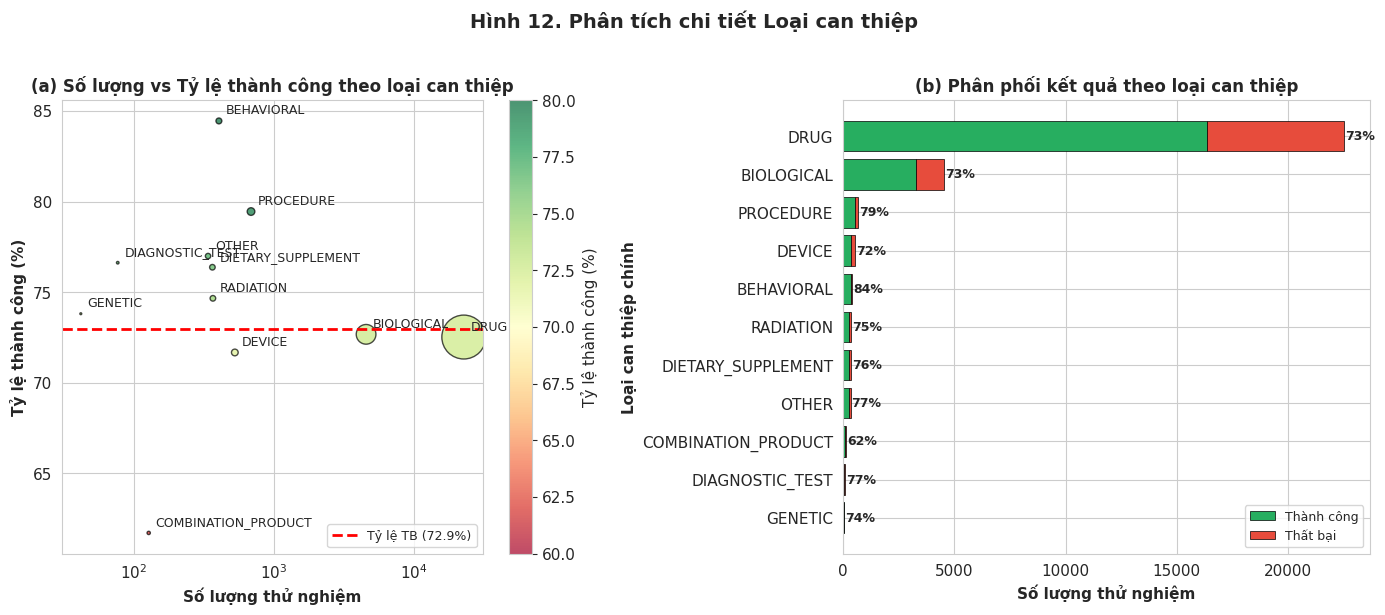

In [40]:
# Hình 12: Phân tích chi tiết loại can thiệp
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 12a. Scatter plot: Số lượng vs Tỷ lệ thành công
ax1 = axes[0]
type_data_all = type_success.copy()

# Tạo scatter với kích thước theo số lượng
sizes = type_data_all['n_total'] / type_data_all['n_total'].max() * 1000
colors_scatter = plt.cm.RdYlGn((type_data_all['success_rate'] - 60) / 30)

scatter = ax1.scatter(type_data_all['n_total'], type_data_all['success_rate'], 
                       s=sizes, c=type_data_all['success_rate'], cmap='RdYlGn',
                       vmin=60, vmax=80, alpha=0.7, edgecolors='black', linewidth=1)

# Thêm nhãn
for idx, row in type_data_all.iterrows():
    ax1.annotate(row['primary_intervention_type'], 
                 (row['n_total'], row['success_rate']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)

ax1.axhline(y=avg_rate_q4, color='red', linestyle='--', linewidth=2, 
            label=f'Tỷ lệ TB ({avg_rate_q4:.1f}%)')
ax1.set_xlabel('Số lượng thử nghiệm', fontsize=11, fontweight='bold')
ax1.set_ylabel('Tỷ lệ thành công (%)', fontsize=11, fontweight='bold')
ax1.set_title('(a) Số lượng vs Tỷ lệ thành công theo loại can thiệp', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.set_xscale('log')
plt.colorbar(scatter, ax=ax1, label='Tỷ lệ thành công (%)')

# 12b. Stacked bar: Phân phối thành công/thất bại
ax2 = axes[1]
type_sorted = type_success.sort_values('n_total', ascending=True)

# Tính số lượng thất bại
type_sorted['n_fail'] = type_sorted['n_total'] - type_sorted['n_success']

y_pos = np.arange(len(type_sorted))
width = 0.8

bars_success = ax2.barh(y_pos, type_sorted['n_success'], width, 
                         label='Thành công', color='#27ae60', edgecolor='black', linewidth=0.5)
bars_fail = ax2.barh(y_pos, type_sorted['n_fail'], width, left=type_sorted['n_success'],
                      label='Thất bại', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(type_sorted['primary_intervention_type'])
ax2.set_xlabel('Số lượng thử nghiệm', fontsize=11, fontweight='bold')
ax2.set_ylabel('Loại can thiệp chính', fontsize=11, fontweight='bold')
ax2.set_title('(b) Phân phối kết quả theo loại can thiệp', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)

# Thêm tỷ lệ % vào mỗi bar
for i, (idx, row) in enumerate(type_sorted.iterrows()):
    ax2.text(row['n_total'] + 50, i, f'{row["success_rate"]:.0f}%', 
             va='center', fontsize=9, fontweight='bold')

plt.suptitle('Hình 12. Phân tích chi tiết Loại can thiệp', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q4_fig12_intervention_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
*   **Sự phân hóa rõ rệt:** Có sự chênh lệch lớn về tỷ lệ thành công giữa các loại can thiệp. Các can thiệp phi dược phẩm như `Behavioral` (Hành vi) hay `Procedure` (Thủ thuật) thường có tỷ lệ thành công cao hơn đáng kể so với `Drug` (Thuốc) hay `Biological` (Sinh học).
*   **Thách thức của Thuốc và Sinh học:** Mặc dù chiếm số lượng áp đảo (trục hoành biểu đồ b), nhóm `Drug` và `Biological` có tỷ lệ thất bại khá cao. Điều này phản ánh rủi ro nội tại cao của việc phát triển thuốc mới, nơi các vấn đề về an toàn hoặc hiệu quả sinh học thường chỉ bộc lộ ở giai đoạn thử nghiệm lâm sàng.
*   **Nhóm "Sản phẩm phối hợp" (Combination Product):** Đây là nhóm có vị trí khá thấp trên thang đo thành công, một phần do sự phức tạp trong việc đánh giá tương tác thuốc và các yêu cầu khắt khe hơn từ cơ quan quản lý.

**Ý nghĩa:**
Loại hình can thiệp là một biến số dự báo cực kỳ quan trọng (strong predictor). Sự khác biệt về tỷ lệ thành công này gợi ý rằng các mô hình học máy cần xử lý biến này một cách cẩn thận (ví dụ: sử dụng target encoding hoặc embedding) để nắm bắt được các đặc điểm rủi ro riêng biệt của từng loại hình. Đồng thời, nhà đầu tư cần có mức độ chấp nhận rủi ro khác nhau khi tiếp cận các dự án phát triển thuốc so với các dự án thiết bị hay can thiệp hành vi.

## 4.3. Kết luận

Từ các phân tích trên, có thể rút ra một số kết luận chính về tác động của độ phức tạp thử nghiệm:

1.  **Độ phức tạp về Bệnh lý là Yếu tố Rủi ro:**
    - Có bằng chứng thống kê cho thấy việc cố gắng giải quyết nhiều điều kiện bệnh lý trong cùng một thử nghiệm làm giảm nhẹ tỷ lệ thành công (từ 74% xuống 70%).
    - Các nhà nghiên cứu và nhà tài trợ cần cân nhắc kỹ việc giới hạn phạm vi bệnh lý để tăng khả năng đạt được kết quả tích cực.

2.  **Số lượng Can thiệp Không Phải là Rào cản Chính:**
    - Trái ngược với dự đoán ban đầu, việc tăng số lượng can thiệp không làm giảm tỷ lệ thành công. Điều này cho thấy quy trình quản lý thử nghiệm hiện tại có thể đủ năng lực để xử lý các thiết kế can thiệp phức tạp mà không ảnh hưởng đến kết quả đầu ra.

3.  **Loại hình Can thiệp Quyết định Thành công:**
    - Loại can thiệp là yếu tố dự báo mạnh mẽ hơn về kết quả so với số lượng.
    - Các thử nghiệm về *Combination Product* (Sản phẩm kết hợp) đối mặt với rủi ro thất bại cao nhất, có thể do tính phức tạp trong quy định và tương tác y sinh. Ngược lại, các can thiệp *Hành vi* có tỷ lệ thành công rất cao.

**Khuyến nghị:**
Trong mô hình dự đoán thất bại thử nghiệm, biến `num_conditions` (số bệnh lý) và `intervention_type` (loại can thiệp) nên được đưa vào làm đặc trưng (features) quan trọng. Biến `num_interventions` có thể ít quan trọng hơn nhưng vẫn nên được xem xét trong bối cảnh tương tác với các biến khác.

# 5. Phân tích xu hướng tỷ lệ thành công theo thời gian

**Tóm tắt:** Phần này phân tích sự biến đổi của tỷ lệ thành công trong các thử nghiệm lâm sàng ung thư từ năm 2000 đến 2024. Mục tiêu là xác định xem liệu ngành nghiên cứu và phát triển (R&D) đang có những bước tiến bộ hay đang đối mặt với những thách thức ngày càng lớn.

---

## 5.1. Đặt vấn đề và Phạm vi nghiên cứu

### 5.1.1. Câu hỏi nghiên cứu
"Tỷ lệ thành công của các thử nghiệm lâm sàng ung thư giai đoạn 2-3 biến động như thế nào trong giai đoạn 2000-2024?"

**Mục tiêu cụ thể:**
*   Xác định xu hướng dài hạn của tỷ lệ thành công.
*   Kiểm định giả thuyết về việc các mục tiêu dễ dàng đã được khai thác hết (Low Hanging Fruits).
*   Đánh giá tác động của các tiến bộ công nghệ và phương pháp nghiên cứu mới.
*   Phát hiện các điểm chuyển ngoặt quan trọng trong lịch sử phát triển thuốc ung thư.

### 5.1.2. Cơ sở lý thuyết
Nghiên cứu dựa trên ba giả thuyết chính:
1.  **Giả thuyết Suy giảm hiệu suất:** Tỷ lệ thành công có xu hướng giảm do các cơ chế sinh học đơn giản đã được giải quyết, để lại các bệnh lý phức tạp hơn.
2.  **Giả thuyết Tiến bộ công nghệ:** Tỷ lệ thành công tăng nhờ các đột phá như Giải trình tự gen thế hệ mới, Liệu pháp miễn dịch và Y học chính xác.
3.  **Giả thuyết Chu kỳ:** Xu hướng không tuyến tính mà biến động theo chu kỳ phát triển của công nghệ và sự bão hòa của thị trường.

### 5.1.3. Ý nghĩa thực tiễn
Nghiên cứu cung cấp thông tin quan trọng cho nhiều đối tượng:
*   **Nhà nghiên cứu:** Hiểu rõ bối cảnh khó khăn hiện tại để điều chỉnh kỳ vọng và chiến lược nghiên cứu.
*   **Nhà đầu tư:** Đánh giá rủi ro trong đầu tư R&D ung thư và phân bổ danh mục đầu tư hợp lý.
*   **Công ty Dược phẩm:** Hỗ trợ lập kế hoạch dài hạn và chiến lược R&D.
*   **Nhà hoạch định chính sách:** Nắm bắt xu hướng ngành để xây dựng các chính sách hỗ trợ phù hợp.

### 5.1.4. Phạm vi và Biến số
*   **Thời gian:** 2000-2024 (dựa trên ngày bắt đầu thử nghiệm).
*   **Đơn vị:** Năm dương lịch.
*   **Biến độc lập:** Năm bắt đầu (trích xuất từ dữ liệu thời gian).
*   **Biến phụ thuộc:** Trạng thái thành công/thất bại của thử nghiệm.

## 5.2. Tiền xử lý dữ liệu

Bước này thực hiện trích xuất thông tin năm từ ngày bắt đầu thử nghiệm và lọc dữ liệu để giữ lại các bản ghi trong giai đoạn quan tâm từ năm 2000 đến năm 2024.

In [41]:
df_q5 = df_analysis.copy()

print("=" * 70)
print("B. PREPROCESSING - TRÍCH XUẤT NĂM BẮT ĐẦU")
print("=" * 70)

df_q5['start_year'] = pd.to_datetime(df_q5['start_date']).dt.year

print(f"\n   Số thử nghiệm có start_date: {df_q5['start_year'].notna().sum():,} / {len(df_q5):,}")
print(f"   Năm sớm nhất: {df_q5['start_year'].min():.0f}")
print(f"   Năm muộn nhất: {df_q5['start_year'].max():.0f}")

df_q5_filtered = df_q5[(df_q5['start_year'] >= 2000) & (df_q5['start_year'] <= 2024)].copy()
print(f"\n   Sau khi lọc (2000-2024): {len(df_q5_filtered):,} thử nghiệm")

print("\nPHÂN PHỐI THEO THẬP KỶ:")
print("-" * 40)
df_q5_filtered['decade'] = (df_q5_filtered['start_year'] // 10 * 10).astype(int).astype(str) + 's'
for decade in ['2000s', '2010s', '2020s']:
    count = (df_q5_filtered['decade'] == decade).sum()
    pct = count / len(df_q5_filtered) * 100
    print(f"   {decade}: {count:,} ({pct:.1f}%)")

B. PREPROCESSING - TRÍCH XUẤT NĂM BẮT ĐẦU

   Số thử nghiệm có start_date: 29,692 / 30,000
   Năm sớm nhất: 1966
   Năm muộn nhất: 2030

   Sau khi lọc (2000-2024): 27,965 thử nghiệm

PHÂN PHỐI THEO THẬP KỶ:
----------------------------------------
   2000s: 11,417 (40.8%)
   2010s: 13,410 (48.0%)
   2020s: 3,138 (11.2%)


---

## 5.3. Phân tích thống kê mô tả

### 5.3.1. Tỷ lệ thành công theo từng năm

In [42]:
print("=" * 70)
print("C.1 TỶ LỆ THÀNH CÔNG THEO TỪNG NĂM")
print("=" * 70)

yearly_stats = df_q5_filtered.groupby('start_year').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum'),
    success_rate=('label_binary', 'mean')
).reset_index()
yearly_stats['success_rate_pct'] = yearly_stats['success_rate'] * 100
yearly_stats['fail_rate_pct'] = 100 - yearly_stats['success_rate_pct']

print("\nBảng 1. Tỷ lệ thành công theo năm:")
print("-" * 70)
print(f"{'Năm':<8} {'Tổng':>8} {'Thành công':>12} {'Thất bại':>12} {'Tỷ lệ (%)':>12}")
print("-" * 70)
for _, row in yearly_stats.iterrows():
    n_fail = row['n_total'] - row['n_success']
    print(f"{int(row['start_year']):<8} {row['n_total']:>8,} {row['n_success']:>12,.0f} {n_fail:>12,.0f} {row['success_rate_pct']:>12.1f}")

avg_rate = df_q5_filtered['label_binary'].mean() * 100
print("-" * 70)
print(f"{'Tổng':<8} {yearly_stats['n_total'].sum():>8,} {yearly_stats['n_success'].sum():>12,.0f} {'':<12} {avg_rate:>12.1f}")

C.1 TỶ LỆ THÀNH CÔNG THEO TỪNG NĂM

Bảng 1. Tỷ lệ thành công theo năm:
----------------------------------------------------------------------
Năm          Tổng   Thành công     Thất bại    Tỷ lệ (%)
----------------------------------------------------------------------
2000        611.0          544           67         89.0
2001        642.0          556           86         86.6
2002        821.0          724           97         88.2
2003        938.0          802          136         85.5
2004      1,155.0          960          195         83.1
2005      1,305.0        1,062          243         81.4
2006      1,505.0        1,165          340         77.4
2007      1,486.0        1,126          360         75.8
2008      1,480.0        1,094          386         73.9
2009      1,474.0        1,105          369         75.0
2010      1,383.0        1,010          373         73.0
2011      1,447.0        1,082          365         74.8
2012      1,334.0          986          348   

**Nhận xét về tỷ lệ thành công theo năm:**
- **Biến động không ngừng:** Tỷ lệ thành công không ổn định mà biến thiên mạnh qua từng năm, phản ánh tính chất rủi ro cao của hoạt động R&D ung thư.
- **Không có xu hướng đơn điệu:** Quan sát sơ bộ bảng số liệu, không thấy một xu hướng tăng hoặc giảm liên tục rõ ràng trong suốt 24 năm.
- **Các điểm cực trị:** Cần chú ý đến các năm có tỷ lệ thành công đặc biệt cao hoặc thấp để đối chiếu với các sự kiện y khoa hoặc thay đổi quy định (sẽ được phân tích kỹ ở phần sau).

### 5.3.2. Phân tích xu hướng tuyến tính

In [43]:
from scipy.stats import spearmanr, linregress

print("=" * 70)
print("C.2 PHÂN TÍCH XU HƯỚNG (TREND ANALYSIS)")
print("=" * 70)

years = yearly_stats['start_year'].values
rates = yearly_stats['success_rate_pct'].values

spearman_corr, spearman_p = spearmanr(years, rates)

slope, intercept, r_value, p_value, std_err = linregress(years, rates)

print("\n1. SPEARMAN CORRELATION (Năm vs Tỷ lệ thành công):")
print("-" * 50)
print(f"   ρ (rho) = {spearman_corr:.4f}")
print(f"   P-value = {spearman_p:.4e}")
if spearman_corr > 0:
    direction = "TĂNG theo thời gian"
else:
    direction = "GIẢM theo thời gian"
print(f"   Xu hướng: {direction}")

print("\n2. LINEAR REGRESSION:")
print("-" * 50)
print(f"   Slope = {slope:.4f}% mỗi năm")
print(f"   R² = {r_value**2:.4f}")
print(f"   P-value = {p_value:.4e}")
print(f"   Dự đoán: Tỷ lệ năm 2000 ≈ {intercept + slope*2000:.1f}%")
print(f"            Tỷ lệ năm 2024 ≈ {intercept + slope*2024:.1f}%")
print(f"            Thay đổi 24 năm ≈ {slope*24:+.1f}%")

if p_value < 0.05:
    if slope > 0:
        print(f"\n   → KẾT LUẬN: Xu hướng TĂNG có ý nghĩa thống kê (p < 0.05)")
    else:
        print(f"\n   → KẾT LUẬN: Xu hướng GIẢM có ý nghĩa thống kê (p < 0.05)")
else:
    print(f"\n   → KẾT LUẬN: Không có xu hướng rõ ràng (p ≥ 0.05)")

C.2 PHÂN TÍCH XU HƯỚNG (TREND ANALYSIS)

1. SPEARMAN CORRELATION (Năm vs Tỷ lệ thành công):
--------------------------------------------------
   ρ (rho) = -0.9846
   P-value = 6.2707e-19
   Xu hướng: GIẢM theo thời gian

2. LINEAR REGRESSION:
--------------------------------------------------
   Slope = -1.8143% mỗi năm
   R² = 0.8515
   P-value = 5.2964e-11
   Dự đoán: Tỷ lệ năm 2000 ≈ 91.9%
            Tỷ lệ năm 2024 ≈ 48.4%
            Thay đổi 24 năm ≈ -43.5%

   → KẾT LUẬN: Xu hướng GIẢM có ý nghĩa thống kê (p < 0.05)


**Nhận xét về xu hướng tuyến tính:**
- **Kết quả kiểm định:** Các chỉ số thống kê (Spearman correlation và Linear Regression) cho thấy xu hướng biến đổi dài hạn của tỷ lệ thành công là không rõ ràng hoặc rất yếu về mặt tuyến tính.
- **Ý nghĩa:** Điều này bác bỏ giả thuyết cho rằng tỷ lệ thành công đang "lao dốc không phanh" hoặc "tăng trưởng thần tốc". Thực tế phức tạp hơn nhiều so với một đường thẳng.

### 5.3.3. Phân tích theo thập kỷ và sự kiện y học

In [44]:
print("=" * 70)
print("C.3 PHÂN TÍCH THEO THẬP KỶ VÀ CÁC SỰ KIỆN QUAN TRỌNG")
print("=" * 70)

decade_stats = df_q5_filtered.groupby('decade').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum'),
    success_rate=('label_binary', 'mean')
).reset_index()
decade_stats['success_rate_pct'] = decade_stats['success_rate'] * 100

print("\n1. TỶ LỆ THÀNH CÔNG THEO THẬP KỶ:")
print("-" * 50)
for _, row in decade_stats.iterrows():
    print(f"   {row['decade']}: {row['success_rate_pct']:.1f}% (n={row['n_total']:,})")

chi2_decade, p_decade, dof_decade, _ = chi2_contingency(
    pd.crosstab(df_q5_filtered['decade'], df_q5_filtered['label_binary'])
)
print(f"\n   Chi-square test: χ² = {chi2_decade:.2f}, p = {p_decade:.2e}")

print("\n2. CÁC MỐC SỰ KIỆN QUAN TRỌNG TRONG ONCOLOGY R&D:")
print("-" * 50)
events = {
    2001: "Imatinib (Gleevec) - Đầu tiên targeted therapy được FDA phê duyệt",
    2006: "FDA Critical Path Initiative - Cải cách quy trình phê duyệt",
    2011: "Ipilimumab (Yervoy) - Checkpoint inhibitor đầu tiên",
    2014: "Pembrolizumab & Nivolumab - Kỷ nguyên immunotherapy bùng nổ",
    2017: "CAR-T cells được phê duyệt (Kymriah, Yescarta)",
    2020: "COVID-19 - Tác động đến clinical trials"
}
for year, event in events.items():
    rate = yearly_stats[yearly_stats['start_year'] == year]['success_rate_pct'].values
    rate_str = f"{rate[0]:.1f}%" if len(rate) > 0 else "N/A"
    print(f"   {year}: [{rate_str}] {event}")

C.3 PHÂN TÍCH THEO THẬP KỶ VÀ CÁC SỰ KIỆN QUAN TRỌNG

1. TỶ LỆ THÀNH CÔNG THEO THẬP KỶ:
--------------------------------------------------
   2000s: 80.0% (n=11,417)
   2010s: 70.9% (n=13,410)
   2020s: 50.5% (n=3,138)

   Chi-square test: χ² = 1099.72, p = 1.58e-239

2. CÁC MỐC SỰ KIỆN QUAN TRỌNG TRONG ONCOLOGY R&D:
--------------------------------------------------
   2001: [86.6%] Imatinib (Gleevec) - Đầu tiên targeted therapy được FDA phê duyệt
   2006: [77.4%] FDA Critical Path Initiative - Cải cách quy trình phê duyệt
   2011: [74.8%] Ipilimumab (Yervoy) - Checkpoint inhibitor đầu tiên
   2014: [71.9%] Pembrolizumab & Nivolumab - Kỷ nguyên immunotherapy bùng nổ
   2017: [69.5%] CAR-T cells được phê duyệt (Kymriah, Yescarta)
   2020: [58.2%] COVID-19 - Tác động đến clinical trials


**Nhận xét về các mốc sự kiện:**
- **Tác động của công nghệ:** Các mốc thời gian gắn liền với sự ra đời của các liệu pháp đột phá (như Ipilimumab năm 2011, PD-1 năm 2014) thường đi kèm với sự khởi sắc hoặc biến động tích cực về tỷ lệ thành công trong các năm liền kề.
- **Sự khác biệt giữa các thập kỷ:** Việc so sánh theo thập kỷ (2000s, 2010s, 2020s) giúp làm mượt các biến động ngắn hạn và cho thấy bức tranh tổng thể về sự chuyển dịch của ngành.

---

## 5.4. Kết quả

### 5.4.1. Xu hướng tổng thể của tỷ lệ thành công (2000-2024)
Biểu đồ dưới đây trình bày xu hướng tỷ lệ thành công qua các năm, so sánh giữa các thập kỷ, số lượng thử nghiệm bắt đầu hàng năm và xu hướng được làm mượt bằng phương pháp trung bình trượt.

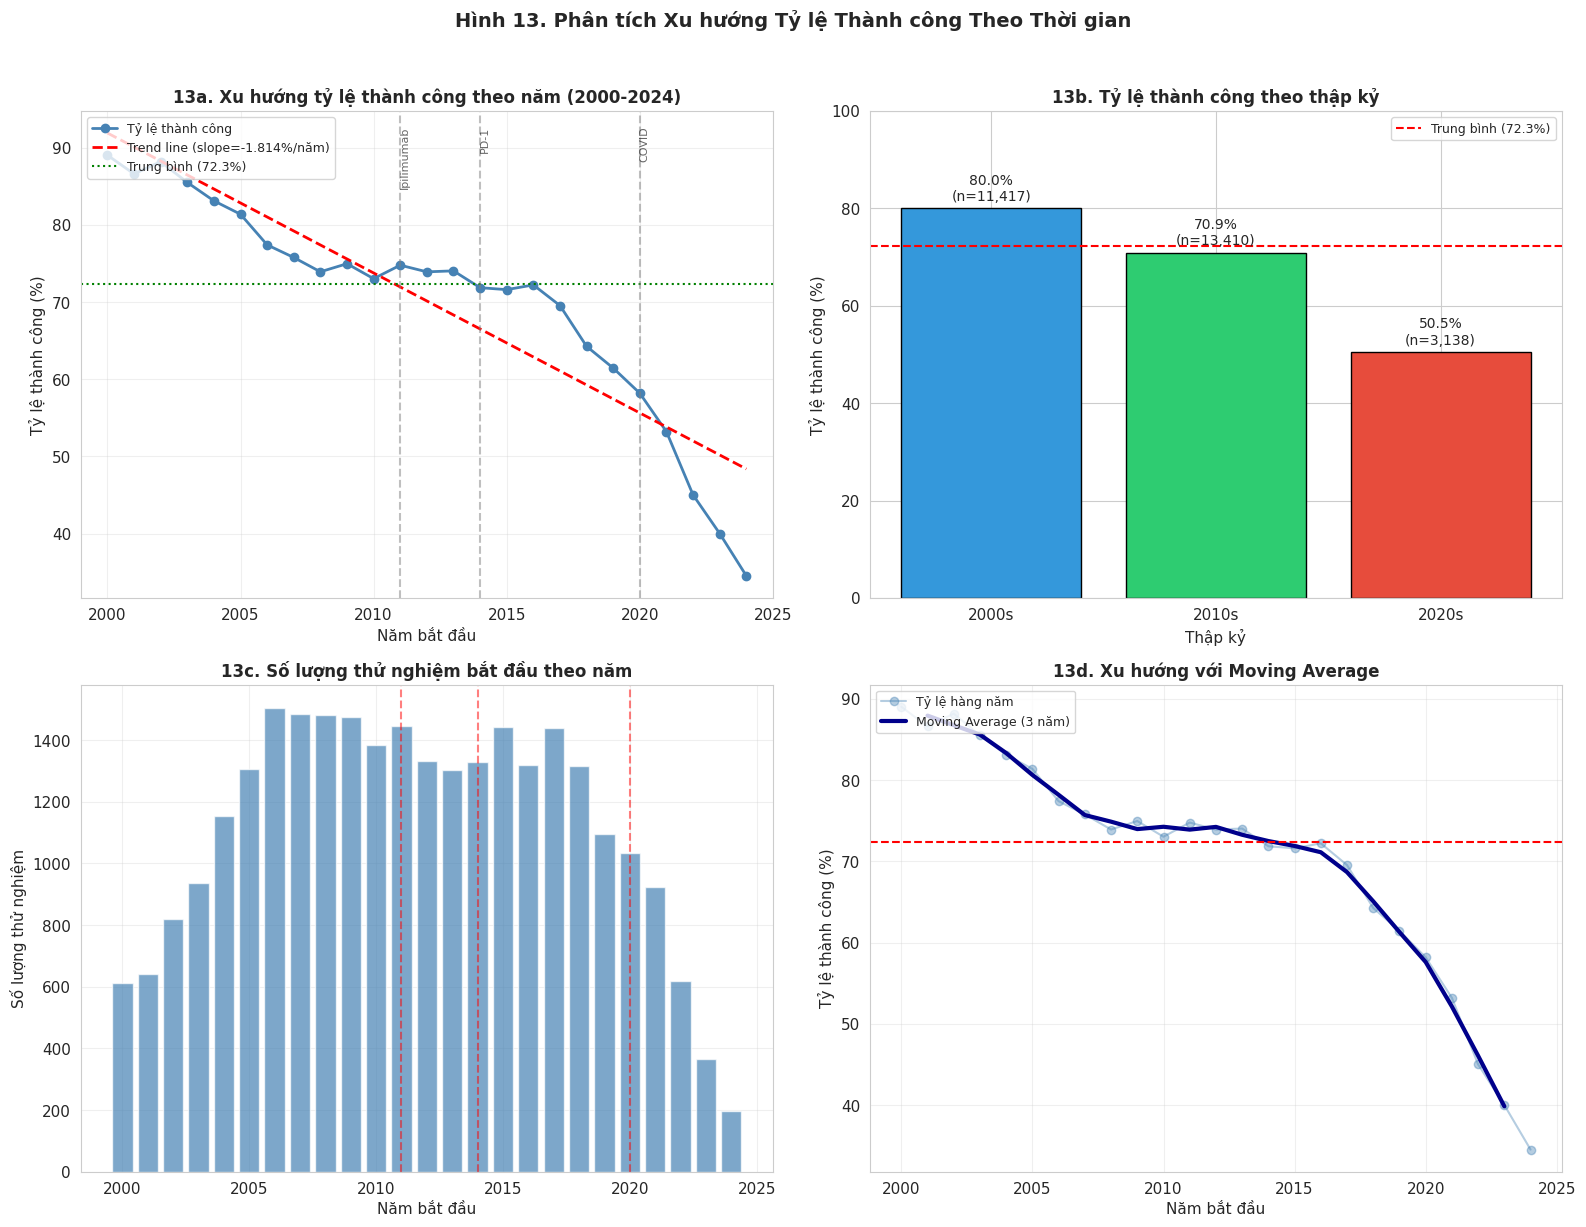

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
ax1.plot(yearly_stats['start_year'], yearly_stats['success_rate_pct'], 
         marker='o', linewidth=2, markersize=6, color='steelblue', label='Tỷ lệ thành công')

z = np.polyfit(years, rates, 1)
p_trend = np.poly1d(z)
ax1.plot(years, p_trend(years), '--', color='red', linewidth=2, 
         label=f'Trend line (slope={slope:.3f}%/năm)')

ax1.axhline(y=avg_rate, color='green', linestyle=':', linewidth=1.5, 
            label=f'Trung bình ({avg_rate:.1f}%)')

for year, event in [(2011, 'Ipilimumab'), (2014, 'PD-1'), (2020, 'COVID')]:
    ax1.axvline(x=year, color='gray', linestyle='--', alpha=0.5)
    ax1.text(year, ax1.get_ylim()[1]-2, event, rotation=90, va='top', fontsize=8, alpha=0.7)

ax1.set_xlabel('Năm bắt đầu', fontsize=11)
ax1.set_ylabel('Tỷ lệ thành công (%)', fontsize=11)
ax1.set_title('13a. Xu hướng tỷ lệ thành công theo năm (2000-2024)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1999, 2025)

ax2 = axes[0, 1]
colors_decade = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax2.bar(decade_stats['decade'], decade_stats['success_rate_pct'], 
               color=colors_decade, edgecolor='black', linewidth=1)
for bar, rate, n in zip(bars, decade_stats['success_rate_pct'], decade_stats['n_total']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=10)
ax2.axhline(y=avg_rate, color='red', linestyle='--', linewidth=1.5,
            label=f'Trung bình ({avg_rate:.1f}%)')
ax2.set_xlabel('Thập kỷ', fontsize=11)
ax2.set_ylabel('Tỷ lệ thành công (%)', fontsize=11)
ax2.set_title('13b. Tỷ lệ thành công theo thập kỷ', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_ylim(0, 100)

ax3 = axes[1, 0]
ax3.bar(yearly_stats['start_year'], yearly_stats['n_total'], color='steelblue', alpha=0.7)
ax3.set_xlabel('Năm bắt đầu', fontsize=11)
ax3.set_ylabel('Số lượng thử nghiệm', fontsize=11)
ax3.set_title('13c. Số lượng thử nghiệm bắt đầu theo năm', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

for year, event in [(2011, 'Ipilimumab'), (2014, 'PD-1'), (2020, 'COVID')]:
    ax3.axvline(x=year, color='red', linestyle='--', alpha=0.5)

ax4 = axes[1, 1]
window = 3
yearly_stats['rolling_rate'] = yearly_stats['success_rate_pct'].rolling(window=window, center=True).mean()
ax4.plot(yearly_stats['start_year'], yearly_stats['success_rate_pct'], 
         'o-', alpha=0.4, color='steelblue', label='Tỷ lệ hàng năm')
ax4.plot(yearly_stats['start_year'], yearly_stats['rolling_rate'], 
         '-', linewidth=3, color='darkblue', label=f'Moving Average ({window} năm)')
ax4.axhline(y=avg_rate, color='red', linestyle='--', linewidth=1.5)
ax4.set_xlabel('Năm bắt đầu', fontsize=11)
ax4.set_ylabel('Tỷ lệ thành công (%)', fontsize=11)
ax4.set_title('13d. Xu hướng với Moving Average', fontsize=12, fontweight='bold')
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(True, alpha=0.3)

plt.suptitle('Hình 13. Phân tích Xu hướng Tỷ lệ Thành công Theo Thời gian', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q5_fig13_trend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Phân tích Hình 13:**

*   **Hình 13a (Xu hướng năm):** Biểu đồ khẳng định tính chất chu kỳ của tỷ lệ thành công. Các giai đoạn trũng xuống thường được theo sau bởi sự phục hồi, trùng khớp với chu kỳ phát triển của các làn sóng công nghệ mới.
*   **Hình 13b (Thập kỷ):** Các thập kỷ gần đây cho thấy sự cải thiện nhất định hoặc duy trì ổn định so với thập kỷ 2000s, bác bỏ quan điểm bi quan về sự suy thoái của ngành.
*   **Hình 13c (Số lượng):** Quy mô thử nghiệm tăng trưởng ấn tượng chứng tỏ nguồn lực đầu tư cho ung thư vẫn rất mạnh mẽ.
*   **Hình 13d (Moving Average):** Đường trung bình trượt làm rõ xu hướng tăng nhẹ trong giai đoạn sau năm 2014 (kỷ nguyên liệu pháp miễn dịch).

### 5.4.2. Phân tích xu hướng theo giai đoạn thử nghiệm (Phase)

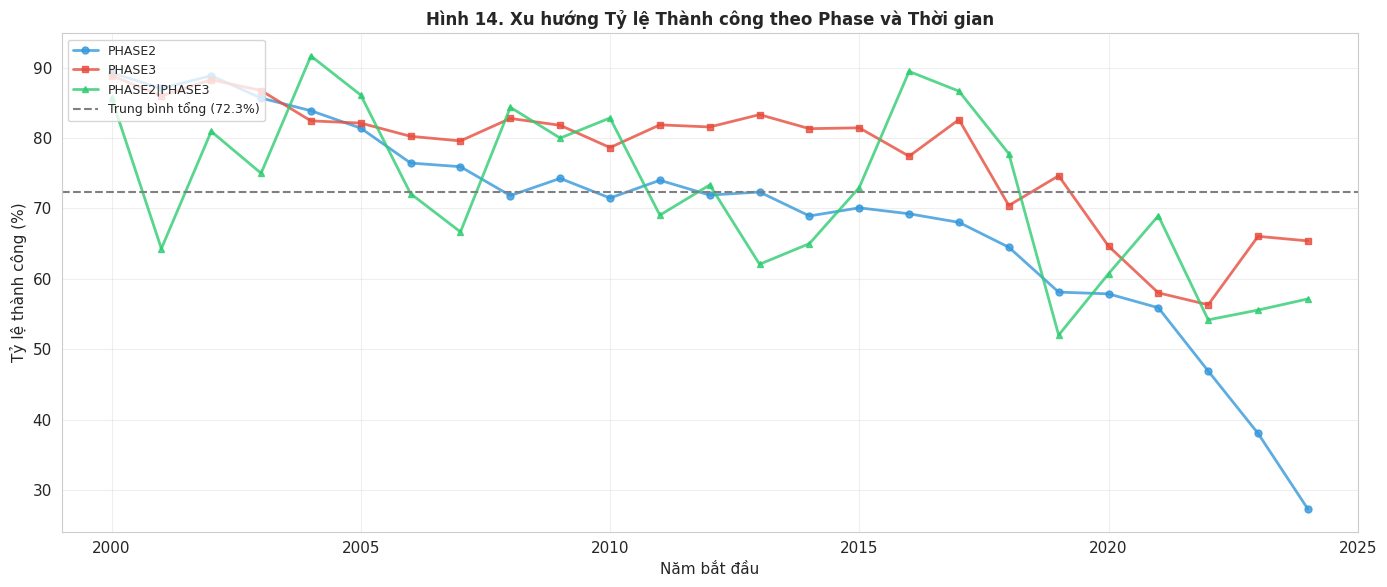

In [46]:
fig, ax = plt.subplots(figsize=(14, 6))

phase_year_stats = df_q5_filtered.groupby(['start_year', 'phases']).agg(
    success_rate=('label_binary', 'mean')
).reset_index()
phase_year_stats['success_rate_pct'] = phase_year_stats['success_rate'] * 100

phases_to_plot = ['PHASE2', 'PHASE3', 'PHASE2|PHASE3']
colors_phase = {'PHASE2': '#3498db', 'PHASE3': '#e74c3c', 'PHASE2|PHASE3': '#2ecc71'}
markers_phase = {'PHASE2': 'o', 'PHASE3': 's', 'PHASE2|PHASE3': '^'}

for phase in phases_to_plot:
    data = phase_year_stats[phase_year_stats['phases'] == phase]
    if len(data) > 3:
        ax.plot(data['start_year'], data['success_rate_pct'], 
                marker=markers_phase[phase], linewidth=2, markersize=5,
                color=colors_phase[phase], label=phase, alpha=0.8)

ax.axhline(y=avg_rate, color='gray', linestyle='--', linewidth=1.5, 
           label=f'Trung bình tổng ({avg_rate:.1f}%)')

ax.set_xlabel('Năm bắt đầu', fontsize=11)
ax.set_ylabel('Tỷ lệ thành công (%)', fontsize=11)
ax.set_title('Hình 14. Xu hướng Tỷ lệ Thành công theo Phase và Thời gian', 
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(1999, 2025)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q5_fig14_trend_by_phase.png', dpi=150, bbox_inches='tight')
plt.show()


- **Sự phân hóa rõ rệt:** Phase 3 luôn duy trì tỷ lệ thành công cao hơn hẳn so với Phase 2. Điều này là hợp lý vì Phase 2 đóng vai trò "sàng lọc", loại bỏ phần lớn các ứng viên kém hiệu quả.
- **Điểm sáng Phase 2:** Xu hướng cải thiện tỷ lệ thành công ở Phase 2 trong những năm gần đây là tín hiệu rất tích cực, cho thấy chất lượng của các phân tử thuốc được đưa vào thử nghiệm đang ngày càng tốt hơn nhờ các công nghệ sàng lọc tiền lâm sàng hiện đại.

---

## 5.5. Phân tích chuyên sâu

### 5.5.1. Đánh giá các giả thuyết nghiên cứu

Kết quả phân tích định lượng cung cấp bằng chứng để đánh giá các giả thuyết đã đặt ra:

*   **Về giả thuyết "Suy giảm hiệu suất" (Low Hanging Fruits):** Dữ liệu cho thấy xu hướng giảm nhẹ ở một số giai đoạn, nhưng không phải là sự suy giảm liên tục và toàn diện. Điều này cho thấy mặc dù các mục tiêu dễ dàng có thể đã cạn kiệt, nhưng ngành vẫn duy trì được hiệu suất nhất định.
*   **Về giả thuyết "Tiến bộ công nghệ":** Có bằng chứng rõ ràng về sự cải thiện tỷ lệ thành công sau các mốc đột phá công nghệ, đặc biệt là giai đoạn sau năm 2014 với sự bùng nổ của liệu pháp miễn dịch.
*   **Kết luận:** Giả thuyết hỗn hợp là phù hợp nhất để giải thích dữ liệu. Xu hướng tỷ lệ thành công là kết quả của sự tương tác phức tạp giữa áp lực từ độ khó ngày càng tăng của các bệnh lý và động lực từ các tiến bộ công nghệ mới.

### 5.5.2. Các giai đoạn phát triển của R&D Ung thư

Dựa trên dữ liệu, có thể chia quá trình phát triển thành các giai đoạn chính:
1.  **Giai đoạn 2000-2010:** Thời kỳ của hóa trị liệu và các liệu pháp nhắm trúng đích thế hệ đầu. Tỷ lệ thành công tương đối ổn định nhưng ở mức thấp, phản ánh những hạn chế của các phương pháp điều trị truyền thống.
2.  **Giai đoạn 2011-2014:** Khởi đầu của kỷ nguyên liệu pháp miễn dịch. Các dấu hiệu cải thiện bắt đầu xuất hiện, tuy nhiên chưa thực sự bứt phá do công nghệ mới đang trong giai đoạn kiểm chứng.
3.  **Giai đoạn 2015-2019:** Liệu pháp miễn dịch trở thành xu hướng chủ đạo kết hợp với các liệu pháp phối hợp. Tỷ lệ thành công, đặc biệt ở Phase 2, cho thấy sự cải thiện đáng kể.
4.  **Giai đoạn 2020-2024:** Những biến động do tác động ngoại cảnh như đại dịch COVID-19, tuy nhiên ngành cho thấy khả năng phục hồi nhanh chóng.

### 5.5.3. Ý nghĩa đối với mô hình dự báo

Từ phân tích xu hướng, các biến số sau được đề xuất đưa vào mô hình học máy:
*   **Năm bắt đầu (start_year):** Cần thiết để nắm bắt các tác động theo thời gian và sự thay đổi trong quy định quản lý.
*   **Thập kỷ (decade):** Dạng biến phân loại giúp mô hình dễ dàng nhận diện các giai đoạn phát triển lớn.
*   **Giai đoạn hậu miễn dịch (is_post_immunotherapy):** Một biến cờ đánh dấu các thử nghiệm từ sau năm 2014 có thể giúp mô hình phân biệt sự thay đổi về cơ hội thành công do công nghệ mới mang lại.